<a href="https://colab.research.google.com/github/AntonDozhdikov/politpredict/blob/main/BRICS_PolSys_MARL_v7_0_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BRICS–PolSys MARL v7.0

**Воспроизводимый контрфактический эксперимент для приложения к политологической статье**

Версия 7.0 сохраняет онтологию из 47 показателей состояния, 14 действий, индексы SDI/ECI/MPI/DPI и механизмы MAPPO → MWA/NES → MetaBRICS. Экспериментальная логика пересмотрена после аудита v6.0: устранены фиксированная надбавка к координационной стоимости MetaBRICS, насыщенный критерий восстановления, размерностная ошибка гетерогенности и псевдорепликация в механистических тестах.

Ноутбук рассчитан на последовательный запуск в Google Colab с NVIDIA T4/L4. Производственный режим использует 10 сидов, общий вычислительный регулятор и жёсткий предел 230 минут с резервом на экспорт. Код является модельным контрфактическим анализом, а не прогнозом, рейтингом стран или рекомендацией реальным правительствам.


## Научный статус, единица вывода и запрет на сверхинтерпретацию

Политический агент здесь — формальный контур принятия решений. Его действие означает изменение модельной интенсивности инструмента, а не наблюдавшийся государственный акт. Совпадение названий стран с реальными государствами задаёт начальные условия и структуру панели, но не превращает симуляцию в рейтинг режимов.

Основная статистическая единица — **`seed × scenario`**. Страны и временные шаги вложены в эту единицу и не увеличивают эффективный размер выборки. Все primary-сравнения парные: архитектуры получают одинаковые сценарии, начальные состояния и потоки случайных чисел.

Результативность разделена на:

$$R_{gross}=0.30Y_D+0.25Y_W+0.15Y_I+0.20C-0.10Q,$$

$$R_{net}=R_{gross}-\lambda_c C_{coord}-\lambda_u U-\lambda_p D_{proxy}.$$

Поэтому операциональный выигрыш и стоимость координации наблюдаются раздельно. Значимость без содержательно заметного эффекта не трактуется как политически важный результат.


## Карта исполнения

| Контур | Содержание | Целевое окно |
|---|---|---:|
| Preflight | схема, train-only преобразования, GPU-микробенчмарк | 7–9 мин |
| Exp.0 | ансамбль из трёх DNLSSM | 25–28 мин |
| Exp.1 | 10 независимых акторов MAPPO + централизованный критик | 50–55 мин |
| Exp.2.1 | MWA/NES одной референтной страны | 10–12 мин |
| Exp.2.2 | локальный MWA/NES каждой страны | 40–46 мин |
| Exp.2.3 | MetaBRICS supervisor | 14–17 мин |
| OOD/Future Evaluation | observed holdout + synthetic OOD, общие случайные числа | 14–18 мин |
| Exp.3 + статистика + экспорт | PolSys, 17 гипотез, Excel, фигуры, ZIP | 20–25 мин |

Единый прогресс-бар показывает выполненные и пропущенные ранней остановкой единицы работы. Виджеты не используются: выполненный файл корректно отображается на GitHub.


## 0. Среда Colab

Выберите **Runtime → Change runtime type → T4 GPU или L4 GPU**, затем выполните ячейки сверху вниз. Установочная ячейка добавляет только отсутствующие библиотеки и не заменяет поставляемую Colab версию PyTorch/CUDA.


In [ ]:
# Устанавливаем только отсутствующие пакеты: это снижает риск конфликта с CUDA-стеком Colab.
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "openpyxl": "openpyxl>=3.1",
    "xlsxwriter": "xlsxwriter>=3.2",
    "pyarrow": "pyarrow>=17",
    "statsmodels": "statsmodels>=0.14",
    "seaborn": "seaborn>=0.13",
}

missing = [spec for module, spec in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Среда готова; PyTorch/CUDA не переустанавливались.")


Среда готова; PyTorch/CUDA не переустанавливались.


In [ ]:
# Базовые зависимости и единый визуальный стиль.
from __future__ import annotations

import gc
import hashlib
import json
import math
import os
import random
import shutil
import time
import textwrap
import warnings
import zipfile
from collections import defaultdict
from contextlib import contextmanager
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Callable, Iterable, Mapping, Sequence

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as sps
import statsmodels.formula.api as smf
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.special import expit
from statsmodels.stats.multitest import multipletests
from torch.distributions import Dirichlet, Normal
from torch.func import functional_call, vmap
from torch.utils.data import DataLoader, TensorDataset
from tqdm.std import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CUDA_ENABLED = DEVICE.type == "cuda"
if CUDA_ENABLED:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = False
    torch.set_float32_matmul_precision("high")

print(f"Устройство: {DEVICE}")
if CUDA_ENABLED:
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Устройство: cuda
GPU: Tesla T4


In [ ]:
def set_global_seed(seed: int) -> None:
    """Фиксирует генераторы; детерминированные операции включаются в безопасном warn-only режиме."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if CUDA_ENABLED:
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)


def stable_int_seed(*parts: Any) -> int:
    digest = hashlib.sha256("|".join(map(str, parts)).encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def cleanup_memory() -> None:
    gc.collect()
    if CUDA_ENABLED:
        torch.cuda.synchronize()
        torch.cuda.empty_cache()


set_global_seed(17)


## 1. Конфигурация и вычислительный бюджет

Профиль `STANDARD` задаёт верхний научный бюджет. После короткого микробенчмарка ноутбук при необходимости выбирает `SAFE_T4`: число сидов, горизонт оценки, observed/OOD-разбиение и реестр 17 гипотез не сокращаются; уменьшаются только максимальные числа MAPPO-эпизодов и метаитераций. Ранняя остановка сохраняет лучшую валидационную точку.


In [ ]:
@dataclass(frozen=True)
class ComputeProfile:
    name: str
    wm_min_epochs: int
    wm_max_epochs: int
    mappo_min_episodes: int
    mappo_max_episodes: int
    nes_min_rounds: int
    nes_max_rounds: int
    meta_min_rounds: int
    meta_max_rounds: int


PROFILES = {
    # Числа задают диапазон, а не обещанную длительность: регулятор учитывает фактическую скорость Colab.
    "STANDARD": ComputeProfile("STANDARD", 70, 180, 350, 600, 45, 90, 60, 100),
    "SAFE_T4": ComputeProfile("SAFE_T4", 60, 150, 300, 500, 40, 75, 50, 85),
}


@dataclass
class ExperimentConfig:
    project: str = "BRICS-PolSys-MARL"
    version: str = "7.0"
    seeds: tuple[int, ...] = (17, 42, 101, 202, 303, 404, 505, 606, 707, 808)
    countries: tuple[str, ...] = ("RUS", "CHN", "IND", "BRA", "ZAF", "IRN", "ARE", "ETH", "EGY", "IDN")
    reference_country: str = "RUS"

    train_year_end: int = 2020
    holdout_year_start: int = 2021
    holdout_year_end: int = 2025
    ood_year_start: int = 2026
    ood_year_end: int = 2036
    horizon: int = 36
    n_eval_observed: int = 3
    n_eval_ood: int = 5

    n_state: int = 47
    n_actions: int = 14
    n_agents: int = 10
    channel_weights: tuple[float, float, float] = (0.50, 0.25, 0.25)

    wm_members: int = 5
    wm_hidden: int = 160
    wm_layers: int = 3
    wm_batch: int = 256
    wm_lr: float = 8e-4
    wm_residual_scale: float = 0.05
    wm_patience: int = 24
    wm_required_ratio: float = 0.995

    actor_hidden: tuple[int, int, int] = (256, 128, 64)
    gamma: float = 0.975
    gae_lambda: float = 0.95
    mappo_lr: float = 2.5e-4
    clip_eps: float = 0.20
    update_epochs: int = 8
    minibatches: int = 4
    entropy_coef: float = 0.012
    value_coef: float = 0.50
    max_grad_norm: float = 0.50
    update_every_episodes: int = 4
    rl_patience: int = 40
    rl_rel_delta: float = 0.0005

    mwa_hidden: int = 64
    mwa_max_logit_shift: float = 1.25
    nes_population: int = 12
    nes_sigma: float = 0.075
    nes_lr: float = 0.035
    nes_patience: int = 16
    nes_scenarios_per_round: int = 2
    meta_hidden: int = 160
    meta_lr: float = 2e-4
    meta_patience: int = 20
    meta_max_logit_shift: float = 0.75
    dirichlet_concentration: float = 24.0
    supervisor_kl_coef: float = 0.01

    # Штрафы не содержат архитектурной константы: цена возникает только при фактической перенастройке.
    coord_penalty: float = 0.006
    uncertainty_penalty: float = 0.010
    proxy_drift_penalty: float = 0.010
    standardized_sesoi: float = 0.10
    heterogeneity_threshold_sd: float = 0.10

    recovery_baseline_window: int = 3
    recovery_sustain_periods: int = 3
    recovery_tolerance_floor: float = 0.015
    recovery_volatility_multiplier: float = 1.00

    target_runtime_min: int = 170
    target_runtime_max: int = 215
    hard_runtime_min: int = 230
    finalization_reserve_min: int = 18
    stage_budget_min: dict[str, float] = field(default_factory=lambda: {
        "Preflight": 8, "Exp.0": 25, "Exp.1": 82, "Exp.2.1": 10,
        "Exp.2.2": 55, "Exp.2.3": 18, "Evaluation": 15,
        "Exp.3": 5, "Statistics": 7, "Figures": 4, "Export": 6,
    })

    input_mode: str = "upload"             # upload | github
    panel_filename: str = "brics_polsys_panel_v2_full.xlsx"
    crisis_filename: str = "crises_and_scenarios_generated.xlsx"
    panel_url: str = ""
    crisis_url: str = ""
    output_root: str = "/content/BRICS_PolSys_MARL_v7_0_results"
    work_root: str = "/content/BRICS_PolSys_MARL_v7_0_work"
    resume: bool = True
    keep_checkpoints: bool = False
    export_full_state_trajectory: bool = False


CFG = ExperimentConfig()
PROFILE = PROFILES["STANDARD"]
print(json.dumps({**asdict(CFG), "profile": asdict(PROFILE)}, ensure_ascii=False, indent=2))


{
  "project": "BRICS-PolSys-MARL",
  "version": "7.0",
  "seeds": [
    17,
    42,
    101,
    202,
    303,
    404,
    505,
    606,
    707,
    808
  ],
  "countries": [
    "RUS",
    "CHN",
    "IND",
    "BRA",
    "ZAF",
    "IRN",
    "ARE",
    "ETH",
    "EGY",
    "IDN"
  ],
  "reference_country": "RUS",
  "train_year_end": 2020,
  "holdout_year_start": 2021,
  "holdout_year_end": 2025,
  "ood_year_start": 2026,
  "ood_year_end": 2036,
  "horizon": 36,
  "n_eval_observed": 3,
  "n_eval_ood": 5,
  "n_state": 47,
  "n_actions": 14,
  "n_agents": 10,
  "channel_weights": [
    0.5,
    0.25,
    0.25
  ],
  "wm_members": 5,
  "wm_hidden": 160,
  "wm_layers": 3,
  "wm_batch": 256,
  "wm_lr": 0.0008,
  "wm_residual_scale": 0.05,
  "wm_patience": 24,
  "wm_required_ratio": 0.995,
  "actor_hidden": [
    256,
    128,
    64
  ],
  "gamma": 0.975,
  "gae_lambda": 0.95,
  "mappo_lr": 0.00025,
  "clip_eps": 0.2,
  "update_epochs": 8,
  "minibatches": 4,
  "entropy_coef": 0.012,


## 2. Онтология состояния и действий

Состояние страны $i$ в момент $t$ — вектор

$$s_{i,t}=[D_{12},W_{8},M_{6},Q_{6},X_{4},K_{4},Z_{7}]\in[0,1]^{47},$$

где $D$ — «дела», $W$ — «слова», $M$ — публичные «образы», $Q$ — структурный фон, $X$ — кризисные признаки, $K=(SDI,ECI,MPI,DPI)$ — четыре системных индекса, $Z=(L,S,P,G,I,O,T)$ — стратегико-коммуникационные переменные. Порядок признаков является частью спецификации и защищён SHA-256.

Действие $a_{i,t}\in[-1,1]^{14}$ содержит четыре инструмента «дел», четыре инструмента «слов», три инструмента «образов» и три структурных инструмента. Адаптивные веса применяются только к первым трём каналам; структурный блок остаётся отдельным.


In [ ]:
STATE_BLOCKS = {
    "deeds": [
        "gdp_growth_final", "gdp_per_capita", "trade_openness_final", "fdi_inflow_pct_gdp",
        "gross_capital_form_wdi", "exports_gdp_wdi", "imports_gdp_wdi", "manufacturing_gdp_wdi",
        "military_spending_gdp_final", "hitech_exports_wdi", "rd_gdp_wdi", "patents_residents_wdi",
    ],
    "words": [
        "electoral_democracy_vdem", "liberal_democracy_vdem", "political_corruption_vdem",
        "voice_accountability", "political_stability", "regulatory_quality", "rule_of_law",
        "control_of_corruption",
    ],
    "images": [
        "corruption_perception", "government_effectiveness", "internet_users_final",
        "mobile_subs_wdi", "broadband_wdi", "secure_servers_pm_wdi",
    ],
    "structural": [
        "population_growth_rate", "urbanization", "dependency_ratio", "net_migration_wb",
        "gini_index_final", "unemployment_final",
    ],
    "shocks": ["active_crisis_flag", "sanction_severity", "anomaly_score", "elite_pressure_index"],
    "core": ["SDI", "ECI", "MPI", "DPI"],
    "strategic": [
        "L_internal_legitimacy_proxy", "S_narrative_sync_proxy", "P_external_pressure_constructed",
        "G_ai_tech_gap_proxy", "I_institutional_maturity_constructed",
        "O_regional_operationalization_proxy", "T_audience_trust_proxy",
    ],
}
STATE_NAMES = tuple(name for block in STATE_BLOCKS.values() for name in block)
STATE_INDEX = {name: i for i, name in enumerate(STATE_NAMES)}
# Каноническое представление онтологии: одно имя показателя на строку.
# Именно по нему рассчитана опубликованная контрольная сумма.
STATE_ORDER_SHA256 = hashlib.sha256("\n".join(STATE_NAMES).encode("utf-8")).hexdigest()
EXPECTED_STATE_SHA256 = "407edb27a53044727d10e5983637ad4a3ac0739fccc16e7ca07c82bc5ba2243c"

STATE_DEFINITIONS = {
    "gdp_growth_final": "темп роста ВВП", "gdp_per_capita": "ВВП на душу населения",
    "trade_openness_final": "внешнеторговая открытость", "fdi_inflow_pct_gdp": "приток ПИИ, % ВВП",
    "gross_capital_form_wdi": "валовое накопление капитала", "exports_gdp_wdi": "экспорт, % ВВП",
    "imports_gdp_wdi": "импорт, % ВВП", "manufacturing_gdp_wdi": "обрабатывающая промышленность, % ВВП",
    "military_spending_gdp_final": "военные расходы, % ВВП", "hitech_exports_wdi": "высокотехнологичный экспорт",
    "rd_gdp_wdi": "НИОКР, % ВВП", "patents_residents_wdi": "патентные заявки резидентов",
    "electoral_democracy_vdem": "электорально-демократический компонент V-Dem",
    "liberal_democracy_vdem": "либерально-демократический компонент V-Dem",
    "political_corruption_vdem": "политическая коррупция V-Dem; больше означает хуже",
    "voice_accountability": "участие и подотчётность", "political_stability": "политическая стабильность",
    "regulatory_quality": "качество регулирования", "rule_of_law": "верховенство права",
    "control_of_corruption": "контроль коррупции", "corruption_perception": "восприятие чистоты публичного управления",
    "government_effectiveness": "эффективность правительства", "internet_users_final": "пользователи интернета",
    "mobile_subs_wdi": "мобильные подключения", "broadband_wdi": "фиксированный широкополосный доступ",
    "secure_servers_pm_wdi": "защищённые серверы на миллион человек", "population_growth_rate": "рост населения",
    "urbanization": "доля городского населения", "dependency_ratio": "демографическая нагрузка",
    "net_migration_wb": "чистая миграция", "gini_index_final": "неравенство Джини; больше означает хуже",
    "unemployment_final": "безработица; больше означает хуже", "active_crisis_flag": "активность кризиса",
    "sanction_severity": "интенсивность санкционного давления", "anomaly_score": "аномальность траектории",
    "elite_pressure_index": "давление на элитную коалицию", "SDI": "Social Development Index",
    "ECI": "Elite Concentration Index", "MPI": "Material Power Index",
    "DPI": "Destructive Potential Index = rescale(ECI) × rescale(MPI)",
    "L_internal_legitimacy_proxy": "L: внутренняя легитимность",
    "S_narrative_sync_proxy": "S: согласованность нарратива",
    "P_external_pressure_constructed": "P: внешнее давление",
    "G_ai_tech_gap_proxy": "G: технологический разрыв",
    "I_institutional_maturity_constructed": "I: институциональная зрелость",
    "O_regional_operationalization_proxy": "O: операционализация обязательств",
    "T_audience_trust_proxy": "T: доверие аудитории",
}

ACTION_GROUPS = {
    "deeds": (0, 1, 2, 3), "words": (4, 5, 6, 7),
    "images": (8, 9, 10), "structural": (11, 12, 13),
}
ACTION_NAMES = (
    "trade_intensity_brics", "ndb_investment", "bilateral_preferences", "fdi_openness",
    "unga_alignment_brics", "initiate_declaration", "support_member", "multilateral_forum",
    "media_coverage_intensity", "narrative_tone", "counter_disinfo_ops",
    "migration_policy", "education_exchange", "elite_stabilization",
)
ACTION_DEFINITIONS = {
    "trade_intensity_brics": "интенсивность взаимной торговли", "ndb_investment": "инвестиции НБР",
    "bilateral_preferences": "двусторонние преференции", "fdi_openness": "открытость для ПИИ",
    "unga_alignment_brics": "согласование позиций в ГА ООН", "initiate_declaration": "инициирование декларации",
    "support_member": "публичная поддержка участника", "multilateral_forum": "многосторонняя координация",
    "media_coverage_intensity": "интенсивность медиаприсутствия", "narrative_tone": "тон нарратива",
    "counter_disinfo_ops": "информационная устойчивость", "migration_policy": "миграционная политика",
    "education_exchange": "образовательные и экспертные обмены", "elite_stabilization": "элитное согласование",
}

assert len(STATE_NAMES) == 47 and STATE_ORDER_SHA256 == EXPECTED_STATE_SHA256
assert len(ACTION_NAMES) == 14
print(f"Онтология: {len(STATE_NAMES)} состояний, {len(ACTION_NAMES)} действий; SHA-256 подтверждён.")


Онтология: 47 состояний, 14 действий; SHA-256 подтверждён.


## 3. Индексы, ориентация показателей и функция вознаграждения

Индексы строятся только по обучающему периоду 1990–2020. Для положительных показателей используется нормированное значение $x$; для отрицательных — $1-x$; для нейтральных, где экстремум нежелателен в обе стороны,

$$q(x)=\operatorname{clip}\left(1-\frac{|x-\operatorname{median}_{train}|}{3\,MAD_{train}+\varepsilon},0,1\right).$$

Канальные результаты $Y_D,Y_W,Y_M$ являются средними ориентированных признаков. Базовая и чистая награды:

$$R_0=.30Y_D+.25Y_W+.15Y_M+.20Coh-.10Risk,$$
$$R_{net}=R_0-.02C_{coord}-.02U-.03ProxyDrift,$$

$$ProxyDrift=\left[\Delta\frac{S+T}{2}-\Delta\frac{O+Y_D}{2}\right]_+.$$

`Coh` — согласованность стран, `Risk` — системный риск, $C_{coord}$ — стоимость координации, $U$ — неопределённость ансамбля DNLSSM. Эти компоненты экспортируются отдельно, поэтому итоговая награда остаётся интерпретируемой.


In [ ]:
INDEX_SPECS = {
    "SDI": {
        "positive": ("edu_exp_pct_gdp", "health_exp_pct_gdp", "life_expectancy", "electricity_access", "water_basic_access", "social_contrib_pct_gdp"),
        "negative": ("poverty_headcount",),
        "minimum_coverage": 5,
    },
    "ECI": {
        "positive": ("gini_wb", "income_top20", "tax_revenue_pct_gdp", "npl_pct", "private_credit_pct_gdp"),
        "negative": ("income_bottom20",),
        "minimum_coverage": 4,
    },
    "MPI": {
        "positive": ("military_exp_pct_gdp", "hitech_exports_pct", "rd_exp_pct_gdp", "secure_servers_per1m", "broadband_per100", "patents_residents", "internet_users_pct"),
        "negative": (),
        "minimum_coverage": 5,
    },
}

NEGATIVE_STATE_FEATURES = {
    "political_corruption_vdem", "gini_index_final", "unemployment_final",
    "dependency_ratio", "sanction_severity", "anomaly_score", "elite_pressure_index",
    "ECI", "DPI", "P_external_pressure_constructed", "G_ai_tech_gap_proxy",
}
NEUTRAL_STATE_FEATURES = {"military_spending_gdp_final", "net_migration_wb", "population_growth_rate"}


class TrainOnlyIndexBuilder:
    """Вычисляет SDI/ECI/MPI/DPI без использования holdout при оценке шкал."""
    def __init__(self, specs: Mapping[str, Mapping[str, Any]]):
        self.specs = specs
        self.center_: dict[str, float] = {}
        self.scale_: dict[str, float] = {}
        self.index_bounds_: dict[str, tuple[float, float]] = {}
        self.used_: dict[str, list[str]] = {}

    def fit(self, train: pd.DataFrame) -> "TrainOnlyIndexBuilder":
        for index_name, spec in self.specs.items():
            requested = [*spec["positive"], *spec["negative"]]
            used = [c for c in requested if c in train.columns and train[c].notna().sum() >= 5]
            if len(used) < int(spec["minimum_coverage"]):
                raise ValueError(f"{index_name}: доступно {len(used)} индикаторов из требуемых {spec['minimum_coverage']}: {used}")
            self.used_[index_name] = used
            for col in used:
                values = pd.to_numeric(train[col], errors="coerce")
                med = float(values.median())
                mad = float((values - med).abs().median())
                self.center_[col] = med
                self.scale_[col] = max(1.4826 * mad, float(values.std(ddof=0)), 1e-8)

        train_indices = self._raw_indices(train)
        for name in ("SDI", "ECI", "MPI"):
            lo, hi = train_indices[name].quantile([0.01, 0.99]).tolist()
            self.index_bounds_[name] = (float(lo), float(max(hi, lo + 1e-8)))
        return self

    def _raw_indices(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = pd.DataFrame(index=frame.index)
        for name, spec in self.specs.items():
            parts = []
            for col in self.used_[name]:
                z = (pd.to_numeric(frame[col], errors="coerce").fillna(self.center_[col]) - self.center_[col]) / self.scale_[col]
                if col in spec["negative"]:
                    z = -z
                parts.append(z.rename(col))
            out[name] = pd.concat(parts, axis=1).mean(axis=1)
        return out

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        raw = self._raw_indices(frame)
        scaled = {}
        for name in ("SDI", "ECI", "MPI"):
            lo, hi = self.index_bounds_[name]
            scaled[name] = ((raw[name] - lo) / (hi - lo)).clip(0, 1)
            out[name] = scaled[name]
        out["DPI"] = (scaled["ECI"] * scaled["MPI"]).clip(0, 1)
        return out


class TrainOnlyMinMax:
    """Winsorized min–max: границы 1–99% оцениваются исключительно на train."""
    def fit(self, train: pd.DataFrame, columns: Sequence[str]) -> "TrainOnlyMinMax":
        self.columns = tuple(columns)
        self.lo = train.loc[:, self.columns].quantile(0.01).astype(float)
        self.hi = train.loc[:, self.columns].quantile(0.99).astype(float)
        self.hi = self.hi.where((self.hi - self.lo).abs() > 1e-8, self.lo + 1.0)
        self.fill = train.loc[:, self.columns].median().astype(float)
        return self

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        values = out.loc[:, self.columns].apply(pd.to_numeric, errors="coerce").fillna(self.fill)
        out.loc[:, self.columns] = ((values - self.lo) / (self.hi - self.lo)).clip(0, 1)
        return out


class OrientedChannelScorer:
    def fit(self, train_scaled: pd.DataFrame) -> "OrientedChannelScorer":
        self.median = train_scaled.loc[:, STATE_NAMES].median().astype(float)
        self.mad = (train_scaled.loc[:, STATE_NAMES] - self.median).abs().median().clip(lower=1e-6)
        direction = []
        for name in STATE_NAMES:
            direction.append(-1 if name in NEGATIVE_STATE_FEATURES else 0 if name in NEUTRAL_STATE_FEATURES else 1)
        self.direction = torch.tensor(direction, dtype=torch.int8, device=DEVICE)
        self.median_t = torch.tensor(self.median.values, dtype=torch.float32, device=DEVICE)
        self.mad_t = torch.tensor(self.mad.values, dtype=torch.float32, device=DEVICE)
        return self

    def oriented(self, state: torch.Tensor) -> torch.Tensor:
        positive = state
        negative = 1.0 - state
        neutral = (1.0 - (state - self.median_t).abs() / (3.0 * self.mad_t + 1e-8)).clamp(0, 1)
        return torch.where(self.direction > 0, positive, torch.where(self.direction < 0, negative, neutral))

    def channels(self, state: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        q = self.oriented(state)
        return q[..., 0:12].mean(-1), q[..., 12:20].mean(-1), q[..., 20:26].mean(-1)


## 4. Реестр гипотез

Пять **primary**-гипотез проверяют архитектурные выводы с поправкой Holm. Двенадцать **exploratory**-гипотез описывают политические механизмы и корректируются FDR–Benjamini–Hochberg. Единица вывода — пара `seed × scenario`; точки отдельных сидов, IQM, медиана, среднее и leave-one-seed-out чувствительность сохраняются в Excel.


In [ ]:
HYPOTHESES = [
    {"id":"P1","family":"primary","statement":"Локальная распределённая адаптация повышает валовую результативность относительно фиксированной архитектуры на наблюдавшемся holdout.","estimand":"standardized IQM(R_gross[Exp.2.2] − R_gross[Exp.1])","direction":"greater","method":"paired hierarchical bootstrap + sign flip"},
    {"id":"P2","family":"primary","statement":"MetaBRICS не уступает локальной адаптации по чистой результативности в synthetic OOD более чем на 0.10 стандартного отклонения базовой архитектуры.","estimand":"standardized IQM(R_net[Exp.2.3] − R_net[Exp.2.2])","direction":"noninferior","margin":0.10,"method":"paired non-inferiority sign flip"},
    {"id":"P3","family":"primary","statement":"Локальная адаптация уменьшает интегральную функциональную потерю после кризиса относительно Exp.1.","estimand":"standardized IQM(AULC[Exp.2.2] − AULC[Exp.1])","direction":"less","method":"paired hierarchical bootstrap"},
    {"id":"P4","family":"primary","statement":"MetaBRICS уменьшает proxy drift относительно Exp.2.2, не допуская содержательно значимой потери валовой результативности.","estimand":"drift reduction AND gross-reward non-inferiority","direction":"joint","margin":0.10,"method":"intersection–union paired tests"},
    {"id":"P5","family":"primary","statement":"Стандартизированный эффект Exp.2.2 неоднороден по странам или типам кризиса.","estimand":"max(τ_country, τ_crisis), standard deviation","direction":"greater_threshold","threshold":0.10,"method":"hierarchical bootstrap of group-effect SD"},
    {"id":"E1","family":"exploratory","statement":"Высокая докризисная ECI усиливает функциональные потери при сопоставимом шоке.","estimand":"β(ECI × shock)","direction":"less","method":"clustered country-FE model"},
    {"id":"E2","family":"exploratory","statement":"Высокая докризисная DPI связана с более долгим устойчивым восстановлением и большей AULC.","estimand":"−β_DPI(recovery hazard)","direction":"greater","method":"cluster-robust stratified PH model"},
    {"id":"E3","family":"exploratory","statement":"При высокой ECI Exp.2.2 сильнее Exp.1 сдерживает послекризисный рост DPI.","estimand":"β(Exp.2.2 × ECI)","direction":"less","method":"clustered interaction model"},
    {"id":"E4","family":"exploratory","statement":"Только при подтверждённой вогнутости поверхности максимум веса канала «дела» находится в диапазоне 0.40–0.60.","estimand":"argmax_w R(w), conditional on β_w²<0","direction":"inside_interval","interval":[0.40,0.60],"method":"cluster bootstrap response surface"},
    {"id":"E5","family":"exploratory","statement":"Положительный разрыв «слова минус дела» снижает T с лагом 1 и L с лагом 2.","estimand":"β_gap,T and β_gap,L","direction":"less","method":"clustered distributed-lag models"},
    {"id":"E6","family":"exploratory","statement":"Высокая внутренняя легитимность смягчает влияние экзогенного шока на функциональный результат.","estimand":"β(shock × L)","direction":"greater","method":"clustered moderation model"},
    {"id":"E7","family":"exploratory","statement":"Технологический разрыв G ослабляет положительное влияние канала образов на доверие T.","estimand":"β(images × G)","direction":"less","method":"clustered interaction model"},
    {"id":"E8","family":"exploratory","statement":"Операционализация O частично опосредует связь между делами и скорректированной AULC.","estimand":"deeds → O → (1−AULC)","direction":"greater","method":"seed×scenario cluster bootstrap mediation"},
    {"id":"E9","family":"exploratory","statement":"Стандартизированный эффект Exp.2.2 отличается между новыми и первоначальными участниками.","estimand":"Δ_new − Δ_core","direction":"two_sided","method":"clustered interaction model"},
    {"id":"E10","family":"exploratory","statement":"Exp.2.3 уменьшает внутрикластерную волатильность весов относительно Exp.2.2 без коллапса к каноническому вектору.","estimand":"paired log variance ratio plus adaptation-floor check","direction":"joint","method":"seed×scenario paired bootstrap"},
    {"id":"E11","family":"exploratory","statement":"Рост S без сопоставимого роста O повышает proxy drift и не улучшает R_gross.","estimand":"β(S−O,drift)>0 and β(S−O,R_gross)≤0","direction":"joint","method":"clustered panel models"},
    {"id":"E12","family":"exploratory","statement":"Exp.2.3 снижает межсидовую вариативность OOD-результата относительно Exp.1.","estimand":"paired scenario-level variance ratio","direction":"less_than_one","method":"scenario bootstrap over seeds"},
]
HYPOTHESIS_BY_ID = {h["id"]: h for h in HYPOTHESES}
assert len(HYPOTHESES) == 17 and len(HYPOTHESIS_BY_ID) == 17
HYPOTHESIS_REGISTRY_SHA256 = hashlib.sha256(
    json.dumps(HYPOTHESES, ensure_ascii=False, sort_keys=True, separators=(",", ":")).encode("utf-8")
).hexdigest()

ARCHITECTURES = ("Exp.1", "Exp.2.1", "Exp.2.2", "Exp.2.3")
NEW_MEMBERS = {"IRN", "ARE", "ETH", "EGY", "IDN"}
FOUNDING_MEMBERS = {"RUS", "CHN", "IND", "BRA", "ZAF"}


## 5. Каталоги, возобновление и единый прогресс-бар

Каталог `work` содержит временные контрольные точки для восстановления после разрыва Colab и **не включается** в итоговый архив. Исследовательские артефакты записываются в `results`. Один текстовый прогресс-бар охватывает все стадии; незадействованный ранней остановкой бюджет помечается как `skipped`, а не исчезает из знаменателя.


In [ ]:
ROOT = Path(CFG.output_root)
WORK = Path(CFG.work_root)
FIG_DIR, XLSX_DIR, GUIDE_DIR = ROOT / "figures", ROOT / "excel", ROOT / "guides"
CHECKPOINT_DIR, CACHE_DIR = WORK / "checkpoints", WORK / "cache"
for directory in (ROOT, WORK, FIG_DIR, XLSX_DIR, GUIDE_DIR, CHECKPOINT_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def atomic_json(path: Path, payload: Mapping[str, Any]) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(payload, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
    tmp.replace(path)


def save_frame(frame: pd.DataFrame, name: str) -> Path:
    path = CACHE_DIR / f"{name}.parquet"
    tmp = path.with_suffix(".tmp.parquet")
    frame.to_parquet(tmp, index=False)
    tmp.replace(path)
    return path


def load_frame(name: str) -> pd.DataFrame | None:
    path = CACHE_DIR / f"{name}.parquet"
    return pd.read_parquet(path) if path.exists() else None


def planned_work(profile: ComputeProfile) -> dict[str, int]:
    return {
        "Preflight": 8,
        "Exp.0": CFG.wm_members * profile.wm_max_epochs,
        "Exp.1": len(CFG.seeds) * profile.mappo_max_episodes,
        "Exp.2.1": len(CFG.seeds) * profile.nes_max_rounds,
        "Exp.2.2": len(CFG.seeds) * len(CFG.countries) * profile.nes_max_rounds,
        "Exp.2.3": len(CFG.seeds) * profile.meta_max_rounds,
        "Evaluation": len(CFG.seeds) * len(ARCHITECTURES) * (CFG.n_eval_observed + CFG.n_eval_ood),
        "Exp.3": 5, "Statistics": len(HYPOTHESES), "Figures": 8, "Export": 7,
    }


class StageHandle:
    def __init__(self, owner: "GlobalTimeline", name: str, planned: int):
        self.owner, self.name, self.planned = owner, name, int(planned)
        self.completed, self.started, self.status = 0, 0.0, "pending"

    def __enter__(self) -> "StageHandle":
        self.started, self.status = time.monotonic(), "running"
        self.owner._set_stage(self.name)
        return self

    def tick(self, n: int = 1, note: str = "") -> None:
        n = min(max(int(n), 0), self.planned - self.completed)
        if n:
            self.completed += n
            self.owner._advance(n, self.name, note)

    def resumed(self, note: str = "cache") -> None:
        self.status = "resumed"
        self.owner._set_stage(self.name, note)

    def __exit__(self, exc_type, exc, tb) -> bool:
        skipped = max(0, self.planned - self.completed)
        if skipped:
            label = "skipped/resume" if self.status == "resumed" else "unused budget"
            self.owner._advance(skipped, self.name, label)
        self.status = "failed" if exc is not None else ("resumed" if self.status == "resumed" else "completed")
        self.owner.timeline.append({
            "stage": self.name,
            "started_min": (self.started - self.owner.started) / 60,
            "ended_min": (time.monotonic() - self.owner.started) / 60,
            "duration_min": (time.monotonic() - self.started) / 60,
            "planned_units": self.planned, "completed_units": self.completed,
            "unused_units": skipped, "status": self.status,
            "budget_min": CFG.stage_budget_min.get(self.name, np.nan),
        })
        return False


class GlobalTimeline:
    """Один текстовый tqdm, совместимый с Colab и статическим отображением GitHub."""
    def __init__(self, plan: Mapping[str, int]):
        self.plan, self.started, self.timeline = dict(plan), time.monotonic(), []
        self.bar = tqdm(
            total=sum(self.plan.values()), desc="BRICS–PolSys v7.0", dynamic_ncols=True,
            leave=True, mininterval=0.5,
            bar_format="{desc}: {percentage:5.1f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
        )

    def _set_stage(self, stage: str, note: str = "") -> None:
        self.bar.set_postfix_str(f"{stage}{' · ' + note if note else ''}", refresh=True)

    def _advance(self, n: int, stage: str, note: str = "") -> None:
        self._set_stage(stage, note); self.bar.update(n)

    def stage(self, name: str) -> StageHandle:
        return StageHandle(self, name, self.plan[name])

    def elapsed_min(self) -> float:
        return (time.monotonic() - self.started) / 60

    def close(self) -> None:
        self.bar.set_postfix_str(f"готово · {self.elapsed_min():.1f} мин", refresh=True); self.bar.close()

    def frame(self) -> pd.DataFrame:
        return pd.DataFrame(self.timeline)


class RuntimeGovernor:
    """Разрешает остановку только после научного минимума и до резерва финализации."""
    def __init__(self, timeline: GlobalTimeline):
        self.timeline = timeline

    def must_finalize(self) -> bool:
        return self.timeline.elapsed_min() >= CFG.hard_runtime_min - CFG.finalization_reserve_min

    def stage_deadline(self, stage: str) -> float:
        hard = CFG.hard_runtime_min - CFG.finalization_reserve_min - self.timeline.elapsed_min()
        return time.monotonic() + 60 * max(1.0, min(CFG.stage_budget_min[stage], hard))

    def may_stop(self, iteration: int, minimum: int, converged: bool, deadline: float) -> bool:
        if iteration < minimum:
            return False
        return converged or time.monotonic() >= deadline or self.must_finalize()


PROGRESS = GlobalTimeline(planned_work(PROFILES["STANDARD"]))
GOVERNOR = RuntimeGovernor(PROGRESS)
CONFIG_SHA256 = hashlib.sha256(
    json.dumps(asdict(CFG), ensure_ascii=False, sort_keys=True, default=str, separators=(",", ":")).encode("utf-8")
).hexdigest()
RUN_METADATA: dict[str, Any] = {
    "project": CFG.project, "version": CFG.version,
    "started_utc": pd.Timestamp.utcnow().isoformat(), "device": str(DEVICE),
    "state_order_sha256": STATE_ORDER_SHA256,
    "hypothesis_registry_sha256": HYPOTHESIS_REGISTRY_SHA256,
    "config_sha256": CONFIG_SHA256,
}


BRICS–PolSys v7.0:   0.0%|          | 0/18165 [00:00<?] 

## 6. Входные данные и защита от утечки

Требуются две исходные Excel-книги: панель `brics_polsys_panel_v2_full.xlsx` и каталог `crises_and_scenarios_generated.xlsx`. В режиме `upload` Colab предложит выбрать их локально; в режиме `github` используются публичные raw-ссылки из конфигурации.

Разбиение выполняется **до** расчёта шкал: train — до 2020 года включительно; observed holdout — 2021–2025. Синтетический OOD не читается как наблюдавшаяся панель, а генерируется кризисным движком для 2026–2036. Медианы, MAD, границы индексов и нормализации оцениваются только на train.


In [ ]:
def snake_case(value: Any) -> str:
    text = str(value).strip().lower()
    for token in (" ", "-", "/", "(", ")", "%", "."):
        text = text.replace(token, "_")
    while "__" in text:
        text = text.replace("__", "_")
    return text.strip("_")


CANONICAL_COLUMN_CASE = {name.lower(): name for name in STATE_NAMES}
CANONICAL_COLUMN_CASE.update({"iso3": "iso3", "year": "year"})


def canonicalize_panel_columns(columns: Sequence[Any]) -> list[str]:
    normalized = [snake_case(column) for column in columns]
    canonical = [CANONICAL_COLUMN_CASE.get(column, column) for column in normalized]
    duplicated = pd.Series(canonical)[pd.Series(canonical).duplicated(keep=False)].unique().tolist()
    if duplicated:
        raise ValueError(f"После нормализации возникли дубли колонок: {duplicated}")
    return canonical


CONSTRUCT_SPECS = {
    "L_internal_legitimacy_proxy": ({"political_stability":1, "government_effectiveness":1, "voice_accountability":1, "control_of_corruption":1}, 3),
    "S_narrative_sync_proxy": ({"voice_accountability":1, "regulatory_quality":1, "internet_users_final":1, "political_corruption_vdem":-1}, 3),
    "P_external_pressure_constructed": ({"sanction_severity":1, "active_crisis_flag":1, "anomaly_score":1, "elite_pressure_index":1}, 3),
    "G_ai_tech_gap_proxy": ({"hitech_exports_wdi":-1, "rd_gdp_wdi":-1, "patents_residents_wdi":-1, "secure_servers_pm_wdi":-1}, 3),
    "I_institutional_maturity_constructed": ({"rule_of_law":1, "regulatory_quality":1, "government_effectiveness":1, "control_of_corruption":1}, 3),
    "O_regional_operationalization_proxy": ({"trade_openness_final":1, "exports_gdp_wdi":1, "fdi_inflow_pct_gdp":1, "gross_capital_form_wdi":1}, 3),
    "T_audience_trust_proxy": ({"corruption_perception":1, "voice_accountability":1, "government_effectiveness":1, "internet_users_final":1}, 3),
}


class TrainOnlyConstructBuilder:
    """Создаёт отсутствующие L/S/P/G/I/O/T только по параметрам, оценённым на train."""
    def fit(self, train: pd.DataFrame) -> "TrainOnlyConstructBuilder":
        self.missing = [name for name in CONSTRUCT_SPECS if name not in train.columns or train[name].isna().all()]
        self.center, self.scale, self.used = {}, {}, {}
        for name in self.missing:
            candidates, minimum = CONSTRUCT_SPECS[name]
            used = [c for c in candidates if c in train.columns and train[c].notna().sum() >= 10]
            if len(used) < minimum:
                raise ValueError(f"{name}: недостаточно исходных индикаторов ({used})")
            self.used[name] = used
            for col in used:
                values = pd.to_numeric(train[col], errors="coerce")
                self.center[col] = float(values.median())
                mad = float((values - self.center[col]).abs().median())
                self.scale[col] = max(1.4826 * mad, float(values.std(ddof=0)), 1e-8)
        return self

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        for name in self.missing:
            signed = []
            for col in self.used[name]:
                z = (pd.to_numeric(out[col], errors="coerce").fillna(self.center[col]) - self.center[col]) / self.scale[col]
                signed.append(CONSTRUCT_SPECS[name][0][col] * z)
            raw = pd.concat(signed, axis=1).mean(axis=1)
            out[name] = expit(raw)
        return out


def latest_uploaded_file(filename: str) -> Path | None:
    requested, matches = Path(filename), []
    for directory in (Path("/content"), Path.cwd()):
        matches.extend(directory.glob(f"{requested.stem}*{requested.suffix}"))
    unique = {path.resolve(): path for path in matches if path.is_file()}
    return max(unique.values(), key=lambda path: path.stat().st_mtime) if unique else None


def _download_public(url: str, destination: Path) -> Path:
    if not url.startswith(("https://", "http://")):
        raise ValueError("Для режима github нужен публичный HTTP(S) raw URL.")
    from urllib.request import urlretrieve
    urlretrieve(url, destination)
    return destination


def resolve_input_files() -> tuple[Path, Path]:
    panel, crisis = latest_uploaded_file(CFG.panel_filename), latest_uploaded_file(CFG.crisis_filename)
    if CFG.input_mode == "github":
        panel = panel or _download_public(CFG.panel_url, Path("/content") / CFG.panel_filename)
        crisis = crisis or _download_public(CFG.crisis_url, Path("/content") / CFG.crisis_filename)
    elif panel is None or crisis is None:
        try:
            from google.colab import files
            print(f"Загрузите {CFG.panel_filename} и {CFG.crisis_filename}"); files.upload()
        except ImportError as exc:
            raise FileNotFoundError("Файлы не найдены; поместите их в рабочий каталог.") from exc
        panel, crisis = latest_uploaded_file(CFG.panel_filename), latest_uploaded_file(CFG.crisis_filename)
    if panel is None or crisis is None:
        raise FileNotFoundError({"panel": str(panel), "crisis": str(crisis)})
    return panel, crisis


def read_input_books(panel_path: Path, crisis_path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    panel = pd.read_excel(panel_path)
    panel.columns = canonicalize_panel_columns(panel.columns)
    panel = panel.rename(columns={"country_code":"iso3", "iso":"iso3"})
    panel["iso3"] = panel["iso3"].astype(str).str.upper().str.strip()
    panel["year"] = pd.to_numeric(panel["year"], errors="raise").astype(int)
    xls = pd.ExcelFile(crisis_path)
    crisis_sheet = "crises_catalog_100" if "crises_catalog_100" in xls.sheet_names else xls.sheet_names[0]
    scenario_sheet = "scenarios_20" if "scenarios_20" in xls.sheet_names else xls.sheet_names[-1]
    crises, scenarios = pd.read_excel(crisis_path, sheet_name=crisis_sheet), pd.read_excel(crisis_path, sheet_name=scenario_sheet)
    crises.columns, scenarios.columns = [snake_case(c) for c in crises.columns], [snake_case(c) for c in scenarios.columns]
    return panel, crises, scenarios


def prepare_panel(raw_panel: pd.DataFrame) -> dict[str, Any]:
    if {"iso3", "year"} - set(raw_panel.columns):
        raise ValueError("В панели отсутствует ключ iso3-year.")
    if raw_panel.duplicated(["iso3", "year"]).any():
        raise ValueError("Панель содержит дубли ключа iso3-year.")
    missing_countries = sorted(set(CFG.countries) - set(raw_panel["iso3"]))
    if missing_countries:
        raise ValueError(f"В панели отсутствуют страны: {missing_countries}")

    observed = raw_panel[raw_panel["iso3"].isin(CFG.countries) & (raw_panel["year"] <= CFG.holdout_year_end)].copy()
    train_raw = observed[observed["year"] <= CFG.train_year_end].copy()
    holdout_raw = observed[observed["year"].between(CFG.holdout_year_start, CFG.holdout_year_end)].copy()
    if train_raw.empty or holdout_raw.empty:
        raise ValueError("Временное разбиение train/holdout оказалось пустым.")

    construct_builder = TrainOnlyConstructBuilder().fit(train_raw)
    train_constructed, holdout_constructed = construct_builder.transform(train_raw), construct_builder.transform(holdout_raw)
    index_builder = TrainOnlyIndexBuilder(INDEX_SPECS).fit(train_constructed)
    train_indexed, holdout_indexed = index_builder.transform(train_constructed), index_builder.transform(holdout_constructed)
    missing_state = sorted(set(STATE_NAMES) - set(train_indexed.columns))
    if missing_state:
        raise ValueError(f"После train-only построения нет показателей состояния: {missing_state}")

    scaler = TrainOnlyMinMax().fit(train_indexed, STATE_NAMES)
    train, holdout = scaler.transform(train_indexed), scaler.transform(holdout_indexed)
    scorer = OrientedChannelScorer().fit(train)
    return {
        "train":train.sort_values(["iso3","year"]).reset_index(drop=True),
        "holdout":holdout.sort_values(["iso3","year"]).reset_index(drop=True),
        "construct_builder":construct_builder, "index_builder":index_builder,
        "scaler":scaler, "scorer":scorer,
    }


## 7. Кризисные сценарии и общие случайные числа

`observed_holdout` формируется из кризисов 2021–2025 годов. `synthetic_ood` использует заранее заданные комбинации перспективных кризисов 2026–2036. Шок кодируется четырьмя признаками: активность, санкционное давление, аномальность и давление на элитную коалицию. Для каждой пары `seed × scenario` всем архитектурам передаётся одинаковый случайный поток — это уменьшает шум парного сравнения.


In [ ]:
def parse_tokens(value: Any) -> list[str]:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, (list, tuple, set)):
        return [str(x).strip() for x in value if str(x).strip()]
    text = str(value).replace(";", ",").replace("|", ",")
    return [x.strip() for x in text.split(",") if x.strip()]


def as_bool(value: Any) -> bool:
    return str(value).strip().lower() in {"1", "true", "yes", "да", "истина"}


@dataclass(frozen=True)
class Crisis:
    id: int
    name: str
    year: int
    affected: tuple[str, ...]
    kind: str
    intensity: float
    duration: int
    impact_dims: tuple[str, ...]
    historical: bool


@dataclass(frozen=True)
class CrisisScenario:
    scenario_id: str
    name: str
    split: str
    start_year: int
    end_year: int
    crises: tuple[Crisis, ...]
    crisis_type: str


class ScenarioFactory:
    def __init__(self, crises_frame: pd.DataFrame, scenarios_frame: pd.DataFrame):
        self.crises = self._parse_crises(crises_frame)
        self.by_id = {c.id: c for c in self.crises}
        self.scenarios_frame = scenarios_frame.copy()

    def _parse_crises(self, frame: pd.DataFrame) -> list[Crisis]:
        required = {"id", "name", "year", "type", "intensity", "duration"}
        if required - set(frame.columns):
            raise ValueError(f"В каталоге кризисов нет колонок: {sorted(required - set(frame.columns))}")
        out = []
        for row in frame.to_dict("records"):
            affected = tuple(x.upper() for x in parse_tokens(row.get("affected")) if x.upper() in CFG.countries)
            out.append(Crisis(
                id=int(row["id"]), name=str(row["name"]), year=int(row["year"]),
                affected=affected or CFG.countries, kind=str(row["type"]).lower().strip(),
                intensity=float(np.clip(row["intensity"], 0, 1)), duration=max(1, int(row["duration"])),
                impact_dims=tuple(x.lower() for x in parse_tokens(row.get("impact_dims"))) or ("deeds",),
                historical=as_bool(row.get("historical", int(row["year"]) <= CFG.holdout_year_end)),
            ))
        return sorted(out, key=lambda c: (c.year, c.id))

    def build(self) -> dict[str, list[CrisisScenario]]:
        observed = []
        for crisis in self.crises:
            if CFG.holdout_year_start <= crisis.year <= CFG.holdout_year_end:
                observed.append(CrisisScenario(
                    f"OBS-{crisis.id}", crisis.name, "observed_holdout",
                    CFG.holdout_year_start, CFG.holdout_year_end, (crisis,), crisis.kind,
                ))

        ood = []
        for n, row in enumerate(self.scenarios_frame.to_dict("records"), start=1):
            ids = [int(x) for x in parse_tokens(row.get("crisis_ids")) if str(x).lstrip("-").isdigit()]
            selected = tuple(self.by_id[i] for i in ids if i in self.by_id and self.by_id[i].year >= CFG.ood_year_start)
            if selected:
                kinds = pd.Series([c.kind for c in selected]).mode()
                ood.append(CrisisScenario(
                    str(row.get("scenario_id") or f"OOD-{n:02d}"), str(row.get("name") or f"OOD scenario {n}"),
                    "synthetic_ood", CFG.ood_year_start, CFG.ood_year_end, selected,
                    str(kinds.iloc[0] if len(kinds) else "mixed"),
                ))

        if not observed:
            raise ValueError("Каталог не содержит observed holdout кризисов 2021–2025.")
        if not ood:
            prospective = tuple(c for c in self.crises if c.year >= CFG.ood_year_start)
            if not prospective:
                raise ValueError("Каталог не содержит перспективных кризисов 2026–2036.")
            for n, crisis in enumerate(prospective[: max(CFG.n_eval_ood, 5)], start=1):
                ood.append(CrisisScenario(f"OOD-{n:02d}", crisis.name, "synthetic_ood", CFG.ood_year_start, CFG.ood_year_end, (crisis,), crisis.kind))
        return {"train": self.training_pool(), "observed_holdout": observed, "synthetic_ood": ood}

    def training_pool(self) -> list[CrisisScenario]:
        historical = [c for c in self.crises if c.year <= CFG.train_year_end]
        return [CrisisScenario(f"TR-{c.id}", c.name, "train", min(c.year, CFG.train_year_end - 1), CFG.train_year_end, (c,), c.kind) for c in historical]


class ShockTensorEngine:
    def __init__(self, countries: Sequence[str], horizon: int):
        self.countries = tuple(countries)
        self.horizon = int(horizon)

    def tensor(self, scenario: CrisisScenario, step: int, batch: int = 1) -> torch.Tensor:
        shock = torch.zeros((batch, len(self.countries), 4), dtype=torch.float32, device=DEVICE)
        span = max(1, scenario.end_year - scenario.start_year)
        for crisis in scenario.crises:
            onset = int(round((crisis.year - scenario.start_year) / span * (self.horizon - 1)))
            duration = max(1, int(round(crisis.duration / span * self.horizon)))
            age = step - onset
            if age < 0 or age > duration + 2:
                continue
            decay = max(0.0, 1.0 - age / max(1, duration + 2))
            magnitude = float(crisis.intensity) * decay
            for country in crisis.affected:
                i = self.countries.index(country)
                kind = crisis.kind
                sanction = magnitude * (0.95 if kind in {"sanctions", "geopolitical", "military"} else 0.45)
                anomaly = magnitude * (0.90 if {"words", "images"} & set(crisis.impact_dims) else 0.60)
                elite = magnitude * (0.95 if kind == "elite" else 0.70 if "struct" in crisis.impact_dims else 0.40)
                shock[:, i, :] = torch.maximum(shock[:, i, :], torch.tensor([1.0, sanction, anomaly, elite], device=DEVICE))
        return shock.clamp(0, 1)


def deterministic_scenario_sample(pool: Sequence[CrisisScenario], n: int, label: str) -> list[CrisisScenario]:
    ordered = sorted(pool, key=lambda s: stable_int_seed(label, s.scenario_id))
    if len(ordered) >= n:
        return ordered[:n]
    replicated = []
    for i in range(n):
        source = ordered[i % len(ordered)]
        replicated.append(CrisisScenario(
            scenario_id=f"{source.scenario_id}-R{i // len(ordered) + 1}", name=source.name,
            split=source.split, start_year=source.start_year, end_year=source.end_year,
            crises=source.crises, crisis_type=source.crisis_type,
        ))
    return replicated


## 8. Preflight и микробенчмарк

Preflight проверяет смысловую схему, формирует train-only преобразования и оценивает пропускную способность GPU. Это не сокращённый научный прогон: микробенчмарк использует синтетические тензоры и служит только выбору бюджета `STANDARD`/`SAFE_T4`.


In [ ]:
def gpu_microbenchmark() -> dict[str, float]:
    """Короткий probe выбирает профиль; научные данные в нём не используются."""
    probe = nn.Sequential(nn.Linear(47, 256), nn.Tanh(), nn.Linear(256, 160), nn.Tanh(), nn.Linear(160, 14)).to(DEVICE)
    optimizer = torch.optim.AdamW(probe.parameters(), lr=3e-4)
    x = torch.rand((2048, 47), device=DEVICE)
    timings = []
    for iteration in range(16):
        if CUDA_ENABLED: torch.cuda.synchronize()
        started = time.perf_counter()
        loss = probe(x).square().mean()
        optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step()
        if CUDA_ENABLED: torch.cuda.synchronize()
        if iteration >= 4: timings.append(time.perf_counter() - started)
    median_ms = 1000 * float(np.median(timings))
    # Опорная T4: 4.5 ms для probe соответствует примерно 195 минутам полного v7.
    forecast = float(np.clip(195.0 * median_ms / 4.5, 120.0, 260.0))
    return {"probe_median_ms":median_ms, "forecast_minutes":forecast}


with PROGRESS.stage("Preflight") as stage:
    panel_path, crisis_path = resolve_input_files(); stage.tick(note="входные книги")
    PANEL_RAW, CRISES_RAW, SCENARIOS_RAW = read_input_books(panel_path, crisis_path); stage.tick(note="схема")
    PANEL_DATA = prepare_panel(PANEL_RAW); stage.tick(3, note="train-only конструкты, индексы и шкалы")
    SCENARIO_POOLS = ScenarioFactory(CRISES_RAW, SCENARIOS_RAW).build()
    EVAL_SCENARIOS = {
        "observed_holdout":deterministic_scenario_sample(SCENARIO_POOLS["observed_holdout"], CFG.n_eval_observed, "observed"),
        "synthetic_ood":deterministic_scenario_sample(SCENARIO_POOLS["synthetic_ood"], CFG.n_eval_ood, "ood"),
    }
    stage.tick(note="сценарии")
    BENCHMARK = gpu_microbenchmark()
    PROFILE = PROFILES["SAFE_T4"] if BENCHMARK["forecast_minutes"] > CFG.target_runtime_max else PROFILES["STANDARD"]
    stage.tick(note=f"профиль {PROFILE.name}")
    SHOCK_ENGINE = ShockTensorEngine(CFG.countries, CFG.horizon); stage.tick(note="готово")

RUN_METADATA.update({
    "panel_file":panel_path.name, "crisis_file":crisis_path.name,
    "train_rows":len(PANEL_DATA["train"]), "holdout_rows":len(PANEL_DATA["holdout"]),
    "constructed_strategic_fields":",".join(PANEL_DATA["construct_builder"].missing) or "none",
    "compute_profile":PROFILE.name, **BENCHMARK,
})
print(pd.Series(RUN_METADATA, name="preflight"))


BRICS–PolSys v7.0:   0.0%|          | 0/18165 [00:00<?] , Preflight

Загрузите brics_polsys_panel_v2_full.xlsx и crises_and_scenarios_generated.xlsx


BRICS–PolSys v7.0:   0.0%|          | 1/18165 [01:00<305:53:23] , Preflight · входные книги

Saving brics_polsys_panel_v2_full.xlsx to brics_polsys_panel_v2_full.xlsx
Saving crises_and_scenarios_generated.xlsx to crises_and_scenarios_generated.xlsx


BRICS–PolSys v7.0:   0.0%|          | 7/18165 [01:02<22:39:57] , Preflight · готово          

project                                                         BRICS-PolSys-MARL
version                                                                       7.0
started_utc                                      2026-08-01T19:06:25.961652+00:00
device                                                                       cuda
state_order_sha256              407edb27a53044727d10e5983637ad4a3ac0739fccc16e...
hypothesis_registry_sha256      bd5aa3ab201ec776c106ecda28a79e1547c90792520888...
config_sha256                   33e8eb631b4d1c7b30e0cb0c4d9a968b60c311b6a9e363...
panel_file                                        brics_polsys_panel_v2_full.xlsx
crisis_file                                   crises_and_scenarios_generated.xlsx
train_rows                                                                    310
holdout_rows                                                                   50
constructed_strategic_fields                                                 none
compute_profile 

## 9. Exp.0 — ансамбль DNLSSM

Каждая DNLSSM аппроксимирует нелинейный переход

$$\hat s_{t+1}=\operatorname{clip}\{s_t+0.05\tanh[f_\theta(s_t)],0,1\}.$$

Три модели обучаются на разных bootstrap-порядках переходов `country-year`. Среднее ансамбля задаёт ожидаемый переход, а дисперсия — эпистемическую неопределённость $U$. Валидация выполняется только на 2021–2025 годах. Early stopping возвращает лучшие веса, а не последние.


In [ ]:
def build_transition_pairs(frame: pd.DataFrame) -> tuple[torch.Tensor, torch.Tensor]:
    x_parts, y_parts = [], []
    for country in CFG.countries:
        block = frame[frame["iso3"] == country].sort_values("year")
        values, years = block.loc[:, STATE_NAMES].to_numpy(np.float32), block["year"].to_numpy()
        consecutive = np.where(np.diff(years) == 1)[0]
        if len(consecutive):
            x_parts.append(values[consecutive]); y_parts.append(values[consecutive + 1])
    if not x_parts:
        raise ValueError("Не сформированы годовые переходы для DNLSSM.")
    return torch.from_numpy(np.concatenate(x_parts)), torch.from_numpy(np.concatenate(y_parts))


class DNLSSM(nn.Module):
    """Нелинейная residual state-space model с ограниченным годовым сдвигом."""
    def __init__(self, n_state: int, hidden: int, layers: int, residual_scale: float):
        super().__init__()
        blocks: list[nn.Module] = [nn.Linear(n_state, hidden), nn.ELU()]
        for _ in range(layers - 1): blocks.extend([nn.Linear(hidden, hidden), nn.ELU()])
        blocks.append(nn.Linear(hidden, n_state))
        self.transition, self.residual_scale = nn.Sequential(*blocks), residual_scale
        self.apply(self._init)

    @staticmethod
    def _init(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.orthogonal_(module.weight, gain=math.sqrt(2) if module.out_features != CFG.n_state else 0.1)
            nn.init.zeros_(module.bias)

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        return (state + self.residual_scale * torch.tanh(self.transition(state))).clamp(0, 1)


class PatienceStopper:
    def __init__(self, patience: int, rel_delta: float = 0.0, mode: str = "max"):
        self.patience, self.rel_delta, self.mode = patience, rel_delta, mode
        self.best, self.bad = (-np.inf if mode == "max" else np.inf), 0

    def step(self, value: float) -> bool:
        scale = max(abs(self.best), 1.0) if np.isfinite(self.best) else 1.0
        improved = value > self.best + self.rel_delta * scale if self.mode == "max" else value < self.best - self.rel_delta * scale
        if improved: self.best, self.bad = value, 0
        else: self.bad += 1
        return self.bad >= self.patience


class WorldModelEnsemble:
    """Каждый член обучается на настоящей bootstrap-выборке переходов."""
    def __init__(self):
        self.models = nn.ModuleList([
            DNLSSM(CFG.n_state, CFG.wm_hidden, CFG.wm_layers, CFG.wm_residual_scale)
            for _ in range(CFG.wm_members)
        ]).to(DEVICE)
        self.validation_summary_: dict[str, float] = {}

    def fit(self, train: pd.DataFrame, validation: pd.DataFrame, stage: StageHandle) -> pd.DataFrame:
        x_train, y_train = build_transition_pairs(train)
        x_val, y_val = build_transition_pairs(validation)
        persistence_rmse = float(F.mse_loss(x_val, y_val).sqrt())
        metrics, deadline = [], GOVERNOR.stage_deadline("Exp.0")
        for member, model in enumerate(self.models):
            generator = torch.Generator().manual_seed(stable_int_seed("wm-bootstrap", CFG.seeds[member]))
            bootstrap_index = torch.randint(0, len(x_train), (len(x_train),), generator=generator)
            dataset = TensorDataset(x_train[bootstrap_index], y_train[bootstrap_index])
            loader = DataLoader(dataset, batch_size=min(CFG.wm_batch, len(dataset)), shuffle=True, generator=generator, pin_memory=CUDA_ENABLED)
            optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.wm_lr, weight_decay=1e-5)
            scaler = torch.cuda.amp.GradScaler(enabled=CUDA_ENABLED)
            stopper = PatienceStopper(CFG.wm_patience, rel_delta=1e-4, mode="min")
            best_loss, best_state = np.inf, None
            for epoch in range(PROFILE.wm_max_epochs):
                model.train(); losses = []
                for xb, yb in loader:
                    xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
                    optimizer.zero_grad(set_to_none=True)
                    with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=CUDA_ENABLED):
                        loss = F.smooth_l1_loss(model(xb), yb, beta=0.02)
                    scaler.scale(loss).backward(); scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer); scaler.update(); losses.append(float(loss.detach()))
                model.eval()
                with torch.inference_mode():
                    val_rmse = float(F.mse_loss(model(x_val.to(DEVICE)), y_val.to(DEVICE)).sqrt())
                if val_rmse < best_loss:
                    best_loss = val_rmse
                    best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                converged = stopper.step(val_rmse)
                metrics.append({"member":member,"epoch":epoch+1,"train_loss":np.mean(losses),"holdout_rmse":val_rmse,"persistence_rmse":persistence_rmse})
                stage.tick(note=f"member {member+1}/{CFG.wm_members}, epoch {epoch+1}")
                if GOVERNOR.may_stop(epoch + 1, PROFILE.wm_min_epochs, converged, deadline): break
            if best_state is None: raise RuntimeError("World model не сохранил допустимое состояние.")
            model.load_state_dict(best_state); cleanup_memory()

        with torch.inference_mode():
            stacked = torch.stack([m(x_val.to(DEVICE)) for m in self.models])
            ensemble_rmse = float(F.mse_loss(stacked.mean(0), y_val.to(DEVICE)).sqrt())
        self.validation_summary_ = {"persistence_rmse":persistence_rmse,"ensemble_rmse":ensemble_rmse,"ratio":ensemble_rmse/max(persistence_rmse,1e-12)}
        return pd.DataFrame(metrics)

    @torch.inference_mode()
    def predict_tensor(self, state: torch.Tensor, *, stochastic: bool, generator: torch.Generator | None) -> tuple[torch.Tensor, torch.Tensor]:
        original_shape, flat = state.shape, state.reshape(-1, CFG.n_state)
        predictions = torch.stack([model(flat) for model in self.models], dim=0)
        mean, variance = predictions.mean(0), predictions.var(0, unbiased=False).clamp_min(1e-10)
        if stochastic:
            noise = torch.randn(mean.shape, generator=generator, device=mean.device, dtype=mean.dtype)
            mean = (mean + 0.15 * variance.sqrt() * noise).clamp(0, 1)
        return mean.reshape(original_shape), variance.reshape(original_shape)

    def state_dict_cpu(self) -> dict[str, Any]:
        return {"models":[{k:v.detach().cpu() for k,v in model.state_dict().items()} for model in self.models],"validation":self.validation_summary_}

    def load_state_dict_cpu(self, payload: Mapping[str, Any]) -> None:
        for model, state in zip(self.models, payload["models"]): model.load_state_dict(state)
        self.validation_summary_ = dict(payload.get("validation", {})); self.models.to(DEVICE)


class PersistenceWorldModel:
    """Зарегистрированный fallback: научный прогон продолжается, но режим явно фиксируется."""
    def __init__(self, residual_variance: torch.Tensor):
        self.residual_variance = residual_variance.to(DEVICE).clamp_min(1e-8)

    @torch.inference_mode()
    def predict_tensor(self, state: torch.Tensor, *, stochastic: bool, generator: torch.Generator | None) -> tuple[torch.Tensor, torch.Tensor]:
        variance = self.residual_variance.view(*([1] * (state.ndim - 1)), -1).expand_as(state)
        prediction = state.clone()
        if stochastic:
            noise = torch.randn(state.shape, generator=generator, device=state.device, dtype=state.dtype)
            prediction = (prediction + 0.10 * variance.sqrt() * noise).clamp(0, 1)
        return prediction, variance


In [ ]:
# Exp.0: ансамбль допускается в основной контур только при превосходстве persistence baseline.
wm_checkpoint, wm_metrics_cache = CHECKPOINT_DIR / "exp0_world_model.pt", CACHE_DIR / "exp0_metrics.parquet"
with PROGRESS.stage("Exp.0") as stage:
    candidate = WorldModelEnsemble()
    if CFG.resume and wm_checkpoint.exists() and wm_metrics_cache.exists():
        candidate.load_state_dict_cpu(torch.load(wm_checkpoint, map_location="cpu", weights_only=True))
        WM_METRICS = pd.read_parquet(wm_metrics_cache); stage.resumed("world model")
    else:
        WM_METRICS = candidate.fit(PANEL_DATA["train"], PANEL_DATA["holdout"], stage)
        torch.save(candidate.state_dict_cpu(), wm_checkpoint); WM_METRICS.to_parquet(wm_metrics_cache, index=False)

    summary = candidate.validation_summary_
    gate_passed = bool(summary and summary["ratio"] <= CFG.wm_required_ratio)
    if gate_passed:
        WORLD_MODEL, WORLD_DYNAMICS_MODE = candidate, "ensemble_dnlssm"
    else:
        x_train, y_train = build_transition_pairs(PANEL_DATA["train"])
        residual_variance = (y_train - x_train).var(dim=0, unbiased=False)
        WORLD_MODEL, WORLD_DYNAMICS_MODE = PersistenceWorldModel(residual_variance), "persistence_fallback"

RUN_METADATA.update({"world_dynamics_mode":WORLD_DYNAMICS_MODE,"world_model_gate_passed":gate_passed,**summary})
print(pd.Series(RUN_METADATA)[["world_dynamics_mode","world_model_gate_passed","persistence_rmse","ensemble_rmse","ratio"]])


BRICS–PolSys v7.0:   5.0%|▍         | 908/18165 [01:08<01:00] , Exp.0 · unused budget

world_dynamics_mode        ensemble_dnlssm
world_model_gate_passed               True
persistence_rmse                  0.049023
ensemble_rmse                     0.047755
ratio                             0.974129
dtype: object


## 10. Гибридная среда: причинный путь действия

Переход состоит из четырёх последовательных операций:

1. политика выбирает 14 инструментов;
2. веса каналов масштабируют инструменты «дел», «слов» и «образов»;
3. фиксированная разреженная матрица переводит инструменты в ограниченный импульс $\delta Z$;
4. DNLSSM получает изменённый латентный контекст и формирует весь следующий вектор $s_{t+1}$.

Таким образом, ни одна компонента действия не присваивает значения наблюдаемым переменным $s_{0:40}$. Кризисный движок экзогенно обновляет только четыре shock-признака. Среда возвращает разложение награды, достаточное для содержательной диагностики и штрафных абляций.


In [ ]:
# Строки: L,S,P,G,I,O,T; столбцы: 14 действий. Матрица сохраняет механизмы v6.
ACTION_TO_LATENT = torch.tensor([
    [ .10, .12, .08, .06, .12, .10, .15, .10, .05, .08, .08, .08, .15, .22],
    [ .03, .04, .04, .02, .18, .24, .20, .18, .10, .22, .15, .02, .08, .08],
    [-.05,-.08,-.04,-.03,-.08,-.05,-.10,-.08,-.03,-.05,-.20,-.02,-.03,-.12],
    [-.04,-.08,-.03,-.06,-.01,-.01,-.01,-.02,-.04,-.03,-.18,-.01,-.12,-.03],
    [ .08, .18, .06, .10, .08, .10, .12, .15, .03, .03, .12, .10, .18, .24],
    [ .18, .24, .15, .20, .08, .10, .12, .14, .03, .04, .08, .10, .15, .20],
    [ .08, .10, .06, .05, .10, .12, .18, .10, .15, .18, .20, .06, .18, .12],
], dtype=torch.float32, device=DEVICE)
ACTION_TO_LATENT = ACTION_TO_LATENT / ACTION_TO_LATENT.abs().sum(dim=0, keepdim=True).clamp_min(1.0)


class StateRepository:
    def __init__(self, train: pd.DataFrame, holdout: pd.DataFrame):
        self.panel = pd.concat([train, holdout], ignore_index=True).sort_values(["iso3","year"])

    def at(self, year: int) -> torch.Tensor:
        rows = []
        for country in CFG.countries:
            block = self.panel[(self.panel.iso3 == country) & (self.panel.year <= year)]
            if block.empty: block = self.panel[self.panel.iso3 == country]
            rows.append(block.iloc[-1].loc[list(STATE_NAMES)].to_numpy(np.float32))
        return torch.tensor(np.stack(rows), dtype=torch.float32, device=DEVICE)


STATE_REPOSITORY = StateRepository(PANEL_DATA["train"], PANEL_DATA["holdout"])


def canonical_weights(batch: int = 1) -> torch.Tensor:
    base = torch.tensor(CFG.channel_weights, dtype=torch.float32, device=DEVICE)
    return base.view(1,1,3).expand(batch, CFG.n_agents, 3).clone()


def scale_actions_by_channels(actions: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    scaled, base = actions.clone(), torch.tensor(CFG.channel_weights, device=actions.device)
    for channel, group in enumerate((ACTION_GROUPS["deeds"],ACTION_GROUPS["words"],ACTION_GROUPS["images"])):
        factor = (weights[...,channel] / base[channel]).clamp(0.25,2.0).unsqueeze(-1)
        scaled[...,list(group)] *= factor
    return scaled.clamp(-1,1)


def coordination_components(
    weights: torch.Tensor, architecture: str,
    reference_weights: torch.Tensor | None, previous_weights: torch.Tensor | None,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Цена зависит от наблюдаемой перенастройки; архитектурной фиксированной константы нет."""
    if architecture == "Exp.1":
        zero = torch.zeros(weights.shape[0], device=weights.device)
        return zero, zero, zero, zero
    reference = canonical_weights(weights.shape[0]) if reference_weights is None else reference_weights
    previous = reference if previous_weights is None else previous_weights
    adjustment = (weights - reference).abs().mean(dim=(-1,-2))
    dispersion = weights.std(dim=-2, unbiased=False).mean(-1)
    churn = (weights - previous).abs().mean(dim=(-1,-2))
    multiplier = {"Exp.2.1":0.25,"Exp.2.2":0.50,"Exp.2.3":0.65}[architecture]
    total = multiplier * (0.50*adjustment + 0.25*dispersion + 0.25*churn)
    return total, adjustment, dispersion, churn


class HybridDynamics:
    def __init__(self, world_model: Any, scorer: OrientedChannelScorer):
        self.world_model, self.scorer = world_model, scorer

    @torch.inference_mode()
    def step(
        self, state: torch.Tensor, actions: torch.Tensor, weights: torch.Tensor,
        shock: torch.Tensor, architecture: str, generator: torch.Generator | None,
        stochastic: bool, reference_weights: torch.Tensor | None = None,
        previous_weights: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor, dict[str, torch.Tensor]]:
        effective_actions = scale_actions_by_channels(actions, weights)
        latent_impulse = torch.einsum("bna,za->bnz", effective_actions, ACTION_TO_LATENT) * 0.06
        model_input = state.clone()
        model_input[...,40:47] = (model_input[...,40:47] + latent_impulse).clamp(0,1)
        model_input[...,32:36] = torch.maximum(model_input[...,32:36] * 0.65, shock)
        next_state, variance = self.world_model.predict_tensor(model_input, stochastic=stochastic, generator=generator)
        next_state[...,32:36] = model_input[...,32:36]

        y_deeds, y_words, y_images = self.scorer.channels(next_state)
        prev_deeds, _, _ = self.scorer.channels(state)
        strategic = next_state[...,40:47]
        cohesion = (1.0 - strategic.std(dim=-2, unbiased=False).mean(-1)).clamp(0,1)
        risk = torch.stack([
            next_state[...,STATE_INDEX["DPI"]], next_state[...,STATE_INDEX["P_external_pressure_constructed"]],
            next_state[...,STATE_INDEX["sanction_severity"]], next_state[...,STATE_INDEX["elite_pressure_index"]],
        ], dim=-1).mean(-1).clamp(0,1)
        prev_symbolic = state[..., [STATE_INDEX["S_narrative_sync_proxy"],STATE_INDEX["T_audience_trust_proxy"]]].mean(-1)
        next_symbolic = next_state[..., [STATE_INDEX["S_narrative_sync_proxy"],STATE_INDEX["T_audience_trust_proxy"]]].mean(-1)
        prev_operational = 0.5*(state[...,STATE_INDEX["O_regional_operationalization_proxy"]] + prev_deeds)
        next_operational = 0.5*(next_state[...,STATE_INDEX["O_regional_operationalization_proxy"]] + y_deeds)
        proxy_drift = ((next_symbolic-prev_symbolic) - (next_operational-prev_operational)).clamp_min(0)
        uncertainty = variance.mean(-1).sqrt().clamp(0,1)
        coordination_cost, adjustment, dispersion, churn = coordination_components(weights, architecture, reference_weights, previous_weights)
        r_gross = 0.30*y_deeds + 0.25*y_words + 0.15*y_images + 0.20*cohesion.unsqueeze(-1) - 0.10*risk
        r_net = r_gross - CFG.coord_penalty*coordination_cost.unsqueeze(-1) - CFG.uncertainty_penalty*uncertainty - CFG.proxy_drift_penalty*proxy_drift
        info = {
            "y_deeds":y_deeds,"y_words":y_words,"y_images":y_images,"cohesion":cohesion,"risk":risk,
            "coordination_cost":coordination_cost,"coord_adjustment":adjustment,"coord_dispersion":dispersion,
            "coord_churn":churn,"uncertainty":uncertainty,"proxy_drift":proxy_drift,
            "r_gross":r_gross,"r0":r_gross,"r_net":r_net,"effective_actions":effective_actions,
        }
        return next_state, r_net, info


DYNAMICS = HybridDynamics(WORLD_MODEL, PANEL_DATA["scorer"])


In [ ]:
class BRICSEnvironment:
    """Эпизод хранит предыдущие веса, поэтому стоимость изменения измеряется, а не назначается."""
    def __init__(self, scenario: CrisisScenario, architecture: str, seed: int, stochastic: bool = True):
        self.scenario, self.architecture, self.seed, self.stochastic = scenario, architecture, int(seed), stochastic
        self.generator = torch.Generator(device=DEVICE).manual_seed(self.seed)
        self.step_id, self.state, self.previous_weights = 0, None, None

    def reset(self) -> torch.Tensor:
        self.generator.manual_seed(self.seed); self.step_id = 0
        self.state = STATE_REPOSITORY.at(self.scenario.start_year).unsqueeze(0)
        self.previous_weights = canonical_weights(1)
        return self.state.squeeze(0)

    def step(self, actions: torch.Tensor, weights: torch.Tensor, reference_weights: torch.Tensor | None = None) -> tuple[torch.Tensor, torch.Tensor, bool, dict[str, torch.Tensor]]:
        shock = SHOCK_ENGINE.tensor(self.scenario, self.step_id, batch=1)
        reference = None if reference_weights is None else reference_weights.unsqueeze(0)
        self.state, reward, info = DYNAMICS.step(
            self.state, actions.unsqueeze(0), weights.unsqueeze(0), shock, self.architecture,
            self.generator, self.stochastic, reference_weights=reference, previous_weights=self.previous_weights,
        )
        self.previous_weights = weights.unsqueeze(0).detach().clone()
        self.step_id += 1; done = self.step_id >= CFG.horizon
        squeezed = {key:value.squeeze(0) for key,value in info.items()}; squeezed["shock"] = shock.squeeze(0)
        return self.state.squeeze(0), reward.squeeze(0), done, squeezed


## 11. Exp.1 — MAPPO с CTDE

Десять акторов обладают независимыми параметрами и видят состояние своей страны. Централизованный критик видит совместное состояние $s_{1:10,t}$ только во время обучения — схема **centralized training, decentralized execution (CTDE)**. Для оценки преимущества применяется GAE:

$$\hat A_t=\sum_{l\ge0}(\gamma\lambda)^l\delta_{t+l},\qquad \gamma=.97,\;\lambda=.95.$$

PPO-отношение ограничивается интервалом $[1-.2,1+.2]$. Валидация проходит каждые три эпизода; для каждого сида сохраняется лучшая политика. Канальные веса Exp.1 фиксированы на $(.50,.25,.25)$.


In [ ]:
def mlp(input_dim: int, hidden: Sequence[int], output_dim: int, output_gain: float = 0.01) -> nn.Sequential:
    layers: list[nn.Module] = []
    prev = input_dim
    for width in hidden:
        layer = nn.Linear(prev, width)
        nn.init.orthogonal_(layer.weight, gain=math.sqrt(2)); nn.init.zeros_(layer.bias)
        layers.extend([layer, nn.Tanh()]); prev = width
    head = nn.Linear(prev, output_dim)
    nn.init.orthogonal_(head.weight, gain=output_gain); nn.init.zeros_(head.bias)
    layers.append(head)
    return nn.Sequential(*layers)


class TanhGaussianActor(nn.Module):
    def __init__(self):
        super().__init__()
        self.mean = mlp(CFG.n_state, CFG.actor_hidden, CFG.n_actions)
        self.log_std = nn.Parameter(torch.full((CFG.n_actions,), -0.7))

    def distribution(self, state: torch.Tensor) -> Normal:
        mean = self.mean(state)
        std = self.log_std.clamp(-5, 1).exp().expand_as(mean)
        return Normal(mean, std)

    def sample(self, state: torch.Tensor, deterministic: bool = False) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        dist = self.distribution(state)
        raw = dist.mean if deterministic else dist.rsample()
        action = torch.tanh(raw)
        log_prob = (dist.log_prob(raw) - torch.log(1 - action.square() + 1e-6)).sum(-1)
        return action, log_prob, dist.entropy().sum(-1)

    def evaluate(self, state: torch.Tensor, action: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        raw = torch.atanh(action.clamp(-0.999999, 0.999999))
        dist = self.distribution(state)
        log_prob = (dist.log_prob(raw) - torch.log(1 - action.square() + 1e-6)).sum(-1)
        return log_prob, dist.entropy().sum(-1)


class CentralCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.value = mlp(CFG.n_agents * CFG.n_state, CFG.actor_hidden, 1, output_gain=1.0)

    def forward(self, joint_state: torch.Tensor) -> torch.Tensor:
        return self.value(joint_state.reshape(joint_state.shape[0], -1)).squeeze(-1)


class MAPPOTrainer:
    def __init__(self):
        self.actors = nn.ModuleList([TanhGaussianActor() for _ in CFG.countries]).to(DEVICE)
        self.critic = CentralCritic().to(DEVICE)
        self.actor_optimizer = torch.optim.AdamW(self.actors.parameters(), lr=CFG.mappo_lr, eps=1e-5)
        self.critic_optimizer = torch.optim.AdamW(self.critic.parameters(), lr=CFG.mappo_lr, eps=1e-5)

    @torch.no_grad()
    def act(self, state: torch.Tensor, deterministic: bool = False) -> tuple[torch.Tensor, torch.Tensor]:
        actions, log_probs = [], []
        for i, actor in enumerate(self.actors):
            action, log_prob, _ = actor.sample(state[i], deterministic=deterministic)
            actions.append(action); log_probs.append(log_prob)
        return torch.stack(actions), torch.stack(log_probs)

    @torch.no_grad()
    def act_batched(self, state: torch.Tensor, deterministic: bool = True) -> torch.Tensor:
        # state [B,N,S]
        return torch.stack([actor.sample(state[:, i], deterministic=deterministic)[0] for i, actor in enumerate(self.actors)], dim=1)

    @torch.no_grad()
    def value(self, state: torch.Tensor) -> torch.Tensor:
        return self.critic(state.unsqueeze(0)).squeeze(0)

    def state_dict_cpu(self) -> dict[str, Any]:
        return {
            "actors": [{k: v.detach().cpu() for k, v in actor.state_dict().items()} for actor in self.actors],
            "critic": {k: v.detach().cpu() for k, v in self.critic.state_dict().items()},
        }

    def load_state_dict_cpu(self, state: Mapping[str, Any]) -> None:
        for actor, actor_state in zip(self.actors, state["actors"]):
            actor.load_state_dict(actor_state)
        self.critic.load_state_dict(state["critic"])
        self.actors.to(DEVICE); self.critic.to(DEVICE)

    def to(self, device: torch.device) -> "MAPPOTrainer":
        self.actors.to(device); self.critic.to(device)
        return self

    def freeze_for_evaluation(self) -> "MAPPOTrainer":
        self.actor_optimizer.state.clear(); self.critic_optimizer.state.clear()
        self.actors.eval(); self.critic.eval()
        for parameter in [*self.actors.parameters(), *self.critic.parameters()]:
            parameter.requires_grad_(False)
        return self.to(torch.device("cpu"))


In [ ]:
@dataclass
class TrajectoryBatch:
    states: torch.Tensor
    actions: torch.Tensor
    old_log_probs: torch.Tensor
    rewards: torch.Tensor
    values: torch.Tensor
    dones: torch.Tensor
    bootstrap_value: torch.Tensor


def collect_training_episode(env: BRICSEnvironment, trainer: MAPPOTrainer) -> tuple[TrajectoryBatch, float]:
    states, actions, log_probs, rewards, values, dones = [], [], [], [], [], []
    state = env.reset()
    for _ in range(CFG.horizon):
        action, log_prob = trainer.act(state, deterministic=False)
        value = trainer.value(state)
        next_state, reward, done, _ = env.step(action, canonical_weights()[0])
        states.append(state.detach().cpu()); actions.append(action.detach().cpu())
        log_probs.append(log_prob.detach().cpu()); rewards.append(reward.detach().cpu())
        values.append(value.detach().cpu()); dones.append(float(done))
        state = next_state
    bootstrap = torch.tensor(0.0) if done else trainer.value(state).detach().cpu()
    batch = TrajectoryBatch(
        states=torch.stack(states), actions=torch.stack(actions), old_log_probs=torch.stack(log_probs),
        rewards=torch.stack(rewards), values=torch.stack(values), dones=torch.tensor(dones), bootstrap_value=bootstrap,
    )
    return batch, float(batch.rewards.mean())


def concatenate_trajectories(trajectories: Sequence[TrajectoryBatch]) -> TrajectoryBatch:
    return TrajectoryBatch(
        states=torch.cat([x.states for x in trajectories]), actions=torch.cat([x.actions for x in trajectories]),
        old_log_probs=torch.cat([x.old_log_probs for x in trajectories]), rewards=torch.cat([x.rewards for x in trajectories]),
        values=torch.cat([x.values for x in trajectories]), dones=torch.cat([x.dones for x in trajectories]),
        bootstrap_value=trajectories[-1].bootstrap_value,
    )


def generalized_advantage(batch: TrajectoryBatch) -> tuple[torch.Tensor, torch.Tensor]:
    rewards, values, dones = batch.rewards, batch.values, batch.dones
    advantages = torch.zeros_like(rewards)
    gae = torch.zeros(CFG.n_agents)
    next_value = batch.bootstrap_value
    for t in reversed(range(len(rewards))):
        mask = 1.0 - dones[t]
        delta = rewards[t] + CFG.gamma * next_value * mask - values[t]
        gae = delta + CFG.gamma * CFG.gae_lambda * mask * gae
        advantages[t] = gae
        next_value = values[t]
    returns = advantages.mean(-1) + values
    advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)
    return advantages, returns


def mappo_update(trainer: MAPPOTrainer, batch: TrajectoryBatch) -> dict[str, float]:
    states = batch.states.to(DEVICE); actions = batch.actions.to(DEVICE)
    old_log_probs = batch.old_log_probs.to(DEVICE)
    advantages, returns = generalized_advantage(batch)
    advantages = advantages.to(DEVICE); returns = returns.to(DEVICE)
    n = len(states); order = torch.arange(n, device=DEVICE)
    logs = defaultdict(list)

    for _ in range(CFG.update_epochs):
        order = order[torch.randperm(n, device=DEVICE)]
        for indices in order.tensor_split(CFG.minibatches):
            if not len(indices):
                continue
            actor_losses, entropies = [], []
            for i, actor in enumerate(trainer.actors):
                new_logp, entropy = actor.evaluate(states[indices, i], actions[indices, i])
                ratio = (new_logp - old_log_probs[indices, i]).exp()
                unclipped = ratio * advantages[indices, i]
                clipped = ratio.clamp(1 - CFG.clip_eps, 1 + CFG.clip_eps) * advantages[indices, i]
                actor_losses.append(-torch.min(unclipped, clipped).mean())
                entropies.append(entropy.mean())
            actor_loss = torch.stack(actor_losses).mean() - CFG.entropy_coef * torch.stack(entropies).mean()
            trainer.actor_optimizer.zero_grad(set_to_none=True)
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(trainer.actors.parameters(), CFG.max_grad_norm)
            trainer.actor_optimizer.step()

            predicted = trainer.critic(states[indices])
            critic_loss = F.mse_loss(predicted, returns[indices])
            trainer.critic_optimizer.zero_grad(set_to_none=True)
            (CFG.value_coef * critic_loss).backward()
            torch.nn.utils.clip_grad_norm_(trainer.critic.parameters(), CFG.max_grad_norm)
            trainer.critic_optimizer.step()
            logs["actor_loss"].append(float(actor_loss.detach())); logs["critic_loss"].append(float(critic_loss.detach()))
    return {key: float(np.mean(value)) for key, value in logs.items()}


@torch.inference_mode()
def validate_policy(trainer: MAPPOTrainer, scenario: CrisisScenario, seed: int) -> float:
    env = BRICSEnvironment(scenario, "Exp.1", seed, stochastic=False)
    state = env.reset(); rewards = []
    for _ in range(CFG.horizon):
        action, _ = trainer.act(state, deterministic=True)
        state, reward, _, _ = env.step(action, canonical_weights()[0])
        rewards.append(float(reward.mean()))
    return float(np.mean(rewards))


In [ ]:
def train_exp1_seed(seed: int, stage: StageHandle, items_remaining: int) -> tuple[MAPPOTrainer, pd.DataFrame]:
    set_global_seed(seed); trainer = MAPPOTrainer()
    history, pending = [], []
    stopper = PatienceStopper(CFG.rl_patience, CFG.rl_rel_delta, mode="max")
    best_score, best_state = -np.inf, None
    deadline = GOVERNOR.stage_deadline("Exp.1")
    validation = deterministic_scenario_sample(SCENARIO_POOLS["train"], 3, f"validation-{seed}")

    for episode in range(PROFILE.mappo_max_episodes):
        scenario = SCENARIO_POOLS["train"][stable_int_seed(seed,episode) % len(SCENARIO_POOLS["train"])]
        env = BRICSEnvironment(scenario,"Exp.1",stable_int_seed(seed,"train",episode),stochastic=True)
        trajectory, train_reward = collect_training_episode(env,trainer); pending.append(trajectory)
        update_metrics = {"actor_loss":np.nan,"critic_loss":np.nan}
        if len(pending) == CFG.update_every_episodes:
            update_metrics = mappo_update(trainer,concatenate_trajectories(pending)); pending.clear()

        validation_reward, converged = np.nan, False
        if (episode + 1) % (2 * CFG.update_every_episodes) == 0:
            scores = [validate_policy(trainer,s,stable_int_seed(seed,"validation",s.scenario_id)) for s in validation]
            validation_reward = float(np.mean(scores)); converged = stopper.step(validation_reward)
            if validation_reward > best_score:
                best_score, best_state = validation_reward, trainer.state_dict_cpu()
        history.append({"seed":seed,"episode":episode+1,"train_reward":train_reward,"validation_reward":validation_reward,**update_metrics})
        stage.tick(note=f"seed {seed}, episode {episode+1}/{PROFILE.mappo_max_episodes}")
        if GOVERNOR.may_stop(episode + 1, PROFILE.mappo_min_episodes, converged, deadline): break

    if pending: mappo_update(trainer,concatenate_trajectories(pending))
    if best_state is not None: trainer.load_state_dict_cpu(best_state)
    return trainer, pd.DataFrame(history)


def run_exp1(stage: StageHandle) -> tuple[dict[int, MAPPOTrainer], pd.DataFrame]:
    policies, logs = {}, []
    for position, seed in enumerate(CFG.seeds):
        checkpoint, log_path = CHECKPOINT_DIR/f"exp1_seed_{seed}.pt", CACHE_DIR/f"exp1_seed_{seed}.parquet"
        if CFG.resume and checkpoint.exists() and log_path.exists():
            trainer = MAPPOTrainer(); trainer.load_state_dict_cpu(torch.load(checkpoint,map_location="cpu",weights_only=True))
            log = pd.read_parquet(log_path); stage.tick(PROFILES["STANDARD"].mappo_max_episodes,note=f"seed {seed} · resume")
        else:
            trainer, log = train_exp1_seed(seed,stage,len(CFG.seeds)-position)
            torch.save(trainer.state_dict_cpu(),checkpoint); log.to_parquet(log_path,index=False)
        policies[seed] = trainer.freeze_for_evaluation(); logs.append(log)
    return policies, pd.concat(logs,ignore_index=True)


In [ ]:
# Exp.1 — базовые MAPPO-политики по десяти сидам.
with PROGRESS.stage("Exp.1") as stage:
    EXP1_POLICIES, EXP1_TRAINING = run_exp1(stage)
save_frame(EXP1_TRAINING, "exp1_training")
print(EXP1_TRAINING.groupby("seed").agg(episodes=("episode", "max"), best_validation=("validation_reward", "max")))


BRICS–PolSys v7.0:  24.7%|██▍       | 4484/18165 [55:06<4:35:24] , Exp.1 · unused budget            

      episodes  best_validation
seed                           
17         352         0.444851
42         352         0.440655
101        352         0.425802
202        352         0.458320
303        352         0.455308
404        360         0.431531
505        352         0.422036
606        352         0.442399
707        400         0.442823
808        352         0.445079


## 12. Exp.2.1 и Exp.2.2 — MetaWeightAdapter + NES

`MetaWeightAdapter` отображает состояние страны в симплекс трёх весов:

$$MWA_\phi:\mathbb{R}^{47}\rightarrow\Delta^2,\qquad 47\rightarrow64\rightarrow64\rightarrow3.$$

Начальный выход равен канону $(.50,.25,.25)$. Параметры обновляются Natural Evolution Strategies (NES): на каждом раунде оцениваются восемь антитетических возмущений с $\sigma=.05$. Кандидаты одного раунда исполняются одним батчем на GPU.

- **Exp.2.1:** адаптер имеет только референтная страна RUS; остальные сохраняют канон.
- **Exp.2.2:** каждая из десяти стран получает собственный локальный адаптер, оптимизированный по её чистой награде.

Базовая MAPPO-политика заморожена, поэтому различие архитектур относится к механизму метаадаптации, а не к повторному обучению акторов.


In [ ]:
class MetaWeightAdapter(nn.Module):
    """Ограниченная остаточная перенастройка относительно канонических весов."""
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(CFG.n_state,CFG.mwa_hidden),nn.Tanh(),
            nn.Linear(CFG.mwa_hidden,CFG.mwa_hidden),nn.Tanh(),
            nn.Linear(CFG.mwa_hidden,3),
        )
        for module in self.network:
            if isinstance(module,nn.Linear): nn.init.orthogonal_(module.weight,gain=0.2); nn.init.zeros_(module.bias)
        nn.init.zeros_(self.network[-1].weight); nn.init.zeros_(self.network[-1].bias)
        self.register_buffer("base_logits",torch.log(torch.tensor(CFG.channel_weights,dtype=torch.float32)))

    def forward(self,state:torch.Tensor)->torch.Tensor:
        shift = CFG.mwa_max_logit_shift * torch.tanh(self.network(state))
        return torch.softmax(self.base_logits + shift,dim=-1)


def flatten_parameters(model:nn.Module)->torch.Tensor:
    return torch.cat([parameter.detach().reshape(-1) for parameter in model.parameters()])


def parameter_batch(model:nn.Module,flat_batch:torch.Tensor)->dict[str,torch.Tensor]:
    params,offset={},0
    for name,parameter in model.named_parameters():
        width=parameter.numel(); params[name]=flat_batch[:,offset:offset+width].reshape(flat_batch.shape[0],*parameter.shape); offset+=width
    if offset != flat_batch.shape[1]: raise ValueError("Размер вектора не совпадает с параметрами MWA.")
    return params


def load_flat_parameters(model:nn.Module,flat:torch.Tensor)->None:
    offset=0
    with torch.no_grad():
        for parameter in model.parameters():
            width=parameter.numel(); parameter.copy_(flat[offset:offset+width].reshape_as(parameter)); offset+=width


class VectorizedAdapterEvaluator:
    """Antithetic NES с общими случайными числами внутри одного сценария."""
    def __init__(self,base_policy:MAPPOTrainer,target_country:str,architecture:str,scenario:CrisisScenario,seed:int):
        self.policy,self.target,self.architecture = base_policy.to(DEVICE),CFG.countries.index(target_country),architecture
        self.scenario,self.seed=scenario,seed

    @torch.inference_mode()
    def score(self,template:MetaWeightAdapter,flats:torch.Tensor)->torch.Tensor:
        batch=flats.shape[0]
        state=STATE_REPOSITORY.at(self.scenario.start_year).unsqueeze(0).expand(batch,-1,-1).clone()
        params=parameter_batch(template,flats); total=torch.zeros(batch,device=DEVICE)
        generator=torch.Generator(device=DEVICE).manual_seed(self.seed)
        previous=canonical_weights(batch)

        def call_one(p:Mapping[str,torch.Tensor],x:torch.Tensor)->torch.Tensor:
            return functional_call(template,p,(x,))

        for step in range(CFG.horizon):
            actions=self.policy.act_batched(state,deterministic=True)
            weights=canonical_weights(batch); weights[:,self.target]=vmap(call_one)(params,state[:,self.target])
            reference=canonical_weights(batch)
            shock=SHOCK_ENGINE.tensor(self.scenario,step,batch=batch)
            state,reward,_=DYNAMICS.step(state,actions,weights,shock,self.architecture,generator,False,reference,previous)
            previous=weights; total+=reward[:,self.target]
        return total/CFG.horizon


def optimize_adapter(
    base_policy:MAPPOTrainer,country:str,architecture:str,seed:int,
    stage:StageHandle,deadline:float,initial_state:Mapping[str,torch.Tensor]|None=None,
)->tuple[dict[str,torch.Tensor],pd.DataFrame]:
    template=MetaWeightAdapter().to(DEVICE)
    if initial_state is not None: template.load_state_dict(initial_state)
    current=flatten_parameters(template).to(DEVICE); best_flat=current.clone(); best_score=-np.inf
    history,no_improvement=[],0; half=CFG.nes_population//2

    for round_id in range(PROFILE.nes_max_rounds):
        scenarios=deterministic_scenario_sample(SCENARIO_POOLS["train"],CFG.nes_scenarios_per_round,f"{seed}-{country}-{round_id}")
        generator=torch.Generator(device=DEVICE).manual_seed(stable_int_seed(seed,country,round_id,"epsilon"))
        epsilon=torch.randn((half,current.numel()),generator=generator,device=DEVICE)
        candidates=torch.cat([current+CFG.nes_sigma*epsilon,current-CFG.nes_sigma*epsilon],dim=0)
        fitness=[]
        for scenario in scenarios:
            evaluator=VectorizedAdapterEvaluator(base_policy,country,architecture,scenario,stable_int_seed(seed,country,round_id,scenario.scenario_id))
            fitness.append(evaluator.score(template,candidates))
        fitness=torch.stack(fitness).mean(0)
        paired=(fitness[:half]-fitness[half:]); paired=(paired-paired.mean())/(paired.std(unbiased=False)+1e-8)
        gradient=(paired.unsqueeze(1)*epsilon).mean(0)/(2*CFG.nes_sigma)
        current=current+CFG.nes_lr*gradient/gradient.norm().clamp_min(1.0)
        winner=int(fitness.argmax()); score=float(fitness[winner])
        if score>best_score+1e-5:
            best_score,best_flat,no_improvement=score,candidates[winner].clone(),0
        else: no_improvement+=1
        history.append({"seed":seed,"country":country,"architecture":architecture,"round":round_id+1,"best_fitness":best_score,"population_mean":float(fitness.mean()),"population_std":float(fitness.std(unbiased=False)),"parameter_norm":float(current.norm())})
        stage.tick(note=f"{architecture} · seed {seed} · {country} · round {round_id+1}")
        converged=no_improvement>=CFG.nes_patience
        if GOVERNOR.may_stop(round_id+1,PROFILE.nes_min_rounds,converged,deadline): break

    load_flat_parameters(template,best_flat)
    state={k:v.detach().cpu() for k,v in template.state_dict().items()}
    base_policy.to(torch.device("cpu")); cleanup_memory()
    return state,pd.DataFrame(history)


def adapter_from_state(state:Mapping[str,torch.Tensor])->MetaWeightAdapter:
    model=MetaWeightAdapter().to(DEVICE); model.load_state_dict(state); model.eval(); return model


In [ ]:
def run_exp21(stage:StageHandle)->tuple[dict[int,dict[str,dict[str,torch.Tensor]]],pd.DataFrame]:
    bundles,logs={},[]; deadline=GOVERNOR.stage_deadline("Exp.2.1")
    for seed in CFG.seeds:
        checkpoint,log_path=CHECKPOINT_DIR/f"exp21_seed_{seed}.pt",CACHE_DIR/f"exp21_seed_{seed}.parquet"
        if CFG.resume and checkpoint.exists() and log_path.exists():
            bundle=torch.load(checkpoint,map_location="cpu",weights_only=True); log=pd.read_parquet(log_path)
            stage.tick(PROFILES["STANDARD"].nes_max_rounds,note=f"seed {seed} · resume")
        else:
            state,log=optimize_adapter(EXP1_POLICIES[seed],CFG.reference_country,"Exp.2.1",seed,stage,deadline)
            bundle={CFG.reference_country:state}; torch.save(bundle,checkpoint); log.to_parquet(log_path,index=False)
        bundles[seed]=bundle; logs.append(log)
    return bundles,pd.concat(logs,ignore_index=True)


with PROGRESS.stage("Exp.2.1") as stage:
    EXP21_ADAPTERS,EXP21_TRAINING=run_exp21(stage)
save_frame(EXP21_TRAINING,"exp21_training")
print(EXP21_TRAINING.groupby("seed")["best_fitness"].max())


BRICS–PolSys v7.0:  40.7%|████      | 7385/18165 [1:02:25<2:57:01] , Exp.2.1 · unused budget                      

seed
17     0.417380
42     0.418670
101    0.411953
202    0.419212
303    0.418942
404    0.418430
505    0.418311
606    0.416618
707    0.419478
808    0.416759
Name: best_fitness, dtype: float64


In [ ]:
def run_exp22(stage:StageHandle)->tuple[dict[int,dict[str,dict[str,torch.Tensor]]],pd.DataFrame]:
    bundles,logs={},[]; deadline=GOVERNOR.stage_deadline("Exp.2.2")
    for seed in CFG.seeds:
        checkpoint,log_path=CHECKPOINT_DIR/f"exp22_seed_{seed}.pt",CACHE_DIR/f"exp22_seed_{seed}.parquet"
        if CFG.resume and checkpoint.exists() and log_path.exists():
            bundle=torch.load(checkpoint,map_location="cpu",weights_only=True); log=pd.read_parquet(log_path)
            stage.tick(len(CFG.countries)*PROFILES["STANDARD"].nes_max_rounds,note=f"seed {seed} · resume")
        else:
            bundle,seed_logs={},[]
            for country in CFG.countries:
                initial=EXP21_ADAPTERS[seed].get(country)
                state,country_log=optimize_adapter(EXP1_POLICIES[seed],country,"Exp.2.2",seed,stage,deadline,initial)
                bundle[country]=state; seed_logs.append(country_log)
            log=pd.concat(seed_logs,ignore_index=True); torch.save(bundle,checkpoint); log.to_parquet(log_path,index=False)
        bundles[seed]=bundle; logs.append(log)
    return bundles,pd.concat(logs,ignore_index=True)


with PROGRESS.stage("Exp.2.2") as stage:
    EXP22_ADAPTERS,EXP22_TRAINING=run_exp22(stage)
save_frame(EXP22_TRAINING,"exp22_training")
print(EXP22_TRAINING.groupby(["seed","country"])["best_fitness"].max().unstack().round(4))


BRICS–PolSys v7.0:  68.9%|██████▉   | 12511/18165 [2:16:46<1:25:46] , Exp.2.2 · unused budget                      

country     ARE     BRA     CHN     EGY     ETH     IDN     IND     IRN     RUS     ZAF
seed                                                                                   
17       0.6245  0.5368  0.5167  0.4072  0.3750  0.4771  0.5040  0.3791  0.4174  0.5339
42       0.6226  0.5334  0.5173  0.4007  0.3731  0.4744  0.5008  0.3766  0.4187  0.5201
101      0.6228  0.5286  0.5106  0.4039  0.3728  0.4748  0.5105  0.3773  0.4120  0.5207
202      0.6222  0.5341  0.5177  0.4025  0.3741  0.4696  0.5000  0.3779  0.4192  0.5299
303      0.6219  0.5287  0.5172  0.4032  0.3729  0.4693  0.4965  0.3767  0.4190  0.5184
404      0.6244  0.5342  0.5203  0.4071  0.3790  0.4781  0.5058  0.3804  0.4187  0.5349
505      0.6216  0.5313  0.5148  0.4159  0.3728  0.4746  0.4955  0.3770  0.4183  0.5270
606      0.6234  0.5342  0.5187  0.4223  0.3750  0.4768  0.4976  0.3790  0.4169  0.5209
707      0.6212  0.5252  0.5107  0.4183  0.3757  0.4755  0.5015  0.3766  0.4196  0.5213
808      0.6243  0.5355  0.5165 

## 13. Exp.2.3 — MetaBRICS supervisor

Supervisor наблюдает совместное состояние десяти стран и выдаёт по три веса каждой стране. Стохастический выбор задаётся распределением

$$w_{i,t}\sim Dirichlet\left(10\cdot softmax(g_\psi(s_{1:10,t}))+0.001\right).$$

Его собственная цель отделена от индивидуального MAPPO-вознаграждения:

$$J_{meta}=.40\,Coh+.60\,\overline{R}_{net}-C_{coord}.$$

Это делает стоимость наднациональной координации наблюдаемой, а не скрытой внутри общего результата. Базовые акторы остаются теми же, что в Exp.1.


In [ ]:
class MetaBRICSSupervisor(nn.Module):
    """Supervisor задаёт ограниченную поправку к локальным весам Exp.2.2."""
    def __init__(self):
        super().__init__()
        input_dim=CFG.n_agents*CFG.n_state+CFG.n_agents*3
        self.network=nn.Sequential(
            nn.Linear(input_dim,CFG.meta_hidden),nn.Tanh(),
            nn.Linear(CFG.meta_hidden,CFG.meta_hidden),nn.Tanh(),
            nn.Linear(CFG.meta_hidden,CFG.n_agents*3),
        )
        for module in self.network:
            if isinstance(module,nn.Linear): nn.init.orthogonal_(module.weight,gain=0.2); nn.init.zeros_(module.bias)
        nn.init.zeros_(self.network[-1].weight); nn.init.zeros_(self.network[-1].bias)

    def mean(self,joint_state:torch.Tensor,local_weights:torch.Tensor)->torch.Tensor:
        batch=joint_state.shape[0]
        x=torch.cat([joint_state.reshape(batch,-1),local_weights.reshape(batch,-1)],dim=-1)
        delta=CFG.meta_max_logit_shift*torch.tanh(self.network(x)).reshape(batch,CFG.n_agents,3)
        return torch.softmax(torch.log(local_weights.clamp_min(1e-6))+delta,dim=-1)

    def distribution(self,joint_state:torch.Tensor,local_weights:torch.Tensor)->Dirichlet:
        mean=self.mean(joint_state,local_weights)
        return Dirichlet(CFG.dirichlet_concentration*mean+1e-3)

    @torch.no_grad()
    def mean_weights(self,joint_state:torch.Tensor,local_weights:torch.Tensor)->torch.Tensor:
        return self.mean(joint_state,local_weights)


@torch.no_grad()
def local_exp22_weights(state:torch.Tensor,adapters:Mapping[str,MetaWeightAdapter])->torch.Tensor:
    return torch.stack([adapters[country](state[i]) for i,country in enumerate(CFG.countries)])


def train_supervisor_seed(seed:int,stage:StageHandle,items_remaining:int)->tuple[dict[str,torch.Tensor],pd.DataFrame]:
    set_global_seed(seed); base_policy=EXP1_POLICIES[seed].to(DEVICE)
    adapters={country:adapter_from_state(state) for country,state in EXP22_ADAPTERS[seed].items()}
    supervisor=MetaBRICSSupervisor().to(DEVICE); optimizer=torch.optim.AdamW(supervisor.parameters(),lr=CFG.meta_lr,weight_decay=1e-5)
    best_score,best_state,no_improvement=-np.inf,{k:v.detach().cpu().clone() for k,v in supervisor.state_dict().items()},0
    deadline=GOVERNOR.stage_deadline("Exp.2.3"); history=[]; baseline=0.0

    for round_id in range(PROFILE.meta_max_rounds):
        scenario=SCENARIO_POOLS["train"][stable_int_seed(seed,"meta",round_id)%len(SCENARIO_POOLS["train"])]
        env=BRICSEnvironment(scenario,"Exp.2.3",stable_int_seed(seed,"meta-env",round_id),stochastic=True)
        state=env.reset(); log_probs,objectives,entropies,regularizers=[],[],[],[]
        for _ in range(CFG.horizon):
            # Выход среды — inference tensor; clone вне inference_mode делает обычный tensor для autograd.
            state_for_supervisor=state.detach().clone()
            with torch.no_grad():
                actions=base_policy.act_batched(state.unsqueeze(0),deterministic=True).squeeze(0)
                local=local_exp22_weights(state,adapters)
            local_for_supervisor=local.detach().clone()
            dist=supervisor.distribution(state_for_supervisor.unsqueeze(0),local_for_supervisor.unsqueeze(0))
            weights=dist.sample().squeeze(0)
            mean_weights=supervisor.mean(state_for_supervisor.unsqueeze(0),local_for_supervisor.unsqueeze(0)).squeeze(0)
            next_state,_,_,info=env.step(actions,weights,reference_weights=local)
            log_probs.append(dist.log_prob(weights.unsqueeze(0)).sum())
            entropies.append(dist.entropy().mean())
            regularizers.append((mean_weights-local_for_supervisor).square().mean())
            objectives.append(info["r_net"].mean().detach())
            state=next_state.detach().clone()

        rewards=torch.stack(objectives)
        discounted=torch.zeros_like(rewards); running=torch.tensor(0.0,device=DEVICE)
        for t in reversed(range(len(rewards))):
            running=rewards[t]+CFG.gamma*running; discounted[t]=running
        score=float(rewards.mean()); baseline=0.9*baseline+0.1*float(discounted.mean())
        advantage=(discounted-baseline); advantage=(advantage-advantage.mean())/(advantage.std(unbiased=False)+1e-8)
        loss=-(torch.stack(log_probs)*advantage.detach()).mean()-0.001*torch.stack(entropies).mean()+CFG.supervisor_kl_coef*torch.stack(regularizers).mean()
        optimizer.zero_grad(set_to_none=True); loss.backward(); torch.nn.utils.clip_grad_norm_(supervisor.parameters(),CFG.max_grad_norm); optimizer.step()

        if score>best_score+1e-5:
            best_score=score; best_state={k:v.detach().cpu().clone() for k,v in supervisor.state_dict().items()}; no_improvement=0
        else: no_improvement+=1
        history.append({"seed":seed,"round":round_id+1,"meta_objective":score,"loss":float(loss.detach()),"best_objective":best_score,"mean_adjustment":float(torch.stack(regularizers).mean().sqrt().detach()),"entropy":float(torch.stack(entropies).mean().detach())})
        stage.tick(note=f"seed {seed} · round {round_id+1}/{PROFILE.meta_max_rounds}")
        if GOVERNOR.may_stop(round_id+1,PROFILE.meta_min_rounds,no_improvement>=CFG.meta_patience,deadline): break

    base_policy.to(torch.device("cpu"))
    for model in adapters.values(): model.to(torch.device("cpu"))
    cleanup_memory(); return best_state,pd.DataFrame(history)


def run_exp23(stage:StageHandle)->tuple[dict[int,dict[str,torch.Tensor]],pd.DataFrame]:
    supervisors,logs={},[]
    for position,seed in enumerate(CFG.seeds):
        checkpoint,log_path=CHECKPOINT_DIR/f"exp23_seed_{seed}.pt",CACHE_DIR/f"exp23_seed_{seed}.parquet"
        if CFG.resume and checkpoint.exists() and log_path.exists():
            state=torch.load(checkpoint,map_location="cpu",weights_only=True); log=pd.read_parquet(log_path)
            stage.tick(PROFILES["STANDARD"].meta_max_rounds,note=f"seed {seed} · resume")
        else:
            state,log=train_supervisor_seed(seed,stage,len(CFG.seeds)-position)
            torch.save(state,checkpoint); log.to_parquet(log_path,index=False)
        supervisors[seed]=state; logs.append(log)
    return supervisors,pd.concat(logs,ignore_index=True)


def supervisor_from_state(state:Mapping[str,torch.Tensor])->MetaBRICSSupervisor:
    model=MetaBRICSSupervisor().to(DEVICE); model.load_state_dict(state); model.eval(); return model


with PROGRESS.stage("Exp.2.3") as stage:
    EXP23_SUPERVISORS,EXP23_TRAINING=run_exp23(stage)
save_frame(EXP23_TRAINING,"exp23_training")
print(EXP23_TRAINING.groupby("seed")[["best_objective","mean_adjustment"]].max())


BRICS–PolSys v7.0:  95.9%|█████████▌| 17427/18165 [2:23:51<08:53] , Exp.2.3 · unused budget          

      best_objective  mean_adjustment
seed                                 
17          0.467991         0.012397
42          0.462384         0.004473
101         0.463814         0.009593
202         0.463580         0.001360
303         0.460052         0.034514
404         0.470012         0.000863
505         0.460519         0.052030
606         0.465067         0.003444
707         0.463647         0.004496
808         0.465125         0.002386


## 14. OOD/Future Evaluation — отдельный оценочный контур

Все четыре архитектуры оцениваются после обучения на трёх observed-holdout и пяти synthetic-OOD сценариях, горизонте 24 и десяти сидах. Выбор сценариев, начальные состояния и потоки случайных чисел одинаковы для архитектур. В траектории сохраняются все 47 состояний, 14 действий, три веса и компоненты награды — но внутренние оптимизационные тензоры и контрольные точки в архив не попадают.

Основной результат — $R_{net}$; $R_0$ и все три штрафа представлены отдельно. Это предотвращает вывод «лучшая архитектура» за счёт скрытой координационной стоимости или модельной неопределённости.


In [ ]:
@torch.inference_mode()
def architecture_weights(
    architecture:str,state:torch.Tensor,adapter_models:Mapping[str,MetaWeightAdapter],
    supervisor:MetaBRICSSupervisor|None,
)->tuple[torch.Tensor,torch.Tensor]:
    canonical=canonical_weights()[0]
    if architecture=="Exp.1": return canonical,canonical
    if architecture=="Exp.2.1":
        weights=canonical.clone(); i=CFG.countries.index(CFG.reference_country)
        weights[i]=adapter_models[CFG.reference_country](state[i]); return weights,canonical
    local=torch.stack([adapter_models[country](state[i]) for i,country in enumerate(CFG.countries)])
    if architecture=="Exp.2.2": return local,canonical
    if architecture=="Exp.2.3":
        return supervisor.mean_weights(state.unsqueeze(0),local.unsqueeze(0)).squeeze(0),local
    raise KeyError(architecture)


def evaluate_episode(seed:int,architecture:str,scenario:CrisisScenario)->tuple[pd.DataFrame,pd.DataFrame]:
    policy=EXP1_POLICIES[seed].to(DEVICE)
    supervisor=supervisor_from_state(EXP23_SUPERVISORS[seed]) if architecture=="Exp.2.3" else None
    if architecture=="Exp.2.1":
        adapter_models={CFG.reference_country:adapter_from_state(EXP21_ADAPTERS[seed][CFG.reference_country])}
    elif architecture in {"Exp.2.2","Exp.2.3"}:
        adapter_models={country:adapter_from_state(state) for country,state in EXP22_ADAPTERS[seed].items()}
    else: adapter_models={}
    episode_seed=stable_int_seed(seed,scenario.scenario_id,scenario.split,"common-random-numbers")
    env=BRICSEnvironment(scenario,architecture,episode_seed,stochastic=True)
    state=env.reset(); rows,weight_rows=[],[]

    for step in range(CFG.horizon):
        actions=policy.act_batched(state.unsqueeze(0),deterministic=True).squeeze(0)
        weights,reference=architecture_weights(architecture,state,adapter_models,supervisor)
        next_state,reward,_,info=env.step(actions,weights,reference_weights=reference)
        for i,country in enumerate(CFG.countries):
            row={
                "seed":seed,"architecture":architecture,"split":scenario.split,"scenario_id":scenario.scenario_id,
                "scenario_name":scenario.name,"crisis_type":scenario.crisis_type,"country":country,"step":step,
                "r_net":float(reward[i]),"r_gross":float(info["r_gross"][i]),
                "y_deeds":float(info["y_deeds"][i]),"y_words":float(info["y_words"][i]),"y_images":float(info["y_images"][i]),
                "cohesion":float(info["cohesion"]),"risk":float(info["risk"][i]),
                "coordination_cost":float(info["coordination_cost"]),"coord_adjustment":float(info["coord_adjustment"]),
                "coord_dispersion":float(info["coord_dispersion"]),"coord_churn":float(info["coord_churn"]),
                "uncertainty":float(info["uncertainty"][i]),"proxy_drift":float(info["proxy_drift"][i]),
                "shock_intensity":float(info["shock"][i,1:].mean()),
            }
            row.update({f"state__{name}":float(next_state[i,j]) for j,name in enumerate(STATE_NAMES)})
            row.update({f"action__{name}":float(info["effective_actions"][i,j]) for j,name in enumerate(ACTION_NAMES)})
            rows.append(row)
            weight_rows.append({
                "seed":seed,"architecture":architecture,"split":scenario.split,"scenario_id":scenario.scenario_id,
                "crisis_type":scenario.crisis_type,"country":country,"step":step,
                "weight_deeds":float(weights[i,0]),"weight_words":float(weights[i,1]),"weight_images":float(weights[i,2]),
                "reference_deeds":float(reference[i,0]),"reference_words":float(reference[i,1]),"reference_images":float(reference[i,2]),
                "distance_from_canonical":float(torch.abs(weights[i]-canonical_weights()[0,i]).mean()),
            })
        state=next_state

    policy.to(torch.device("cpu"))
    if supervisor is not None: supervisor.to(torch.device("cpu"))
    for model in adapter_models.values(): model.to(torch.device("cpu"))
    return pd.DataFrame(rows),pd.DataFrame(weight_rows)


def summarize_evaluation(trajectories:pd.DataFrame)->tuple[pd.DataFrame,pd.DataFrame]:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type","country"]
    country=trajectories.groupby(keys,observed=True).agg(
        mean_r_net=("r_net","mean"),mean_r_gross=("r_gross","mean"),mean_proxy_drift=("proxy_drift","mean"),
        mean_uncertainty=("uncertainty","mean"),mean_coordination_cost=("coordination_cost","mean"),
        mean_cohesion=("cohesion","mean"),mean_risk=("risk","mean"),mean_y_deeds=("y_deeds","mean"),
        mean_y_words=("y_words","mean"),mean_y_images=("y_images","mean"),shock_intensity=("shock_intensity","max"),
        pre_ECI=("state__ECI","first"),pre_DPI=("state__DPI","first"),pre_SDI=("state__SDI","first"),
        final_DPI=("state__DPI","last"),final_SDI=("state__SDI","last"),
    ).reset_index()
    unit_keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type"]
    coalition=country.groupby(unit_keys,observed=True).agg(
        mean_r_net=("mean_r_net","mean"),mean_r_gross=("mean_r_gross","mean"),mean_proxy_drift=("mean_proxy_drift","mean"),
        mean_uncertainty=("mean_uncertainty","mean"),mean_coordination_cost=("mean_coordination_cost","mean"),
        mean_cohesion=("mean_cohesion","mean"),mean_risk=("mean_risk","mean"),mean_y_deeds=("mean_y_deeds","mean"),
        mean_y_words=("mean_y_words","mean"),mean_y_images=("mean_y_images","mean"),
    ).reset_index()
    return country,coalition


In [ ]:
def run_evaluation(stage: StageHandle) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    cached = [load_frame(name) for name in ("evaluation_trajectories", "evaluation_weights", "evaluation_country", "evaluation_coalition")]
    if CFG.resume and all(frame is not None for frame in cached):
        stage.resumed("evaluation cache")
        return tuple(cached)

    trajectory_frames, weight_frames = [], []
    scenarios = [*EVAL_SCENARIOS["observed_holdout"], *EVAL_SCENARIOS["synthetic_ood"]]
    for seed in CFG.seeds:
        for architecture in ARCHITECTURES:
            for scenario in scenarios:
                trajectory, weights = evaluate_episode(seed, architecture, scenario)
                trajectory_frames.append(trajectory); weight_frames.append(weights)
                stage.tick(note=f"seed {seed} · {architecture} · {scenario.scenario_id}")
    trajectories = pd.concat(trajectory_frames, ignore_index=True)
    weights = pd.concat(weight_frames, ignore_index=True)
    country, coalition = summarize_evaluation(trajectories)
    for frame, name in ((trajectories, "evaluation_trajectories"), (weights, "evaluation_weights"), (country, "evaluation_country"), (coalition, "evaluation_coalition")):
        save_frame(frame, name)
    return trajectories, weights, country, coalition


with PROGRESS.stage("Evaluation") as stage:
    EVAL_TRAJECTORIES, EVAL_WEIGHTS, EVAL_COUNTRY, EVAL_COALITION = run_evaluation(stage)

print(EVAL_COALITION.groupby(["split", "architecture"])["mean_r_net"].agg(["mean", "median", "std"]).round(4))


BRICS–PolSys v7.0:  99.8%|█████████▉| 18128/18165 [2:29:37<00:44] , Evaluation · seed 808 · Exp.2.3 · S17

                                 mean  median     std
split            architecture                        
observed_holdout Exp.1         0.4643  0.4641  0.0012
                 Exp.2.1       0.4643  0.4641  0.0012
                 Exp.2.2       0.4645  0.4644  0.0012
                 Exp.2.3       0.4645  0.4645  0.0012
synthetic_ood    Exp.1         0.4587  0.4587  0.0014
                 Exp.2.1       0.4587  0.4587  0.0014
                 Exp.2.2       0.4588  0.4589  0.0014
                 Exp.2.3       0.4589  0.4590  0.0014


## 15. Exp.3 — PolSys, устойчивое восстановление и площадь потерь

Exp.3 остаётся постоценкой уже рассчитанных траекторий. Критерий восстановления больше не равен фиксированным 95% одной точки. Для каждого эпизода строится докризисный коридор:

$$B=[\bar F_{pre}-\varepsilon,\,1],\qquad
\varepsilon=\max(\varepsilon_{min},\,\sigma_{pre}),$$

а событие фиксируется только после трёх последовательных периодов внутри коридора. Основной показатель P3 — нормированная площадь функциональной потери

$$AULC=\frac{1}{T}\sum_{t\ge t_0}\max(0,\bar F_{pre}-F_t),$$

которая остаётся различающей даже при быстром восстановлении большинства эпизодов. RMST сохраняется как дополнительная survival-диагностика.

$I_{PolSys}$ по-прежнему объединяет стабильность, развитие, адаптацию, легитимность и обратную связь. Для сравнения архитектур дополнительно экспортируется $\Delta I_{PolSys}$ относительно парного Exp.1; значения не являются рейтингом государств.


In [ ]:
def functional_score(frame:pd.DataFrame)->pd.Series:
    return 0.45*frame["y_deeds"]+0.30*frame["y_words"]+0.15*frame["y_images"]+0.10*(1-frame["risk"])


def first_sustained(mask:pd.Series,periods:int)->int|None:
    rolling=mask.astype(int).rolling(periods,min_periods=periods).sum()
    matches=rolling[rolling==periods]
    return None if matches.empty else int(matches.index[0]-periods+1)


def recovery_records(trajectories:pd.DataFrame)->pd.DataFrame:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type","country"]
    records=[]
    for key,block in trajectories.groupby(keys,sort=False,observed=True):
        block=block.sort_values("step").reset_index(drop=True).copy(); block["functional"]=functional_score(block)
        shock_steps=block.index[block["shock_intensity"]>0.05]
        onset=int(shock_steps.min()) if len(shock_steps) else 0
        last_shock=int(shock_steps.max()) if len(shock_steps) else onset
        start=max(0,onset-CFG.recovery_baseline_window)
        baseline_window=block.loc[start:max(onset-1,start),"functional"] if onset>0 else block.loc[[0],"functional"]
        baseline=float(baseline_window.mean()); volatility=float(baseline_window.std(ddof=0))
        tolerance=max(CFG.recovery_tolerance_floor,CFG.recovery_volatility_multiplier*volatility)
        threshold=baseline-tolerance
        post=block.loc[last_shock+1:].copy().reset_index(drop=False).rename(columns={"index":"absolute_step"})
        post["loss"]=(baseline-post["functional"]).clip(lower=0)
        post["inside_corridor"]=post["functional"]>=threshold
        local_index=first_sustained(post["inside_corridor"],CFG.recovery_sustain_periods)
        if local_index is None:
            recovery_time,event=max(0,CFG.horizon-1-last_shock),0
        else:
            recovery_time=int(post.loc[local_index,"absolute_step"])-last_shock; event=1
        row=dict(zip(keys,key)); row.update({
            "shock_onset":onset,"last_shock_step":last_shock,"baseline_functional":baseline,
            "baseline_volatility":volatility,"recovery_tolerance":tolerance,"recovery_threshold":threshold,
            "minimum_functional":float(post["functional"].min()) if len(post) else float(block["functional"].min()),
            "recovery_time":recovery_time,"event_observed":event,
            "aulc":float(post["loss"].mean()) if len(post) else 0.0,
            "max_functional_loss":float(post["loss"].max()) if len(post) else 0.0,
            "pre_ECI":float(block.iloc[0]["state__ECI"]),"pre_DPI":float(block.iloc[0]["state__DPI"]),
        })
        row["crisis_depth"]=baseline-row["minimum_functional"]; records.append(row)
    return pd.DataFrame(records)


def kaplan_meier_points(duration:Sequence[float],event:Sequence[int],tau:float)->pd.DataFrame:
    duration,event=np.asarray(duration,float),np.asarray(event,int)
    times=np.sort(np.unique(duration[(duration<=tau)&(duration>0)])); survival=1.0
    rows=[{"time":0.0,"survival":1.0}]
    for t in times:
        at_risk=np.sum(duration>=t); events=np.sum((duration==t)&(event==1))
        if at_risk: survival*=1-events/at_risk
        rows.append({"time":float(t),"survival":float(survival)})
    if rows[-1]["time"]<tau: rows.append({"time":float(tau),"survival":float(survival)})
    return pd.DataFrame(rows)


def rmst(duration:Sequence[float],event:Sequence[int],tau:float=CFG.horizon)->float:
    curve=kaplan_meier_points(duration,event,tau)
    return float(np.sum(np.diff(curve.time.to_numpy())*curve.survival.to_numpy()[:-1]))


def rmst_units(recovery:pd.DataFrame)->pd.DataFrame:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type"]
    rows=[]
    for key,block in recovery.groupby(keys,observed=True):
        row=dict(zip(keys,key)); row.update({
            "rmst":rmst(block.recovery_time,block.event_observed,CFG.horizon),
            "recovery_event_rate":float(block.event_observed.mean()),"mean_aulc":float(block.aulc.mean()),
        }); rows.append(row)
    return pd.DataFrame(rows)


def compute_polsys(trajectories:pd.DataFrame,recovery:pd.DataFrame)->pd.DataFrame:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type","country"]
    lookup=recovery.set_index(keys); rows=[]
    for key,block in trajectories.groupby(keys,sort=False,observed=True):
        block=block.sort_values("step"); rec=lookup.loc[key]; functional=functional_score(block)
        stability=float(np.clip(0.55*functional.mean()+0.45*(1-block.risk.mean()),0,1))
        development=float(np.clip(0.55*block["state__SDI"].iloc[-1]+0.45*block.y_deeds.mean(),0,1))
        adaptation=float(np.clip(0.55*(1-min(float(rec.aulc)/0.25,1))+0.25*(1-min(float(rec.recovery_time)/CFG.horizon,1))+0.20*float(rec.event_observed),0,1))
        legitimacy=float(np.clip(0.35*block["state__L_internal_legitimacy_proxy"].mean()+0.35*block["state__T_audience_trust_proxy"].mean()+0.30*block.y_words.mean(),0,1))
        gap=(block.y_words-block.y_deeds).abs().mean(); feedback=float(np.clip(1-0.60*block.proxy_drift.mean()-0.40*gap,0,1))
        polsys=0.25*stability+0.20*development+0.20*adaptation+0.20*legitimacy+0.15*feedback
        row=dict(zip(keys,key)); row.update({"I_stab":stability,"I_dev":development,"I_adap":adaptation,"I_leg":legitimacy,"I_fb":feedback,"I_PolSys":polsys}); rows.append(row)
    full=pd.DataFrame(rows)
    pair_keys=["seed","split","scenario_id","country"]
    baseline=full[full.architecture=="Exp.1"][pair_keys+["I_PolSys"]].rename(columns={"I_PolSys":"I_PolSys_Exp1"})
    full=full.merge(baseline,on=pair_keys,how="left",validate="many_to_one")
    full["delta_I_PolSys_vs_Exp1"]=full.I_PolSys-full.I_PolSys_Exp1
    return full


def polsys_summary_table(full:pd.DataFrame)->pd.DataFrame:
    keys=["architecture","split","country"]
    metrics=["I_stab","I_dev","I_adap","I_leg","I_fb","I_PolSys","delta_I_PolSys_vs_Exp1"]
    summary=full.groupby(keys,observed=True)[metrics].agg(["mean","median","std"]).reset_index()
    summary.columns=["__".join(x).strip("_") if isinstance(x,tuple) else x for x in summary.columns]
    return summary.sort_values(["split","architecture","country"])


In [ ]:
with PROGRESS.stage("Exp.3") as stage:
    RECOVERY=recovery_records(EVAL_TRAJECTORIES); stage.tick(note="adaptive recovery")
    RMST_UNITS=rmst_units(RECOVERY); stage.tick(note="RMST + AULC")
    POLSYS_FULL=compute_polsys(EVAL_TRAJECTORIES,RECOVERY); stage.tick(note="PolSys + paired deltas")
    POLSYS_SUMMARY=polsys_summary_table(POLSYS_FULL); stage.tick(note="summary")
    stage.tick(note="готово")
for frame,name in ((RECOVERY,"recovery"),(RMST_UNITS,"rmst_units"),(POLSYS_FULL,"polsys_full"),(POLSYS_SUMMARY,"polsys_summary")):
    save_frame(frame,name)
print(POLSYS_FULL.groupby(["split","architecture"])[["I_PolSys","delta_I_PolSys_vs_Exp1"]].agg(["mean","std"]).round(5))


## 16. Статистический вывод: эффект, SESOI и кластерная неопределённость

Любая таблица сначала сворачивается до независимой единицы `seed × scenario`. Иерархический bootstrap ресемплирует сиды, затем сценарии внутри выбранного сида. Страны и шаги никогда не выдаются за дополнительные независимые реализации.

Архитектурные эффекты стандартизируются на устойчивую дисперсию парного контроля:

$$d=\frac{\Delta}{\max(s_{control},IQR_{control}/1.349,10^{-4})}.$$

Минимально значимый эффект (SESOI) равен 0.10 стандартного отклонения. Primary-семейство корректируется Holm; exploratory — FDR-BH. Для неинфериорности проверяется нижняя граница $d>-0.10$. Для E4 максимум существует только при $\beta_{w^2}<0$; для E10 снижение вариативности засчитывается лишь при ненулевом отклонении MetaBRICS от канонических весов.


In [ ]:
def iqm(values:Sequence[float])->float:
    values=np.sort(np.asarray(values,dtype=float)); values=values[np.isfinite(values)]
    if not len(values): return np.nan
    lo,hi=int(np.floor(.25*len(values))),int(np.ceil(.75*len(values)))
    return float(values[lo:max(lo+1,hi)].mean())


def robust_scale(values:Sequence[float])->float:
    x=np.asarray(values,float); x=x[np.isfinite(x)]
    if len(x)<2: return 1e-4
    return float(max(np.std(x,ddof=1),(np.quantile(x,.75)-np.quantile(x,.25))/1.349,1e-4))


def hierarchical_resample(values:pd.Series,rng:np.random.Generator)->np.ndarray:
    seeds=values.index.get_level_values("seed").unique().to_numpy(); draws=[]
    for sampled_seed in rng.choice(seeds,size=len(seeds),replace=True):
        block=values.xs(sampled_seed,level="seed").to_numpy(float)
        draws.extend(rng.choice(block,size=len(block),replace=True))
    return np.asarray(draws)


def sign_flip_pvalue(values:Sequence[float],direction:str,n_perm:int,seed:int,null_shift:float=0.0)->float:
    x=np.asarray(values,float); x=x[np.isfinite(x)]-null_shift; observed=iqm(x)
    rng=np.random.default_rng(seed); extreme=0
    for _ in range(n_perm):
        statistic=iqm(x*rng.choice((-1.0,1.0),size=len(x)))
        if direction=="greater": extreme+=statistic>=observed
        elif direction=="less": extreme+=statistic<=observed
        else: extreme+=abs(statistic)>=abs(observed)
    return float((extreme+1)/(n_perm+1))


def paired_units(frame:pd.DataFrame,metric:str,treatment:str,control:str,split:str|Sequence[str])->tuple[pd.Series,pd.Series,float]:
    splits=[split] if isinstance(split,str) else list(split)
    subset=frame[frame.split.isin(splits)]
    unit=subset.groupby(["seed","scenario_id","architecture"],observed=True)[metric].mean().unstack("architecture")
    pair=unit[[treatment,control]].dropna(); raw=(pair[treatment]-pair[control]).rename("effect")
    raw.index.names=["seed","scenario_id"]; scale=robust_scale(pair[control])
    return raw/scale,raw,scale


def paired_architecture_test(
    frame:pd.DataFrame,metric:str,treatment:str,control:str,split:str|Sequence[str],
    direction:str,hypothesis_id:str,margin:float=0.0,
)->dict[str,Any]:
    effect,raw,scale=paired_units(frame,metric,treatment,control,split)
    rng=np.random.default_rng(stable_int_seed(hypothesis_id,"bootstrap"))
    bootstrap=np.asarray([iqm(hierarchical_resample(effect,rng)) for _ in range(3000)])
    seed_effect=effect.groupby(level="seed").mean()
    loo=[iqm(effect[effect.index.get_level_values("seed")!=seed]) for seed in seed_effect.index]
    test_direction="greater" if direction=="noninferior" else direction
    tested=effect+margin if direction=="noninferior" else effect
    return {
        "id":hypothesis_id,"estimate":iqm(effect),"ci_low":float(np.quantile(bootstrap,.025)),"ci_high":float(np.quantile(bootstrap,.975)),
        "p_raw":sign_flip_pvalue(tested.to_numpy(),test_direction,10000,stable_int_seed(hypothesis_id,"perm")),
        "n_units":len(effect),"mean":float(effect.mean()),"median":float(effect.median()),"iqm":iqm(effect),
        "loo_min":float(np.min(loo)),"loo_max":float(np.max(loo)),"raw_effect":iqm(raw),"standardization_scale":scale,
        "details":f"{treatment} − {control}; metric={metric}; standardized; margin={margin}",
    }


def normal_p(estimate:float,se:float,direction:str)->float:
    z=estimate/max(se,1e-12)
    if direction=="greater": return float(sps.norm.sf(z))
    if direction=="less": return float(sps.norm.cdf(z))
    return float(2*sps.norm.sf(abs(z)))


def clustered_term(frame:pd.DataFrame,formula:str,term:str,direction:str,cluster:str="cluster")->dict[str,float]:
    data=frame.replace([np.inf,-np.inf],np.nan).dropna().copy()
    fit=smf.ols(formula,data=data).fit(cov_type="cluster",cov_kwds={"groups":data[cluster]})
    estimate,se=float(fit.params[term]),float(fit.bse[term])
    return {"estimate":estimate,"ci_low":estimate-1.96*se,"ci_high":estimate+1.96*se,"p_raw":normal_p(estimate,se,direction),"n_units":int(data[cluster].nunique()),"details":f"{formula}; clusters={data[cluster].nunique()}"}


def resample_seed_scenario(frame:pd.DataFrame,rng:np.random.Generator)->pd.DataFrame:
    pieces=[]; seeds=frame.seed.unique()
    for boot_seed,seed in enumerate(rng.choice(seeds,len(seeds),replace=True)):
        seed_block=frame[frame.seed==seed]; scenarios=seed_block.scenario_id.unique()
        for boot_scenario,scenario in enumerate(rng.choice(scenarios,len(scenarios),replace=True)):
            block=seed_block[seed_block.scenario_id==scenario].copy()
            block["boot_cluster"]=f"{boot_seed}|{boot_scenario}"; pieces.append(block)
    return pd.concat(pieces,ignore_index=True)


def paired_log_ratio_test(ratios:pd.Series,hypothesis_id:str)->dict[str,Any]:
    values=np.log(ratios.replace([np.inf,-np.inf],np.nan).dropna().clip(lower=1e-8))
    values.index.names=["seed","scenario_id"]
    rng=np.random.default_rng(stable_int_seed(hypothesis_id,"ratio"))
    draws=np.asarray([iqm(hierarchical_resample(values,rng)) for _ in range(3000)])
    estimate=float(np.exp(iqm(values)))
    return {"estimate":estimate,"ci_low":float(np.exp(np.quantile(draws,.025))),"ci_high":float(np.exp(np.quantile(draws,.975))),"p_raw":sign_flip_pvalue(values,"less",10000,stable_int_seed(hypothesis_id,"perm")),"n_units":len(values),"details":"paired geometric variance ratio at seed×scenario level"}


def result_row(hypothesis_id:str,payload:Mapping[str,Any])->dict[str,Any]:
    hypothesis=HYPOTHESIS_BY_ID[hypothesis_id]
    base={
        "id":hypothesis_id,"family":hypothesis["family"],"statement":hypothesis["statement"],"estimand":hypothesis["estimand"],
        "direction":hypothesis["direction"],"method":hypothesis["method"],"estimate":np.nan,"ci_low":np.nan,"ci_high":np.nan,
        "p_raw":np.nan,"n_units":np.nan,"mean":np.nan,"median":np.nan,"iqm":np.nan,"loo_min":np.nan,"loo_max":np.nan,
        "raw_effect":np.nan,"standardization_scale":np.nan,"details":"","status":"ok","direction_supported_override":np.nan,
    }
    base.update(payload); return base


In [ ]:
def run_primary_hypotheses()->list[dict[str,Any]]:
    results=[]
    results.append(result_row("P1",paired_architecture_test(EVAL_COALITION,"mean_r_gross","Exp.2.2","Exp.1","observed_holdout","greater","P1")))
    results.append(result_row("P2",paired_architecture_test(EVAL_COALITION,"mean_r_net","Exp.2.3","Exp.2.2","synthetic_ood","noninferior","P2",HYPOTHESIS_BY_ID["P2"]["margin"])))

    recovery_unit=RECOVERY.groupby(["seed","architecture","split","scenario_id"],observed=True).agg(aulc=("aulc","mean")).reset_index()
    results.append(result_row("P3",paired_architecture_test(recovery_unit,"aulc","Exp.2.2","Exp.1",["observed_holdout","synthetic_ood"],"less","P3")))

    drift=paired_architecture_test(EVAL_COALITION,"mean_proxy_drift","Exp.2.2","Exp.2.3","synthetic_ood","greater","P4-drift")
    utility=paired_architecture_test(EVAL_COALITION,"mean_r_gross","Exp.2.3","Exp.2.2","synthetic_ood","noninferior","P4-utility",HYPOTHESIS_BY_ID["P4"]["margin"])
    results.append(result_row("P4",{
        **{k:drift[k] for k in ("estimate","ci_low","ci_high","n_units","mean","median","iqm","loo_min","loo_max","raw_effect","standardization_scale")},
        "p_raw":max(drift["p_raw"],utility["p_raw"]),
        "direction_supported_override":bool(drift["ci_low"]>0 and utility["ci_low"]>-HYPOTHESIS_BY_ID["P4"]["margin"]),
        "details":f"drift d={drift['estimate']:.4g}, p={drift['p_raw']:.4g}; gross noninferiority d={utility['estimate']:.4g}, p={utility['p_raw']:.4g}",
    }))

    subset=EVAL_COUNTRY[EVAL_COUNTRY.architecture.isin(["Exp.1","Exp.2.2"])]
    pivot=subset.pivot_table(index=["seed","scenario_id","crisis_type","country"],columns="architecture",values="mean_r_gross").dropna()
    effects=(pivot["Exp.2.2"]-pivot["Exp.1"]).rename("raw_effect").reset_index()
    scale=robust_scale(pivot["Exp.1"]); effects["effect"]=effects.raw_effect/scale
    tau_country=float(effects.groupby("country").effect.mean().std(ddof=1))
    tau_crisis=float(effects.groupby("crisis_type").effect.mean().std(ddof=1))
    estimate=max(tau_country,tau_crisis); rng=np.random.default_rng(stable_int_seed("P5","bootstrap")); draws=[]
    for _ in range(2000):
        draw=resample_seed_scenario(effects,rng)
        draws.append(max(draw.groupby("country").effect.mean().std(ddof=1),draw.groupby("crisis_type").effect.mean().std(ddof=1)))
    threshold=HYPOTHESIS_BY_ID["P5"]["threshold"]
    results.append(result_row("P5",{
        "estimate":estimate,"ci_low":float(np.nanquantile(draws,.025)),"ci_high":float(np.nanquantile(draws,.975)),
        "p_raw":float((np.sum(np.asarray(draws)<=threshold)+1)/(len(draws)+1)),"n_units":effects[["seed","scenario_id"]].drop_duplicates().shape[0],
        "standardization_scale":scale,"details":f"SD_country={tau_country:.4g}; SD_crisis={tau_crisis:.4g}; threshold={threshold}",
    }))
    return results


def run_exploratory_hypotheses()->list[dict[str,Any]]:
    results=[]; country=EVAL_COUNTRY.copy()
    country["cluster"]=country.seed.astype(str)+"|"+country.scenario_id.astype(str)
    country["functional_mean"]=.45*country.mean_y_deeds+.30*country.mean_y_words+.15*country.mean_y_images+.10*(1-country.mean_risk)
    country["eci_shock"]=country.pre_ECI*country.shock_intensity
    results.append(result_row("E1",clustered_term(country,"functional_mean ~ pre_ECI + shock_intensity + eci_shock + C(country) + C(architecture)","eci_shock","less")))

    from statsmodels.duration.hazard_regression import PHReg
    survival=RECOVERY.copy(); survival["duration"]=survival.recovery_time.clip(lower=.5); survival["cluster"]=survival.seed.astype(str)+"|"+survival.scenario_id
    try:
        ph=PHReg(survival.duration,survival[["pre_DPI"]],status=survival.event_observed,strata=survival.country).fit(groups=survival.cluster,disp=0)
        effect,se=-float(ph.params[0]),float(ph.bse[0])
        payload={"estimate":effect,"ci_low":effect-1.96*se,"ci_high":effect+1.96*se,"p_raw":normal_p(effect,se,"greater"),"n_units":survival.cluster.nunique(),"details":"negative log-hazard; country strata; seed×scenario robust groups"}
    except Exception as exc:
        payload={"status":"not_estimable","p_raw":1.0,"details":f"PH model not estimable: {type(exc).__name__}"}
    results.append(result_row("E2",payload))

    e3=country[country.architecture.isin(["Exp.1","Exp.2.2"])].copy(); e3["is_exp22"]=(e3.architecture=="Exp.2.2").astype(float); e3["exp22_eci"]=e3.is_exp22*e3.pre_ECI
    results.append(result_row("E3",clustered_term(e3,"final_DPI ~ is_exp22 + pre_ECI + exp22_eci + pre_DPI + C(country) + C(scenario_id)","exp22_eci","less")))

    trajectory_key=["seed","architecture","split","scenario_id","country","step","crisis_type"]
    merged=EVAL_TRAJECTORIES.merge(EVAL_WEIGHTS,on=trajectory_key,how="inner",validate="one_to_one")
    e4=merged.groupby(["seed","architecture","scenario_id","country"],observed=True).agg(r_net=("r_net","mean"),w=("weight_deeds","mean"),SDI=("state__SDI","mean")).reset_index()
    e4["w2"],e4["w_sdi"],e4["cluster"]=e4.w**2,e4.w*e4.SDI,e4.seed.astype(str)+"|"+e4.scenario_id
    fit4=smf.ols("r_net ~ w + w2 + SDI + w_sdi + C(country)",e4).fit(cov_type="cluster",cov_kwds={"groups":e4.cluster})
    b2,se2=float(fit4.params["w2"]),float(fit4.bse["w2"]); concavity_p=normal_p(b2,se2,"less"); sdi_ref=float(e4.SDI.median())
    if b2<0:
        optimum=float(-(fit4.params["w"]+fit4.params["w_sdi"]*sdi_ref)/(2*b2)); rng=np.random.default_rng(stable_int_seed("E4","bootstrap")); opt_draws=[]
        for _ in range(800):
            draw=resample_seed_scenario(e4,rng); fit=smf.ols("r_net ~ w + w2 + SDI + w_sdi + C(country)",draw).fit()
            if fit.params["w2"]<0: opt_draws.append(float(-(fit.params["w"]+fit.params["w_sdi"]*sdi_ref)/(2*fit.params["w2"])))
        ci=(float(np.quantile(opt_draws,.025)),float(np.quantile(opt_draws,.975))) if len(opt_draws)>=100 else (np.nan,np.nan)
        payload={"estimate":optimum,"ci_low":ci[0],"ci_high":ci[1],"p_raw":concavity_p,"n_units":e4.cluster.nunique(),"details":f"concave b2={b2:.4g}; {len(opt_draws)}/800 concave bootstrap draws"}
    else:
        payload={"status":"shape_not_identified","p_raw":1.0,"n_units":e4.cluster.nunique(),"details":f"quadratic coefficient {b2:.4g} is non-negative; no maximum reported"}
    results.append(result_row("E4",payload))

    lag=merged.sort_values(["seed","architecture","scenario_id","country","step"]).copy(); lag["cluster"]=lag.seed.astype(str)+"|"+lag.scenario_id
    groups=lag.groupby(["seed","architecture","scenario_id","country"],observed=True)
    lag["gap"]=lag.y_words-lag.y_deeds; lag["T_lead1"]=groups["state__T_audience_trust_proxy"].shift(-1); lag["L_lead2"]=groups["state__L_internal_legitimacy_proxy"].shift(-2)
    t_fit=clustered_term(lag.dropna(subset=["T_lead1"]),"T_lead1 ~ gap + C(country) + C(architecture)","gap","less")
    l_fit=clustered_term(lag.dropna(subset=["L_lead2"]),"L_lead2 ~ gap + C(country) + C(architecture)","gap","less")
    results.append(result_row("E5",{"estimate":np.mean([t_fit['estimate'],l_fit['estimate']]),"ci_low":min(t_fit['ci_low'],l_fit['ci_low']),"ci_high":max(t_fit['ci_high'],l_fit['ci_high']),"p_raw":max(t_fit['p_raw'],l_fit['p_raw']),"n_units":min(t_fit['n_units'],l_fit['n_units']),"direction_supported_override":bool(t_fit['ci_high']<0 and l_fit['ci_high']<0),"details":f"T lag1={t_fit['estimate']:.4g}; L lag2={l_fit['estimate']:.4g}"}))

    lag["functional"]=functional_score(lag); lag["shock_L"]=lag.shock_intensity*lag["state__L_internal_legitimacy_proxy"]
    results.append(result_row("E6",clustered_term(lag,"functional ~ shock_intensity + state__L_internal_legitimacy_proxy + shock_L + C(country) + C(architecture)","shock_L","greater")))
    lag["images_G"]=lag.y_images*lag["state__G_ai_tech_gap_proxy"]
    results.append(result_row("E7",clustered_term(lag.dropna(subset=["T_lead1"]),"T_lead1 ~ y_images + state__G_ai_tech_gap_proxy + images_G + C(country) + C(architecture)","images_G","less")))

    med=merged.groupby(["seed","architecture","scenario_id","country"],observed=True).agg(deeds=("y_deeds","mean"),O=("state__O_regional_operationalization_proxy","mean")).reset_index()
    med=med.merge(RECOVERY[["seed","architecture","scenario_id","country","aulc"]],on=["seed","architecture","scenario_id","country"],validate="one_to_one")
    med["recovery_quality"]=1-(med.aulc/.25).clip(0,1); med["cluster"]=med.seed.astype(str)+"|"+med.scenario_id
    def indirect_effect(data:pd.DataFrame)->float:
        a=smf.ols("O ~ deeds + C(country) + C(architecture)",data).fit().params["deeds"]
        b=smf.ols("recovery_quality ~ O + deeds + C(country) + C(architecture)",data).fit().params["O"]
        return float(a*b)
    indirect=indirect_effect(med); rng=np.random.default_rng(stable_int_seed("E8","mediation")); med_draws=[indirect_effect(resample_seed_scenario(med,rng)) for _ in range(1000)]
    results.append(result_row("E8",{"estimate":indirect,"ci_low":float(np.quantile(med_draws,.025)),"ci_high":float(np.quantile(med_draws,.975)),"p_raw":float((np.sum(np.asarray(med_draws)<=0)+1)/(len(med_draws)+1)),"n_units":med.cluster.nunique(),"details":"seed×scenario cluster bootstrap indirect effect"}))

    e9=country[country.architecture.isin(["Exp.1","Exp.2.2"])].copy(); e9["is_exp22"]=(e9.architecture=="Exp.2.2").astype(float); e9["is_new"]=e9.country.isin(NEW_MEMBERS).astype(float); e9["interaction"]=e9.is_exp22*e9.is_new
    results.append(result_row("E9",clustered_term(e9,"mean_r_gross ~ is_exp22 + is_new + interaction + C(scenario_id)","interaction","two_sided")))

    weights=EVAL_WEIGHTS.copy(); weights["cluster"]=weights.seed.astype(str)+"|"+weights.scenario_id
    long=weights.melt(id_vars=["seed","scenario_id","architecture","distance_from_canonical"],value_vars=["weight_deeds","weight_words","weight_images"],value_name="weight")
    volatility=long.groupby(["seed","scenario_id","architecture"],observed=True).weight.var().unstack("architecture").dropna()
    ratio=(volatility["Exp.2.3"]/volatility["Exp.2.2"].clip(lower=1e-10)); ratio_payload=paired_log_ratio_test(ratio,"E10")
    exp23_distance=float(weights.loc[weights.architecture=="Exp.2.3","distance_from_canonical"].mean()); adaptation_floor=.005
    ratio_payload.update({"p_raw":max(ratio_payload["p_raw"],0.0 if exp23_distance>adaptation_floor else 1.0),"direction_supported_override":bool(ratio_payload["ci_high"]<1 and exp23_distance>adaptation_floor),"details":ratio_payload["details"]+f"; mean canonical distance={exp23_distance:.4g}; floor={adaptation_floor}"})
    results.append(result_row("E10",ratio_payload))

    lag["S_minus_O"]=lag["state__S_narrative_sync_proxy"]-lag["state__O_regional_operationalization_proxy"]
    drift_fit=clustered_term(lag,"proxy_drift ~ S_minus_O + C(country) + C(architecture)","S_minus_O","greater")
    gross_fit=clustered_term(lag,"r_gross ~ S_minus_O + C(country) + C(architecture)","S_minus_O","less")
    results.append(result_row("E11",{"estimate":drift_fit['estimate'],"ci_low":drift_fit['ci_low'],"ci_high":drift_fit['ci_high'],"p_raw":max(drift_fit['p_raw'],gross_fit['p_raw']),"n_units":min(drift_fit['n_units'],gross_fit['n_units']),"direction_supported_override":bool(drift_fit['ci_low']>0 and gross_fit['ci_high']<=0),"details":f"drift beta={drift_fit['estimate']:.4g}; gross beta={gross_fit['estimate']:.4g}"}))

    seed_ood=EVAL_COALITION[EVAL_COALITION.split=="synthetic_ood"].groupby(["scenario_id","seed","architecture"],observed=True).mean_r_net.mean().unstack("architecture")
    scenario_ratios=seed_ood.groupby(level="scenario_id").apply(lambda x:x["Exp.2.3"].var(ddof=1)/max(x["Exp.1"].var(ddof=1),1e-10))
    rng=np.random.default_rng(stable_int_seed("E12","scenario")); draws=np.asarray([float(np.median(rng.choice(scenario_ratios,len(scenario_ratios),replace=True))) for _ in range(3000)])
    results.append(result_row("E12",{"estimate":float(np.median(scenario_ratios)),"ci_low":float(np.quantile(draws,.025)),"ci_high":float(np.quantile(draws,.975)),"p_raw":float((np.sum(draws>=1)+1)/(len(draws)+1)),"n_units":len(scenario_ratios),"details":"scenario-level variance ratio over ten seeds"}))
    return results


def directional_support(row:pd.Series)->bool:
    if pd.notna(row.get("direction_supported_override",np.nan)): return bool(row.direction_supported_override)
    direction=row.direction
    if direction=="greater": return row.ci_low>0
    if direction=="less": return row.ci_high<0
    if direction=="noninferior": return row.ci_low>-HYPOTHESIS_BY_ID[row.id]["margin"]
    if direction=="greater_threshold": return row.ci_low>HYPOTHESIS_BY_ID[row.id]["threshold"]
    if direction=="less_than_one": return row.ci_high<1
    if direction=="inside_interval":
        lo,hi=HYPOTHESIS_BY_ID[row.id]["interval"]; return pd.notna(row.ci_low) and lo<=row.ci_low<=row.ci_high<=hi
    if direction=="two_sided": return row.ci_low>0 or row.ci_high<0
    return False


def finalize_hypotheses(rows:Sequence[Mapping[str,Any]])->pd.DataFrame:
    out=pd.DataFrame(rows).sort_values(["family","id"]).reset_index(drop=True); out["p_adjusted"]=np.nan
    for family,method in (("primary","holm"),("exploratory","fdr_bh")):
        mask=(out.family==family)&out.p_raw.notna(); out.loc[mask,"p_adjusted"]=multipletests(out.loc[mask,"p_raw"],method=method)[1]
    out["direction_supported"]=out.apply(directional_support,axis=1)
    out["decision"]=np.where((out.p_adjusted<=.05)&out.direction_supported&(out.status=="ok"),"supported","not_supported")
    return out


In [30]:
with PROGRESS.stage("Statistics") as stage:
    hypothesis_rows = []
    for row in run_primary_hypotheses():
        hypothesis_rows.append(row); stage.tick(note=row["id"])
    for row in run_exploratory_hypotheses():
        hypothesis_rows.append(row); stage.tick(note=row["id"])
    HYPOTHESIS_RESULTS = finalize_hypotheses(hypothesis_rows)

save_frame(HYPOTHESIS_RESULTS, "hypothesis_results")
print(HYPOTHESIS_RESULTS[["id","family","estimate","ci_low","ci_high","p_adjusted","decision"]].to_string(index=False))


BRICS–PolSys v7.0:  99.9%|█████████▉| 18149/18165 [2:36:19<09:45] , Statistics · E12

 id      family      estimate    ci_low   ci_high   p_adjusted      decision
 E1 exploratory -8.033735e-02 -0.096403 -0.064271 3.070572e-22     supported
E10 exploratory  1.002496e+00  1.000198  1.020127 1.000000e+00 not_supported
E11 exploratory -1.520133e-02 -0.015941 -0.014462 1.000000e+00 not_supported
E12 exploratory  1.109433e+00  1.090080  1.131700 1.000000e+00 not_supported
 E2 exploratory -1.498890e-15       NaN       NaN          NaN not_supported
 E3 exploratory -8.311552e-04 -0.000969 -0.000694 1.206917e-31     supported
 E4 exploratory           NaN       NaN       NaN 1.000000e+00 not_supported
 E5 exploratory  4.913023e-01  0.420204  0.574018 1.000000e+00 not_supported
 E6 exploratory  5.413023e-02  0.040995  0.067265 1.213965e-15     supported
 E7 exploratory  8.613095e-01  0.825303  0.897316 1.000000e+00 not_supported
 E8 exploratory  3.848530e-02  0.033261  0.044536 2.747253e-03     supported
 E9 exploratory -2.188505e-07 -0.000004  0.000004 1.000000e+00 not_supported

## 17. Фигуры

Ниже каждая фигура находится в отдельной ячейке и сохраняется одновременно в PNG (300 dpi) и SVG. Все точки, линии и интервалы каждой фигуры регистрируются в `FIGURE_DATA` и затем попадают в отдельную Excel-книгу. Поэтому график можно независимо воспроизвести без повторного обучения.


In [31]:
ARCH_COLORS={"Exp.1":"#4C78A8","Exp.2.1":"#F58518","Exp.2.2":"#54A24B","Exp.2.3":"#B279A2"}
FIGURE_DATA:dict[str,pd.DataFrame]={}; FIGURE_FILES:list[Path]=[]


def save_figure(fig:plt.Figure,slug:str,data:pd.DataFrame)->None:
    fig.tight_layout(); png,svg=FIG_DIR/f"{slug}.png",FIG_DIR/f"{slug}.svg"
    fig.savefig(png,bbox_inches="tight",facecolor="white"); fig.savefig(svg,bbox_inches="tight",facecolor="white")
    FIGURE_FILES.extend([png,svg]); FIGURE_DATA[slug]=data.copy(); plt.show(); plt.close(fig)


def bootstrap_endpoint_table(frame:pd.DataFrame)->pd.DataFrame:
    rows=[]
    for metric in ("mean_r_gross","mean_r_net"):
        for (split,architecture),block in frame.groupby(["split","architecture"],observed=True):
            values=block.set_index(["seed","scenario_id"])[metric]; rng=np.random.default_rng(stable_int_seed("endpoint",metric,split,architecture))
            draws=[iqm(hierarchical_resample(values,rng)) for _ in range(2000)]
            rows.append({"metric":metric,"split":split,"architecture":architecture,"mean":values.mean(),"median":values.median(),"iqm":iqm(values),"ci_low":np.quantile(draws,.025),"ci_high":np.quantile(draws,.975),"n_seed_scenario":len(values)})
    return pd.DataFrame(rows)


FIGURE_STAGE=PROGRESS.stage("Figures"); FIGURE_STAGE.__enter__()


BRICS–PolSys v7.0:  99.9%|█████████▉| 18150/18165 [2:36:19<09:09] , Figures         

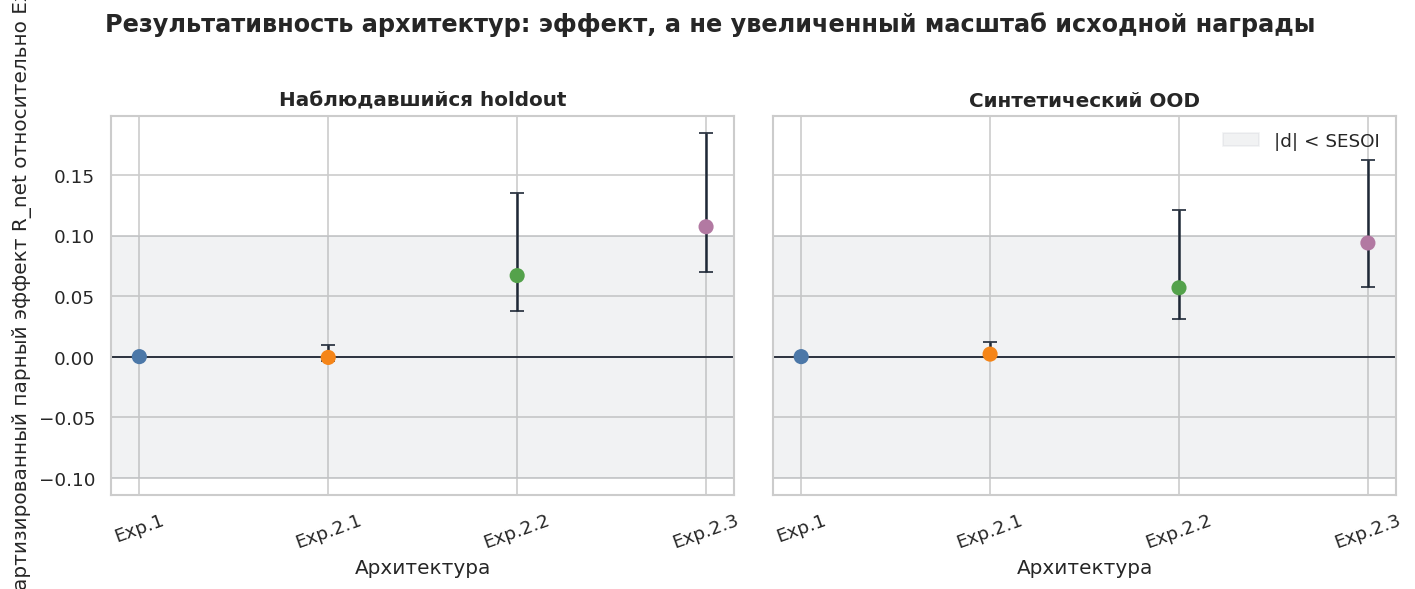

BRICS–PolSys v7.0:  99.9%|█████████▉| 18151/18165 [2:37:10<03:37] , Figures · 1/8

In [32]:
# Фигура 1. Стандартизированные парные отличия от Exp.1; ноль означает эквивалентность.
rows=[]
for split in ("observed_holdout","synthetic_ood"):
    for architecture in ARCHITECTURES:
        if architecture=="Exp.1":
            rows.append({"split":split,"architecture":architecture,"estimate":0.0,"ci_low":0.0,"ci_high":0.0}); continue
        payload=paired_architecture_test(EVAL_COALITION,"mean_r_net",architecture,"Exp.1",split,"greater",f"figure1-{split}-{architecture}")
        rows.append({"split":split,"architecture":architecture,**{k:payload[k] for k in ("estimate","ci_low","ci_high")}})
figure_data=pd.DataFrame(rows)
fig,axes=plt.subplots(1,2,figsize=(12,4.8),sharey=True)
for ax,split,title in zip(axes,("observed_holdout","synthetic_ood"),("Наблюдавшийся holdout","Синтетический OOD")):
    block=figure_data[figure_data.split==split]; x=np.arange(len(block))
    ax.errorbar(x,block.estimate,yerr=[block.estimate-block.ci_low,block.ci_high-block.estimate],fmt="o",color="#1F2937",capsize=4)
    ax.scatter(x,block.estimate,c=[ARCH_COLORS[a] for a in block.architecture],s=65,zorder=3)
    ax.axhline(0,color="#111827",lw=1); ax.axhspan(-CFG.standardized_sesoi,CFG.standardized_sesoi,color="#9CA3AF",alpha=.14,label="|d| < SESOI")
    ax.set_xticks(x,block.architecture,rotation=20); ax.set_title(title); ax.set_xlabel("Архитектура")
axes[0].set_ylabel("Стандартизированный парный эффект R_net относительно Exp.1"); axes[1].legend(frameon=False)
fig.suptitle("Результативность архитектур: эффект, а не увеличенный масштаб исходной награды",y=1.02,fontweight="semibold")
save_figure(fig,"01_primary_endpoint",figure_data); FIGURE_STAGE.tick(note="1/8")


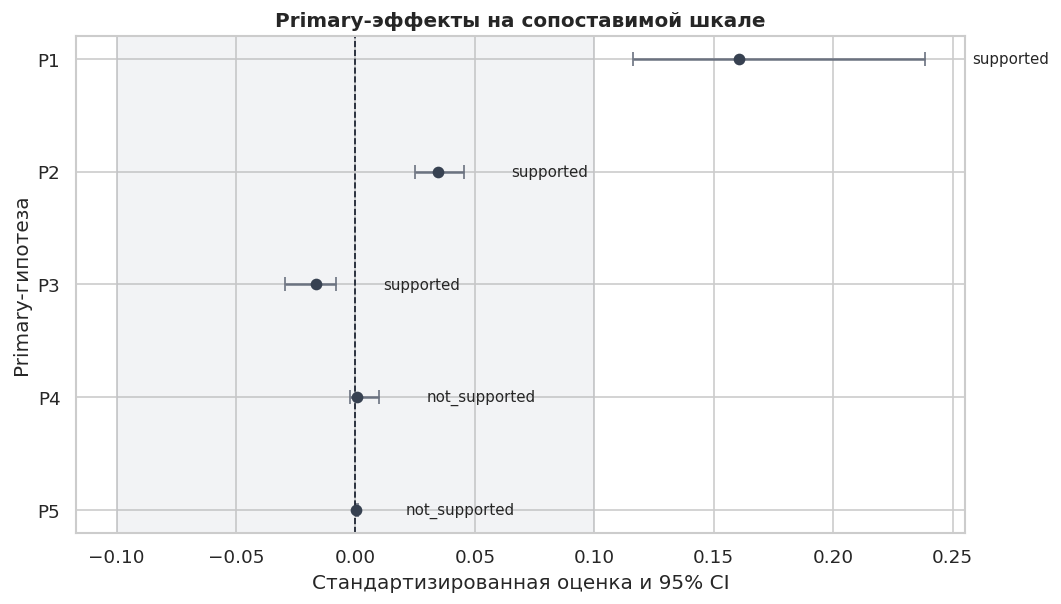

BRICS–PolSys v7.0:  99.9%|█████████▉| 18152/18165 [2:37:10<03:07] , Figures · 2/8

In [33]:
# Фигура 2. Все primary-эффекты находятся на стандартизированной шкале; пороги показаны отдельно.
figure_data=HYPOTHESIS_RESULTS[HYPOTHESIS_RESULTS.family=="primary"].copy().sort_values("id")
fig,ax=plt.subplots(figsize=(9,5.2)); y=np.arange(len(figure_data))
ax.errorbar(figure_data.estimate,y,xerr=[figure_data.estimate-figure_data.ci_low,figure_data.ci_high-figure_data.estimate],fmt="o",color="#374151",ecolor="#6B7280",capsize=4)
ax.axvline(0,color="#111827",ls="--",lw=1); ax.axvspan(-CFG.standardized_sesoi,CFG.standardized_sesoi,color="#9CA3AF",alpha=.12)
ax.set_yticks(y,figure_data.id); ax.invert_yaxis(); ax.set(xlabel="Стандартизированная оценка и 95% CI",ylabel="Primary-гипотеза",title="Primary-эффекты на сопоставимой шкале")
for yi,row in enumerate(figure_data.itertuples()): ax.text(row.ci_high+.02,yi,row.decision,va="center",fontsize=9)
save_figure(fig,"02_primary_effects_forest",figure_data); FIGURE_STAGE.tick(note="2/8")


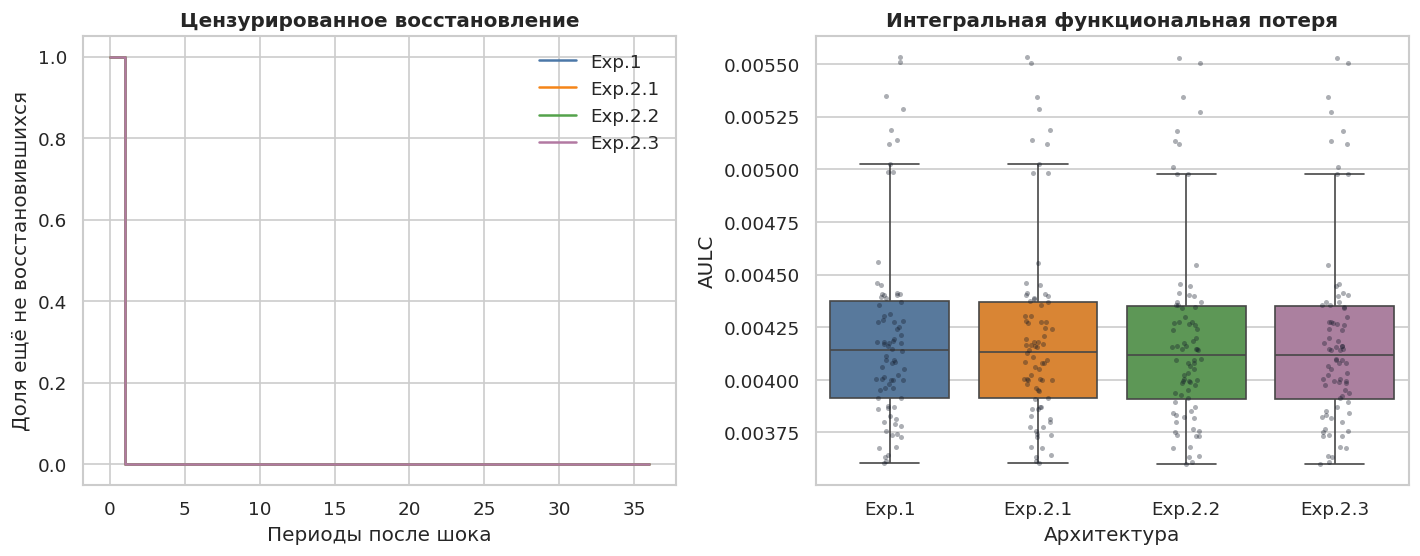

BRICS–PolSys v7.0:  99.9%|█████████▉| 18153/18165 [2:37:11<02:38] , Figures · 3/8

In [34]:
# Фигура 3. Слева survival-диагностика, справа основной различающий показатель AULC.
curves=[]
for architecture in ARCHITECTURES:
    block=RECOVERY[RECOVERY.architecture==architecture]
    curve=kaplan_meier_points(block.recovery_time,block.event_observed,CFG.horizon); curve["architecture"]=architecture; curves.append(curve)
curve_data=pd.concat(curves,ignore_index=True)
aulc_data=RECOVERY.groupby(["seed","scenario_id","architecture"],observed=True).aulc.mean().reset_index()
figure_data=curve_data.merge(pd.DataFrame({"time":[],"survival":[],"architecture":[]}),how="outer")
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
for architecture in ARCHITECTURES:
    block=curve_data[curve_data.architecture==architecture]; axes[0].step(block.time,block.survival,where="post",color=ARCH_COLORS[architecture],label=architecture)
axes[0].set(xlabel="Периоды после шока",ylabel="Доля ещё не восстановившихся",title="Цензурированное восстановление"); axes[0].legend(frameon=False)
sns.boxplot(data=aulc_data,x="architecture",y="aulc",palette=ARCH_COLORS,showfliers=False,ax=axes[1]); sns.stripplot(data=aulc_data,x="architecture",y="aulc",color="#111827",alpha=.35,size=3,ax=axes[1])
axes[1].set(xlabel="Архитектура",ylabel="AULC",title="Интегральная функциональная потеря")
save_figure(fig,"03_recovery_survival_aulc",pd.concat([curve_data.assign(panel="survival"),aulc_data.assign(panel="aulc")],ignore_index=True,sort=False)); FIGURE_STAGE.tick(note="3/8")


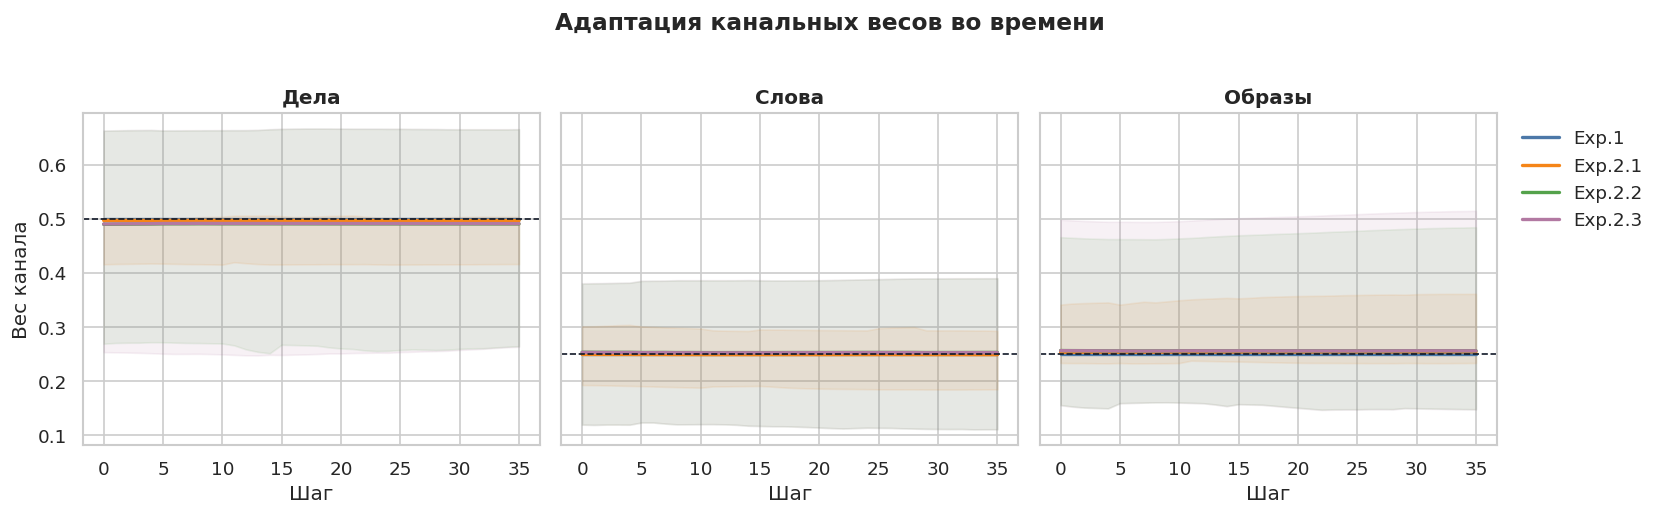

BRICS–PolSys v7.0:  99.9%|█████████▉| 18154/18165 [2:37:13<02:11] , Figures · 4/8

In [35]:
# Фигура 4. Динамика трёх метавесов; канонические уровни показаны пунктиром.
long_weights = EVAL_WEIGHTS.melt(
    id_vars=["seed","architecture","split","scenario_id","country","step"],
    value_vars=["weight_deeds","weight_words","weight_images"], var_name="channel", value_name="weight",
)
figure_data = long_weights.groupby(["architecture","channel","step"], observed=True)["weight"].agg(mean="mean", q025=lambda x:x.quantile(.025), q975=lambda x:x.quantile(.975)).reset_index()
channel_names = {"weight_deeds":"Дела", "weight_words":"Слова", "weight_images":"Образы"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, channel, canonical in zip(axes, channel_names, CFG.channel_weights):
    for architecture in ARCHITECTURES:
        block = figure_data[(figure_data.channel==channel)&(figure_data.architecture==architecture)]
        ax.plot(block.step, block["mean"], color=ARCH_COLORS[architecture], lw=2, label=architecture)
        ax.fill_between(block.step, block.q025, block.q975, color=ARCH_COLORS[architecture], alpha=.10)
    ax.axhline(canonical, color="#111827", ls="--", lw=1); ax.set_title(channel_names[channel]); ax.set_xlabel("Шаг")
axes[0].set_ylabel("Вес канала"); axes[-1].legend(frameon=False, bbox_to_anchor=(1.02,1), loc="upper left")
fig.suptitle("Адаптация канальных весов во времени", y=1.02, fontsize=14, fontweight="semibold")
save_figure(fig, "04_channel_weight_dynamics", figure_data)
FIGURE_STAGE.tick(note="4/8")


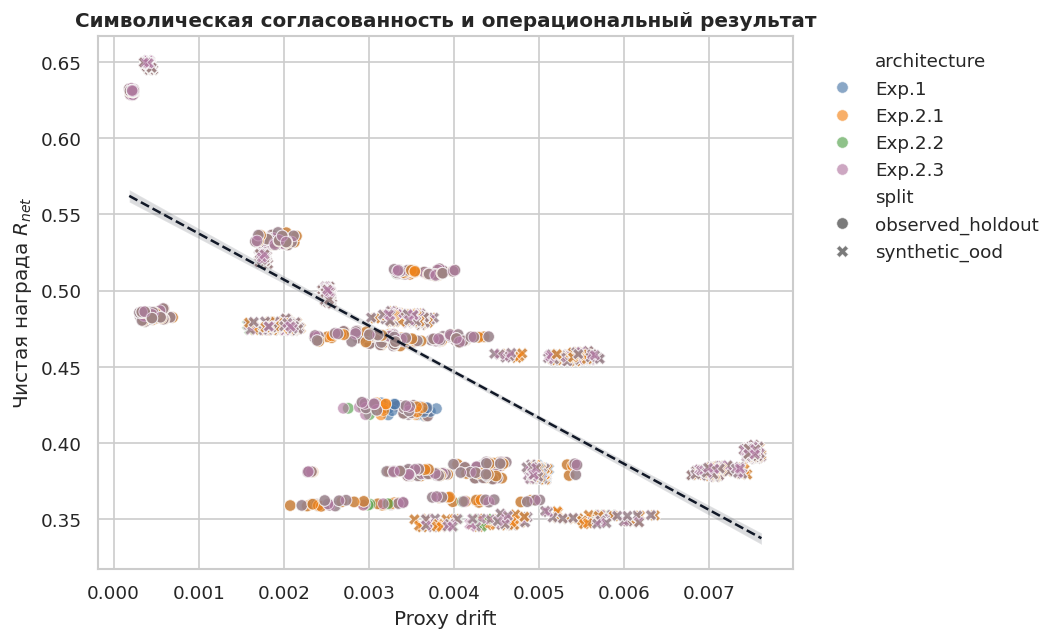

BRICS–PolSys v7.0:  99.9%|█████████▉| 18155/18165 [2:37:16<01:45] , Figures · 5/8

In [36]:
# Фигура 5. Proxy drift сопоставляется с чистой наградой, а не выводится отдельно.
figure_data = EVAL_COUNTRY.groupby(["seed","architecture","split","scenario_id","country"], observed=True).agg(r_net=("mean_r_net","mean"), proxy_drift=("mean_proxy_drift","mean"), coordination_cost=("mean_coordination_cost","mean")).reset_index()
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=figure_data, x="proxy_drift", y="r_net", hue="architecture", style="split", palette=ARCH_COLORS, alpha=.65, s=48, ax=ax)
sns.regplot(data=figure_data, x="proxy_drift", y="r_net", scatter=False, color="#111827", line_kws={"lw":1.5,"ls":"--"}, ax=ax)
ax.set(xlabel="Proxy drift", ylabel="Чистая награда $R_{net}$", title="Символическая согласованность и операциональный результат")
ax.legend(frameon=False, bbox_to_anchor=(1.02,1), loc="upper left")
save_figure(fig, "05_proxy_drift_vs_reward", figure_data)
FIGURE_STAGE.tick(note="5/8")


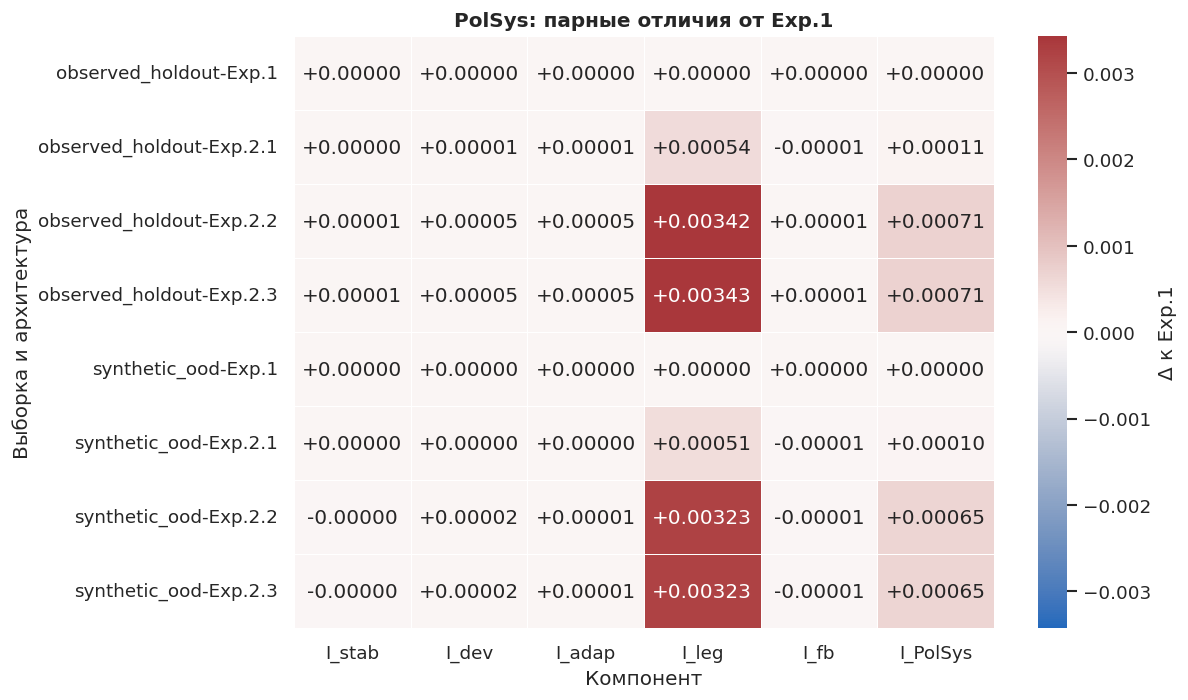

BRICS–PolSys v7.0: 100.0%|█████████▉| 18156/18165 [2:37:17<01:20] , Figures · 6/8

In [37]:
# Фигура 6. Дельты относительно парного Exp.1 показываются с пятью знаками; абсолютный уровень вынесен в Excel.
components=["I_stab","I_dev","I_adap","I_leg","I_fb","I_PolSys"]
means=POLSYS_FULL.groupby(["split","architecture"],observed=True)[components].mean().reset_index()
base=means[means.architecture=="Exp.1"].set_index("split")[components]
rows=[]
for row in means.itertuples(index=False):
    for component in components:
        rows.append({"split":row.split,"architecture":row.architecture,"component":component,"delta":getattr(row,component)-base.loc[row.split,component]})
figure_data=pd.DataFrame(rows); matrix=figure_data.pivot(index=["split","architecture"],columns="component",values="delta").reindex(columns=components)
limit=max(float(np.nanmax(np.abs(matrix.to_numpy()))),1e-5)
fig,ax=plt.subplots(figsize=(10,6)); sns.heatmap(matrix,annot=True,fmt="+.5f",cmap="vlag",center=0,vmin=-limit,vmax=limit,linewidths=.5,cbar_kws={"label":"Δ к Exp.1"},ax=ax)
ax.set(xlabel="Компонент",ylabel="Выборка и архитектура",title="PolSys: парные отличия от Exp.1")
save_figure(fig,"06_polsys_components_delta",figure_data); FIGURE_STAGE.tick(note="6/8")


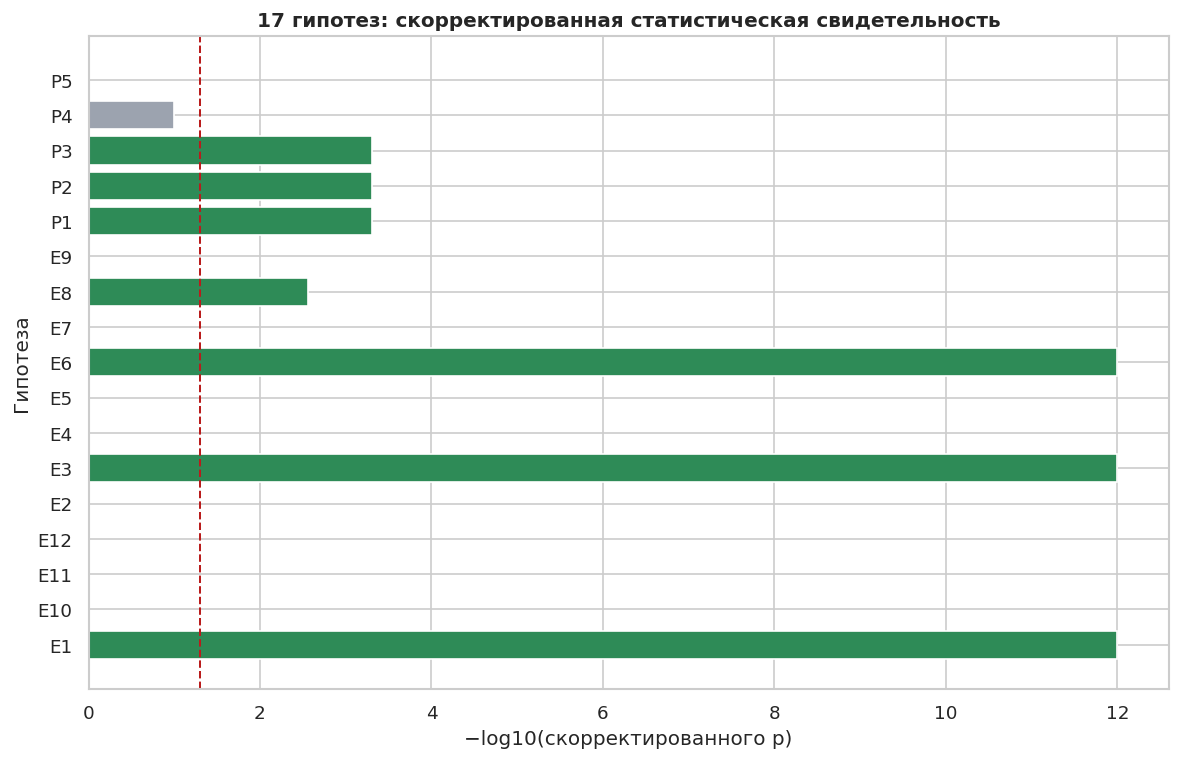

BRICS–PolSys v7.0: 100.0%|█████████▉| 18157/18165 [2:37:17<00:58] , Figures · 7/8

In [38]:
# Фигура 7. Значимость не кодирует направление; направление и единицы остаются в таблице гипотез.
figure_data=HYPOTHESIS_RESULTS.copy().sort_values(["family","id"]); figure_data["evidence"]=-np.log10(figure_data.p_adjusted.clip(lower=1e-12))
fig,ax=plt.subplots(figsize=(10,6.5)); colors=np.where(figure_data.decision=="supported","#2E8B57",np.where(figure_data.status=="ok","#9CA3AF","#D97706"))
ax.barh(figure_data.id,figure_data.evidence,color=colors); ax.axvline(-math.log10(.05),color="#B91C1C",ls="--",lw=1.2)
ax.set(xlabel="−log10(скорректированного p)",ylabel="Гипотеза",title="17 гипотез: скорректированная статистическая свидетельность")
save_figure(fig,"07_hypothesis_evidence",figure_data); FIGURE_STAGE.tick(note="7/8")


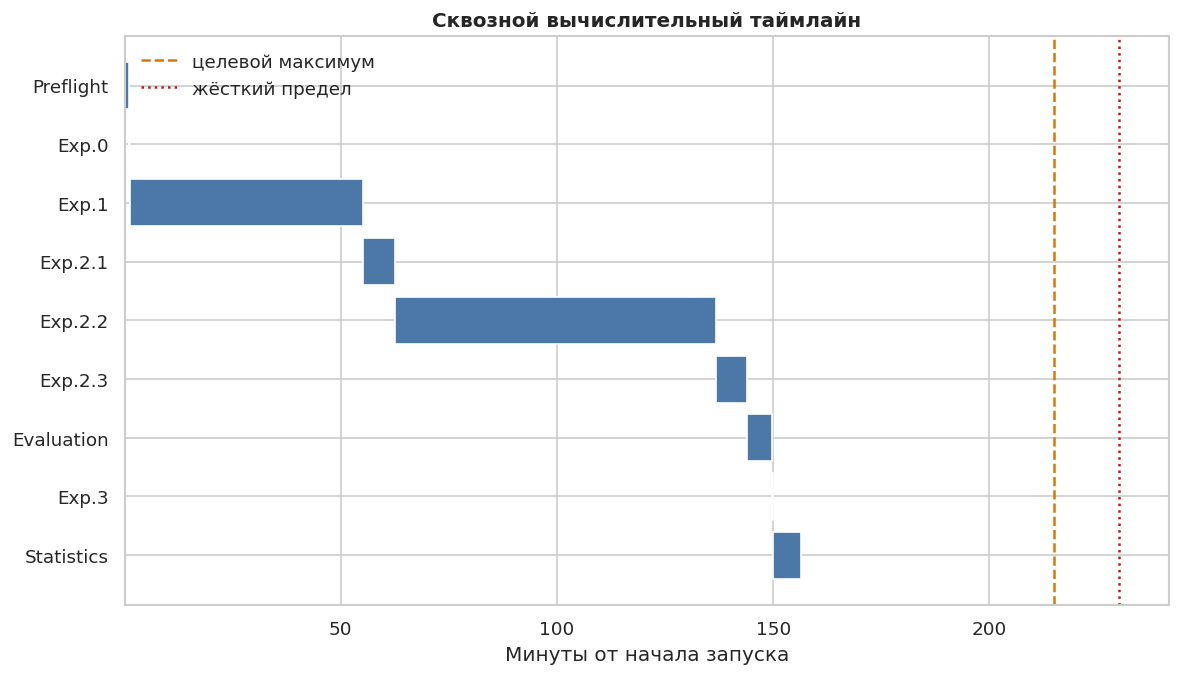

BRICS–PolSys v7.0: 100.0%|█████████▉| 18158/18165 [2:37:18<00:40] , Figures · 8/8

False

In [39]:
# Фигура 8. Настоящий timeline использует начало и длительность; неудачные повторные стадии не дублируются.
figure_data=PROGRESS.frame().copy(); figure_data=figure_data[figure_data.status.isin(["completed","resumed"])].copy()
figure_data=figure_data.sort_values("started_min").drop_duplicates("stage",keep="last")
fig,ax=plt.subplots(figsize=(10,5.8)); y=np.arange(len(figure_data))
ax.barh(y,figure_data.duration_min,left=figure_data.started_min,color="#4C78A8")
ax.set_yticks(y,figure_data.stage); ax.invert_yaxis(); ax.set(xlabel="Минуты от начала запуска",ylabel="",title="Сквозной вычислительный таймлайн")
ax.axvline(CFG.target_runtime_max,color="#D97706",ls="--",label="целевой максимум"); ax.axvline(CFG.hard_runtime_min,color="#B91C1C",ls=":",label="жёсткий предел"); ax.legend(frameon=False)
save_figure(fig,"08_runtime_timeline",figure_data); FIGURE_STAGE.tick(note="8/8"); FIGURE_STAGE.__exit__(None,None,None)


## 18. Excel-экспорт и исследовательский архив

Экспорт разделён по аналитическим уровням, чтобы одна книга не достигала десятков мегабайт. Полная матрица из 47 состояний остаётся воспроизводимой из входной панели и кода; публичная механизм-траектория содержит все переменные, реально используемые 17 гипотезами, действия, веса и компоненты вознаграждения.

1. `01_Overview.xlsx` — дизайн, онтология, gate world model, эффекты и 17 гипотез.
2. `02_Inference_Units.xlsx` — независимые единицы `seed × scenario`, страновые эпизоды, recovery и RMST/AULC.
3. `03_Mechanisms.xlsx` — необходимые временные переменные, 14 действий и веса каналов.
4. `04_PolSys.xlsx` — компоненты и парные дельты к Exp.1 без ранжирования стран.
5. `05_Figure_Data.xlsx` — точные источники восьми фигур.

В ZIP не включаются checkpoint, оптимизаторы, временный cache и служебные логи.


In [40]:
EXCEL_MAX_DATA_ROWS=1_048_000


def excel_safe(frame:pd.DataFrame)->pd.DataFrame:
    out=frame.copy()
    for column in out.select_dtypes(include=["object"]).columns:
        out[column]=out[column].map(lambda x:json.dumps(x,ensure_ascii=False) if isinstance(x,(dict,list,tuple,set)) else x)
    return out.replace([np.inf,-np.inf],np.nan)


def write_styled_sheet(writer:pd.ExcelWriter,name:str,frame:pd.DataFrame,startrow:int=0)->None:
    safe=excel_safe(frame); safe.to_excel(writer,sheet_name=name[:31],index=False,startrow=startrow)
    worksheet,workbook=writer.sheets[name[:31]],writer.book
    header=workbook.add_format({"bold":True,"font_color":"white","bg_color":"#1F4E78","text_wrap":True,"valign":"top"})
    for col,value in enumerate(safe.columns):
        worksheet.write(startrow,col,value,header); sample=safe[value].astype(str).head(200) if len(safe) else pd.Series(dtype=str)
        width=min(42,max(11,len(str(value))+2,int(sample.str.len().quantile(.90))+2 if len(sample) else 11)); worksheet.set_column(col,col,width)
    worksheet.freeze_panes(startrow+1,0)
    if len(safe): worksheet.autofilter(startrow,0,startrow+len(safe),len(safe.columns)-1)


def write_chunked_sheet(writer:pd.ExcelWriter,base_name:str,frame:pd.DataFrame)->list[str]:
    names=[]
    for part,start in enumerate(range(0,max(1,len(frame)),EXCEL_MAX_DATA_ROWS),start=1):
        name=base_name if len(frame)<=EXCEL_MAX_DATA_ROWS else f"{base_name}_{part:02d}"
        write_styled_sheet(writer,name,frame.iloc[start:start+EXCEL_MAX_DATA_ROWS]); names.append(name[:31])
    return names


def write_workbook(path:Path,sheets:Mapping[str,pd.DataFrame])->Path:
    with pd.ExcelWriter(path,engine="xlsxwriter",engine_kwargs={"options":{"nan_inf_to_errors":True,"strings_to_urls":False}}) as writer:
        for name,frame in sheets.items(): write_chunked_sheet(writer,name,frame)
        writer.book.set_properties({"title":f"{CFG.project} {CFG.version}","subject":"Research outputs","author":"BRICS–PolSys MARL research pipeline","comments":"Model-internal counterfactual experiment; not a country ranking."})
    return path


def readme_frame(rows:Sequence[tuple[str,str]])->pd.DataFrame:
    return pd.DataFrame(rows,columns=["Раздел","Описание"])


def penalty_ablation_table(trajectories:pd.DataFrame)->pd.DataFrame:
    variants={
        "baseline":(CFG.coord_penalty,CFG.uncertainty_penalty,CFG.proxy_drift_penalty),
        "coord_0x":(0.0,CFG.uncertainty_penalty,CFG.proxy_drift_penalty),"coord_2x":(2*CFG.coord_penalty,CFG.uncertainty_penalty,CFG.proxy_drift_penalty),
        "uncertainty_0x":(CFG.coord_penalty,0.0,CFG.proxy_drift_penalty),"uncertainty_2x":(CFG.coord_penalty,2*CFG.uncertainty_penalty,CFG.proxy_drift_penalty),
        "proxy_drift_0x":(CFG.coord_penalty,CFG.uncertainty_penalty,0.0),"proxy_drift_2x":(CFG.coord_penalty,CFG.uncertainty_penalty,2*CFG.proxy_drift_penalty),
    }
    rows=[]
    for name,(coord,uncertainty,drift) in variants.items():
        values=trajectories.r_gross-coord*trajectories.coordination_cost-uncertainty*trajectories.uncertainty-drift*trajectories.proxy_drift
        temp=trajectories[["seed","architecture","split","scenario_id"]].copy(); temp["r_net_ablation"]=values
        agg=temp.groupby(["seed","architecture","split","scenario_id"],observed=True).r_net_ablation.mean().reset_index()
        agg["variant"],agg["coord_coef"],agg["uncertainty_coef"],agg["proxy_drift_coef"]=name,coord,uncertainty,drift; rows.append(agg)
    return pd.concat(rows,ignore_index=True)


def seed_point_table(frame:pd.DataFrame)->pd.DataFrame:
    return frame.groupby(["seed","architecture","split"],observed=True).agg(mean_r_net=("mean_r_net","mean"),mean_r_gross=("mean_r_gross","mean"),median_r_net=("mean_r_net","median"),mean_proxy_drift=("mean_proxy_drift","mean"),mean_coordination_cost=("mean_coordination_cost","mean")).reset_index()


PENALTY_ABLATIONS=penalty_ablation_table(EVAL_TRAJECTORIES)
ENDPOINT_SUMMARY=bootstrap_endpoint_table(EVAL_COALITION); SEED_POINTS=seed_point_table(EVAL_COALITION)
training_summary=pd.concat([
    EXP1_TRAINING.groupby("seed").agg(iterations=("episode","max"),best_validation=("validation_reward","max")).assign(stage="Exp.1").reset_index(),
    EXP21_TRAINING.groupby("seed").agg(iterations=("round","max"),best_validation=("best_fitness","max")).assign(stage="Exp.2.1").reset_index(),
    EXP22_TRAINING.groupby("seed").agg(iterations=("round","sum"),best_validation=("best_fitness","max")).assign(stage="Exp.2.2").reset_index(),
    EXP23_TRAINING.groupby("seed").agg(iterations=("round","max"),best_validation=("best_objective","max")).assign(stage="Exp.2.3").reset_index(),
],ignore_index=True)
EXPORT_STAGE=PROGRESS.stage("Export"); EXPORT_STAGE.__enter__()


BRICS–PolSys v7.0: 100.0%|█████████▉| 18158/18165 [2:38:41<00:40] , Export       

In [41]:
state_dictionary=pd.DataFrame([{"position":i,"name":name,"block":next(block for block,names in STATE_BLOCKS.items() if name in names),"definition":STATE_DEFINITIONS[name],"orientation":"negative" if name in NEGATIVE_STATE_FEATURES else "neutral" if name in NEUTRAL_STATE_FEATURES else "positive"} for i,name in enumerate(STATE_NAMES)])
action_dictionary=pd.DataFrame([{"position":i,"name":name,"group":next(group for group,idx in ACTION_GROUPS.items() if i in idx),"definition":ACTION_DEFINITIONS[name]} for i,name in enumerate(ACTION_NAMES)])
design=pd.DataFrame([{"parameter":key,"value":json.dumps(value,ensure_ascii=False) if isinstance(value,(dict,list,tuple)) else value} for key,value in {**asdict(CFG),"selected_profile":asdict(PROFILE),"world_dynamics_mode":WORLD_DYNAMICS_MODE}.items()])
overview_readme=readme_frame([
    ("Назначение","Главная книга для интерпретации дизайна, эффектов и гипотез."),("Architecture_Summary","Валовой и чистый endpoint с иерархическими интервалами."),
    ("Seed_Points","Результаты десяти сидов."),("Training_Summary","Только научно необходимые признаки сходимости; оптимизаторные логи исключены."),
    ("Penalty_Ablations","Пострасчёт чистой награды при 0× и 2× каждого штрафа."),("Hypotheses","17 тестов: эффект, CI, multiplicity correction и решение."),
    ("Ограничение","Модельный контрфактический эксперимент; не прогноз и не рейтинг стран."),
])
OVERVIEW_PATH=write_workbook(XLSX_DIR/"01_Overview.xlsx",{
    "README":overview_readme,"Run_Metadata":pd.DataFrame([{"key":k,"value":v} for k,v in RUN_METADATA.items()]),"Design":design,
    "State_Ontology":state_dictionary,"Action_Ontology":action_dictionary,"World_Model_Validation":WM_METRICS,
    "Architecture_Summary":ENDPOINT_SUMMARY,"Seed_Points":SEED_POINTS,"Training_Summary":training_summary,
    "Penalty_Ablations":PENALTY_ABLATIONS,"Hypotheses":HYPOTHESIS_RESULTS,
}); EXPORT_STAGE.tick(note="01_Overview.xlsx")


BRICS–PolSys v7.0: 100.0%|█████████▉| 18159/18165 [2:38:42<02:26] , Export · 01_Overview.xlsx

In [42]:
inference_readme=readme_frame([
    ("Coalition_Episodes","Независимая primary-единица seed × scenario × architecture."),("Country_Episodes","Страны вложены в seed × scenario; не являются рейтингом."),
    ("Recovery","Адаптивный коридор, событие, цензура, AULC и глубина потери."),("RMST_AULC","Коалиционные survival- и loss-показатели."),
])
INFERENCE_PATH=write_workbook(XLSX_DIR/"02_Inference_Units.xlsx",{"README":inference_readme,"Coalition_Episodes":EVAL_COALITION,"Country_Episodes":EVAL_COUNTRY,"Recovery":RECOVERY,"RMST_AULC":RMST_UNITS})
EXPORT_STAGE.tick(note="02_Inference_Units.xlsx")

state_needed=["SDI","ECI","MPI","DPI",*STATE_BLOCKS["strategic"]]
mechanism_columns=["seed","architecture","split","scenario_id","scenario_name","crisis_type","country","step","r_gross","r_net","y_deeds","y_words","y_images","cohesion","risk","coordination_cost","coord_adjustment","coord_dispersion","coord_churn","uncertainty","proxy_drift","shock_intensity",*[f"state__{x}" for x in state_needed],*[f"action__{x}" for x in ACTION_NAMES]]
if CFG.export_full_state_trajectory:
    mechanism_columns=list(EVAL_TRAJECTORIES.columns)
public_trajectory=EVAL_TRAJECTORIES.loc[:,mechanism_columns]
mechanism_readme=readme_frame([
    ("Mechanism_Trajectories","Одна строка = вложенный временной шаг; включены все переменные 17 гипотез и 14 эффективных действий."),
    ("Weights","Веса, локальные reference-веса и расстояние от канона."),("Важно","Шаги не являются независимыми статистическими единицами."),
])
MECHANISM_PATH=write_workbook(XLSX_DIR/"03_Mechanisms.xlsx",{"README":mechanism_readme,"Mechanism_Trajectories":public_trajectory,"Weights":EVAL_WEIGHTS})
EXPORT_STAGE.tick(note="03_Mechanisms.xlsx")


BRICS–PolSys v7.0: 100.0%|█████████▉| 18161/18165 [2:40:10<02:26] , Export · 03_Mechanisms.xlsx

In [43]:
component_definitions=pd.DataFrame([
    ("I_stab","функциональная стабильность и ограничение риска",.25),("I_dev","социальное развитие и канал дел",.20),
    ("I_adap","AULC, устойчивое восстановление и цензура",.20),("I_leg","легитимность, доверие и слова",.20),
    ("I_fb","обратная связь без proxy drift и word–deed gap",.15),("I_PolSys","взвешенная постоценка пяти компонентов",1.00),
    ("delta_I_PolSys_vs_Exp1","парная дельта относительно Exp.1; не рейтинг",np.nan),
],columns=["component","definition","weight"])
polsys_readme=readme_frame([("PolSys_Full","Одна строка = seed × architecture × split × scenario × country."),("PolSys_Summary","Среднее, медиана и SD; страны расположены алфавитно."),("Интерпретация","Эндогенная модельная постоценка, не универсальная шкала режимов.")])
POLSYS_PATH=write_workbook(XLSX_DIR/"04_PolSys.xlsx",{"README":polsys_readme,"Component_Definitions":component_definitions,"PolSys_Full":POLSYS_FULL,"PolSys_Summary":POLSYS_SUMMARY})
EXPORT_STAGE.tick(note="04_PolSys.xlsx")


BRICS–PolSys v7.0: 100.0%|█████████▉| 18162/18165 [2:40:11<01:20] , Export · 04_PolSys.xlsx

In [44]:
figure_readme=readme_frame([(slug,f"Источник фигуры {slug}; PNG/SVG находятся в figures.") for slug in FIGURE_DATA])
figure_sheets={"README":figure_readme}
for index,(slug,frame) in enumerate(FIGURE_DATA.items(),start=1): figure_sheets[f"F{index:02d}_{slug[3:25]}"]=frame
FIGURE_DATA_PATH=write_workbook(XLSX_DIR/"05_Figure_Data.xlsx",figure_sheets); EXPORT_STAGE.tick(note="05_Figure_Data.xlsx")


BRICS–PolSys v7.0: 100.0%|█████████▉| 18162/18165 [2:40:11<01:20] , Export · 05_Figure_Data.xlsx

In [45]:
RUN_METADATA["finished_utc"]=pd.Timestamp.utcnow().isoformat(); RUN_METADATA["elapsed_minutes_before_zip"]=round(PROGRESS.elapsed_min(),2)
readme_text=f"""# BRICS–PolSys MARL v{CFG.version}: результаты

Контрфактический многоагентный эксперимент; не прогноз и не рейтинг государств.

## Порядок чтения
1. `excel/01_Overview.xlsx`: gate world model, endpoint, сиды, абляции и 17 гипотез.
2. `excel/02_Inference_Units.xlsx`: независимые единицы, recovery, RMST и AULC.
3. `excel/03_Mechanisms.xlsx`: действия, стратегические состояния и веса.
4. `excel/04_PolSys.xlsx`: компоненты и парные дельты к Exp.1 без ранжирования.
5. `excel/05_Figure_Data.xlsx`: точные источники графиков.

Primary: Holm; exploratory: FDR-BH; статистическая единица: seed × scenario.
World dynamics: {WORLD_DYNAMICS_MODE}. Профиль: {PROFILE.name}. Сиды: {', '.join(map(str,CFG.seeds))}. Горизонт: {CFG.horizon}.
"""
(GUIDE_DIR/"README_RESULTS.md").write_text(textwrap.dedent(readme_text),encoding="utf-8")
contents="""# Содержание архива

| Путь | Назначение |
|---|---|
| `excel/01_Overview.xlsx` | дизайн, онтология, gate, endpoint, 17 гипотез |
| `excel/02_Inference_Units.xlsx` | независимые единицы, recovery, RMST/AULC |
| `excel/03_Mechanisms.xlsx` | временные механизмы, действия и веса |
| `excel/04_PolSys.xlsx` | компоненты и парные дельты |
| `excel/05_Figure_Data.xlsx` | данные восьми фигур |
| `figures/*.png`, `figures/*.svg` | публикационные изображения |
| `guides/*.md` | инструкция по интерпретации |

Checkpoint, cache, оптимизаторы и служебные логи исключены.
"""
(GUIDE_DIR/"ARCHIVE_CONTENTS.md").write_text(textwrap.dedent(contents),encoding="utf-8"); EXPORT_STAGE.tick(note="гиды")

ARCHIVE_PATH=Path("/content")/"BRICS_PolSys_MARL_v7_0_results.zip"
if ARCHIVE_PATH.exists(): ARCHIVE_PATH.unlink()
with zipfile.ZipFile(ARCHIVE_PATH,"w",compression=zipfile.ZIP_DEFLATED,compresslevel=7) as archive:
    for path in sorted(ROOT.rglob("*")):
        if path.is_file(): archive.write(path,path.relative_to(ROOT.parent))
EXPORT_STAGE.tick(note="ZIP"); EXPORT_STAGE.__exit__(None,None,None); PROGRESS.close()
if not CFG.keep_checkpoints and CHECKPOINT_DIR.exists(): shutil.rmtree(CHECKPOINT_DIR)
print(f"Архив: {ARCHIVE_PATH} · {ARCHIVE_PATH.stat().st_size/1024**2:.1f} MB")
print(pd.DataFrame(PROGRESS.timeline)[["stage","duration_min","completed_units","unused_units","status"]].to_string(index=False))


BRICS–PolSys v7.0: 100.0%|██████████| 18165/18165 [2:40:14<00:00] , готово · 160.2 мин

Архив: /content/BRICS_PolSys_MARL_v7_0_results.zip · 59.1 MB
     stage  duration_min  completed_units  unused_units    status
 Preflight      1.039244                8             0 completed
     Exp.0      0.105396              355           545 completed
     Exp.1     53.950827             3576          2424 completed
   Exp.2.1      7.328569              477           423 completed
   Exp.2.2     74.346285             4703          4297 completed
   Exp.2.3      7.080126              619           381 completed
Evaluation      5.779700              320             0 completed
     Exp.3      0.325897                5             0 completed
Statistics      6.361785               17             0 completed
   Figures      0.978997                8             0 completed
    Export      1.543504                7             0 completed


In [46]:
# Финальная загрузка архива в браузер Colab.
try:
    from google.colab import files
    files.download(str(ARCHIVE_PATH))
except ImportError:
    print(f"Загрузка доступна в Colab; локальный путь: {ARCHIVE_PATH}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Сохранение исполненного ноутбука на GitHub

После завершения загрузки ZIP выберите в Colab **File → Save a copy in GitHub**. Ноутбук использует только статические таблицы, изображения и один текстовый progress-bar, поэтому GitHub отобразит все сохранённые выводы без `ipywidgets`. Перед публикацией рекомендуется очистить только случайно выведенные локальные пути или персональные сведения; научные таблицы и фигуры следует сохранить.
